Loaded data from DC_Data_For_Lasso_3Feat.csv. Shape: (136, 4)
Loaded master data from DC_Master_Data_Filled.csv. Shape: (140, 9)

Train set size: 100
Test set size: 36
Last actual House_Index value before test period (2015-10-01 00:00:00): 246.65

Starting walk-forward validation...
Processed 36/36 steps...
Walk-forward validation complete.

--- Results DataFrame (Head) ---
            Actual_Diff  Predicted_Diff  Actual_Original  Predicted_Original
Date                                                                        
2016-01-01         0.99        0.788903           247.64          247.438903
2016-04-01         3.72        0.673825           251.36          248.313825
2016-07-01         2.55        0.645750           253.91          252.005750
2016-10-01         1.99        1.385225           255.90          255.295225
2017-01-01        -1.98        2.737686           253.92          258.637686

Calculating performance metrics...

--- SVR Performance Metrics (Original Scale) --

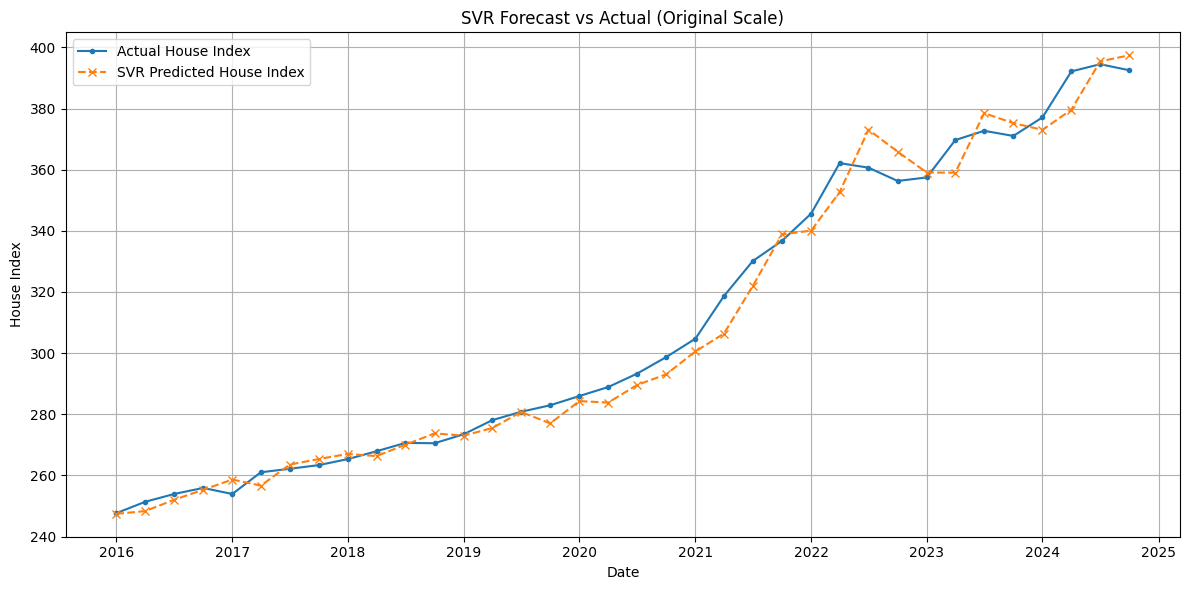

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero if y_true is 0
    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan  # Handle case where all true values are zero
    # Handle cases where mask filters all values
    if len(y_true[mask]) == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Function to calculate Directional Accuracy
def directional_accuracy(y_true, y_pred, y_true_prev):
    """
    Calculates directional accuracy based on 1-step change.
    y_true: Array of actual values.
    y_pred: Array of predicted values.
    y_true_prev: Array of previous actual values (lagged y_true by 1 step).
    """
    # Ensure inputs are numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_true_prev = np.array(y_true_prev)

    # Check for equal length - essential after potential slicing
    if not (len(y_true) == len(y_pred) == len(y_true_prev)):
        print(f"DA Error: Length mismatch. Actual: {len(y_true)}, Predicted: {len(y_pred)}, Previous: {len(y_true_prev)}")
        return np.nan

    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev) # Compare prediction direction to previous actual

    # Handle cases where difference is zero (no change)
    actual_diff[actual_diff == 0] = 1 # Assign a default direction (e.g., positive)
    pred_diff[pred_diff == 0] = 1   # Assign a default direction

    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0:
        return np.nan
    return np.mean(correct_direction) * 100

# Load the data prepared for regression (differenced target, lagged features)
data_file = 'DC_Data_For_Lasso_3Feat.csv'
master_file = 'DC_Master_Data_Filled.csv' # Needed for inverse differencing base value

try:
    df = pd.read_csv(data_file, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)

    print(f"Loaded data from {data_file}. Shape: {df.shape}")
    print(f"Loaded master data from {master_file}. Shape: {df_master.shape}")

    # --- Data Preparation ---
    target_col = df.columns[0]
    y = df[target_col]
    X = df.drop(columns=[target_col])

    n_test = 36 # Test set size for walk-forward validation
    if len(df) < n_test * 2:
         raise ValueError(f"Not enough data for the specified test size {n_test}.")

    X_train_full, X_test = X[:-n_test], X[-n_test:]
    y_train_full, y_test = y[:-n_test], y[-n_test:]

    print(f"\nTrain set size: {len(X_train_full)}")
    print(f"Test set size: {len(X_test)}")

    # Get the last actual 'House_Index' value *before* the test period starts
    last_actual_train_date = y_train_full.index[-1]
    try:
        last_actual_house_index_train = df_master.loc[last_actual_train_date, 'House_Index']
        print(f"Last actual House_Index value before test period ({last_actual_train_date}): {last_actual_house_index_train}")
    except KeyError:
        raise KeyError(f"Date {last_actual_train_date} not found in master data index.")


    # --- Walk-Forward Validation ---
    max_forecast_horizon = 8
    history_X = X_train_full.copy()
    history_y = y_train_full.copy()
    predictions_diff = []

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    print("\nStarting walk-forward validation...")
    for t in range(len(X_test)):
        X_train_scaled = scaler_X.fit_transform(history_X)
        y_train_scaled = scaler_y.fit_transform(history_y.values.reshape(-1, 1)).ravel()

        model = SVR() # Default RBF kernel
        model.fit(X_train_scaled, y_train_scaled)

        current_X_test = X_test.iloc[[t]]
        current_X_test_scaled = scaler_X.transform(current_X_test)

        y_pred_scaled = model.predict(current_X_test_scaled)
        y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]
        predictions_diff.append(y_pred_diff)

        history_X = pd.concat([history_X, current_X_test], ignore_index=False)
        history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        # Minimal progress print to avoid flooding output
        if (t + 1) == len(X_test):
             print(f"Processed {t + 1}/{len(X_test)} steps...")

    print("Walk-forward validation complete.")

    # --- Inverse Differencing ---
    predictions_original_scale = []
    last_actual_val = last_actual_house_index_train
    for i, pred_diff in enumerate(predictions_diff):
        pred_original = last_actual_val + pred_diff
        predictions_original_scale.append(pred_original)
        current_actual_date = y_test.index[i]
        last_actual_val = df_master.loc[current_actual_date, 'House_Index'] # Update with actual for next step calc

    # --- Results DataFrame ---
    results_df = pd.DataFrame({
        'Actual_Diff': y_test.values,
        'Predicted_Diff': predictions_diff,
        'Actual_Original': df_master.loc[y_test.index, 'House_Index'].values,
        'Predicted_Original': predictions_original_scale
    }, index=y_test.index)

    print("\n--- Results DataFrame (Head) ---")
    print(results_df.head())

    # --- Multi-Step Evaluation (Fixed using .values) ---
    metrics = []
    actual_orig = results_df['Actual_Original']
    pred_orig = results_df['Predicted_Original']
    # Get the previous actual values (lag 1) needed for directional accuracy
    actual_prev_for_da_series = df_master['House_Index'].shift(1).loc[actual_orig.index]

    print("\nCalculating performance metrics...")
    for h in range(1, max_forecast_horizon + 1):

        # Slice using .values to avoid index issues
        # For metrics at horizon h, we compare actuals[h-1:] with predictions[h-1:]
        # Ensure we don't slice beyond the length of the arrays
        if h > len(actual_orig):
             print(f"Warning: Horizon {h} exceeds test data length ({len(actual_orig)}). Stopping metrics calculation.")
             break

        actual_h_vals = actual_orig.values[h-1:]
        pred_h_vals = pred_orig.values[h-1:]

        # Ensure arrays are not empty after slicing
        if len(actual_h_vals) == 0:
             print(f"Warning: No data points left to calculate metrics for horizon h={h}. Skipping.")
             continue

        # Calculate standard metrics
        mae = mean_absolute_error(actual_h_vals, pred_h_vals)
        rmse = np.sqrt(mean_squared_error(actual_h_vals, pred_h_vals))
        mape = mean_absolute_percentage_error(actual_h_vals, pred_h_vals) # Uses internal check for zeros

        # Prepare previous values for DA calculation for horizon h
        # We need the value that occurred 1 step *before* the actual value being predicted
        # Slice the pre-calculated lag-1 series appropriately
        actual_prev_h_vals_for_da = actual_prev_for_da_series.values[h-1:]

        # Calculate Directional Accuracy
        # Check lengths just in case slicing resulted in mismatch (shouldn't with .values and same slice)
        if len(actual_h_vals) != len(pred_h_vals) or len(actual_h_vals) != len(actual_prev_h_vals_for_da):
            print(f"Warning: Length mismatch for DA calculation at h={h}.")
            print(f"Lengths - Actual: {len(actual_h_vals)}, Pred: {len(pred_h_vals)}, Prev: {len(actual_prev_h_vals_for_da)}")
            da = np.nan
        else:
            # Call DA function which now includes internal length check
            da = directional_accuracy(actual_h_vals, pred_h_vals, actual_prev_h_vals_for_da)


        metrics.append({
            'Forecast Horizon (Steps)': h,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'Directional Accuracy (%)': da
        })

    metrics_df = pd.DataFrame(metrics)
    print("\n--- SVR Performance Metrics (Original Scale) ---")
    # Format output for better readability
    print(metrics_df.to_string(index=False, float_format="%.3f"))

except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV files. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# Optional: Plotting
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.plot(results_df.index, results_df['Actual_Original'], label='Actual House Index', marker='.', linestyle='-')
    plt.plot(results_df.index, results_df['Predicted_Original'], label='SVR Predicted House Index', marker='x', linestyle='--')
    plt.title('SVR Forecast vs Actual (Original Scale)')
    plt.xlabel('Date')
    plt.ylabel('House Index')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("\nMatplotlib not installed. Skipping plot.")
except Exception as e:
    print(f"\nAn error occurred during plotting: {e}")

Data loaded successfully.
SVR input data shape: (136, 4)
Master data shape: (140, 9)
Last historical date in SVR input data: 2024-10-01 00:00:00
Last actual House_Index value (2024-10-01 00:00:00): 392.54

Generating future features based on assumptions...
Future forecast dates: 2025-01-01 00:00:00 to 2026-10-01 00:00:00
Assuming Hot_Market = 0.0 for future dates (from last SVR input).
Assuming average GDP_diff3 = 1337.300 based on last ~3 years.

--- Future Features (X_future Head) ---
            Recession  Hot_Market  GDP_diff3_L1
2025-01-01          0         0.0   1099.795000
2025-04-01          0         0.0   1337.300167
2025-07-01          0         0.0   1337.300167
2025-10-01          0         0.0   1337.300167
2026-01-01          0         0.0   1337.300167

Training final SVR model on all historical data...
Final SVR model trained.
Predicting future steps...
Inverse differencing future predictions...

--- Future Forecast Results ---
            Predicted_House_Index
2025-0

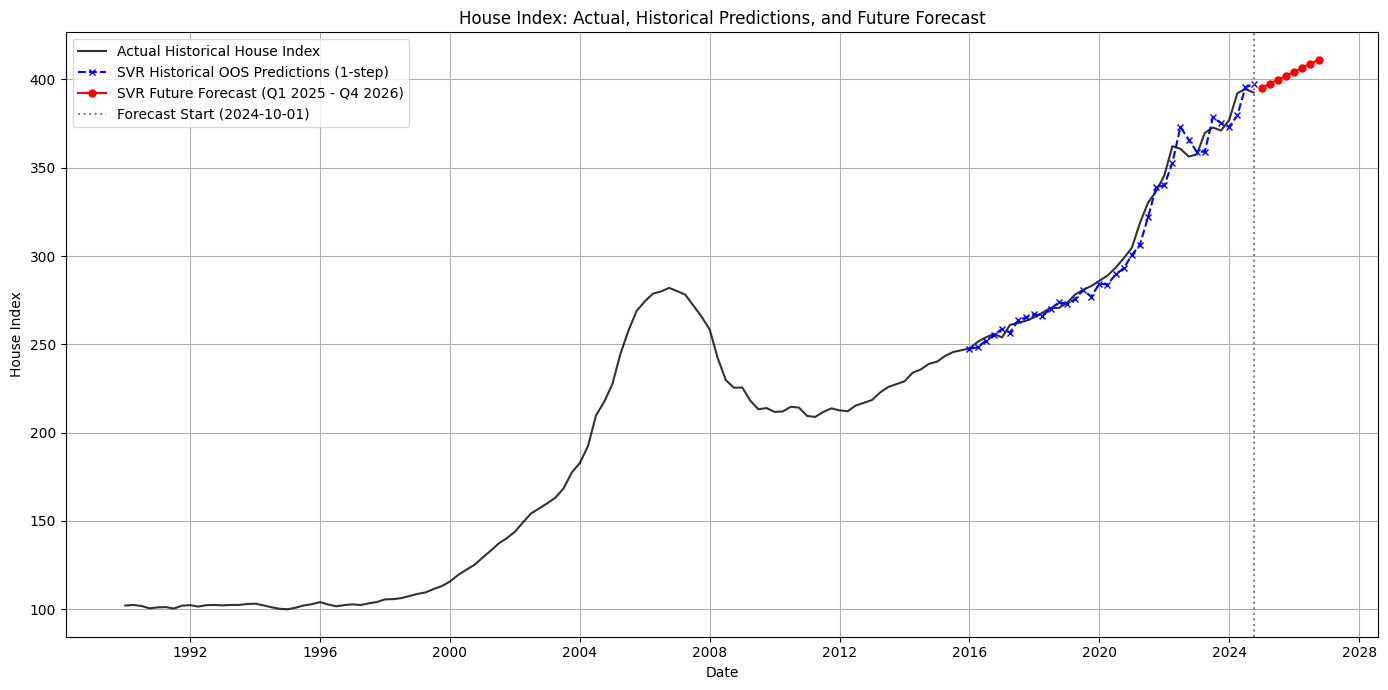

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# --- Configuration ---
data_file_3feat = 'DC_Data_For_Lasso_3Feat.csv'
master_file = 'DC_Master_Data_Filled.csv'
future_base_file = 'DC_Future_Data.csv' # Contains future dates (may not be needed if generating dates)
n_future_steps = 8 # Q1 2025 to Q4 2026

# --- Load Data ---
try:
    df_svr_input = pd.read_csv(data_file_3feat, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)

    print("Data loaded successfully.")
    print(f"SVR input data shape: {df_svr_input.shape}")
    print(f"Master data shape: {df_master.shape}")

    # Check last date in SVR input (this defines the end of training features)
    last_hist_date_features = df_svr_input.index.max()
    print(f"Last historical date in SVR input data: {last_hist_date_features}")


    # --- Prepare Full Historical Data for Final Model ---
    target_col = df_svr_input.columns[0] # Should be 'Target_House_Index_diff1'
    y_hist = df_svr_input[target_col]
    X_hist = df_svr_input.drop(columns=[target_col])

    # Get the very last actual House_Index value from master data for inverse differencing later
    # Ensure the date exists in df_master index
    if last_hist_date_features not in df_master.index:
         # If the very last date isn't in master, maybe due to lag generation, find the closest previous date
         closest_date = df_master.index[df_master.index <= last_hist_date_features].max()
         print(f"Warning: Exact date {last_hist_date_features} not in master index. Using closest date {closest_date} for last House_Index value.")
         last_actual_house_index = df_master.loc[closest_date, 'House_Index']
         last_hist_date_master = closest_date # Use this date as the official end of actuals
    else:
         last_actual_house_index = df_master.loc[last_hist_date_features, 'House_Index']
         last_hist_date_master = last_hist_date_features # Use the feature date as end of actuals

    print(f"Last actual House_Index value ({last_hist_date_master}): {last_actual_house_index}")


    # --- Assumptions and Feature Generation for Future Steps ---
    print("\nGenerating future features based on assumptions...")

    # 1. Future Dates
    future_dates = pd.date_range(start=last_hist_date_features + pd.DateOffset(months=3), periods=n_future_steps, freq='QS')
    print(f"Future forecast dates: {future_dates.min()} to {future_dates.max()}")

    # 2. Recession: Assume 0
    future_recession = pd.Series([0] * n_future_steps, index=future_dates)

    # 3. Hot Market: Assume last known value *from X_hist* (CORRECTED)
    last_hot_market = X_hist.iloc[-1]['Hot_Market'] # Get value from last row of X_hist
    future_hot_market = pd.Series([last_hot_market] * n_future_steps, index=future_dates)
    print(f"Assuming Hot_Market = {last_hot_market} for future dates (from last SVR input).")

    # 4. GDP_diff3_L1: Assume average growth from last 3 years continues
    # Calculate historical GDP_diff3 from master data
    gdp_diff3_hist = df_master['GDP'].diff(3).dropna()
    # Calculate average of last 12 quarters (3 years) ending at last_hist_date_master
    gdp_diff3_hist_relevant = gdp_diff3_hist[gdp_diff3_hist.index <= last_hist_date_master]
    if len(gdp_diff3_hist_relevant) < 12 :
        print(f"Warning: Fewer than 12 quarters ({len(gdp_diff3_hist_relevant)}) of GDP_diff3 available for average calculation. Using available data.")
        avg_gdp_diff3 = gdp_diff3_hist_relevant.mean()
    else:
         avg_gdp_diff3 = gdp_diff3_hist_relevant.iloc[-12:].mean()

    print(f"Assuming average GDP_diff3 = {avg_gdp_diff3:.3f} based on last ~3 years.")

    # Generate future GDP_diff3_L1
    # Need last known GDP_diff3 value to start the lag
    last_gdp_diff3 = gdp_diff3_hist.loc[last_hist_date_features] # Get GDP diff for the feature date
    future_gdp_diff3_l1_values = []
    current_lag_val = last_gdp_diff3
    for _ in range(n_future_steps):
        future_gdp_diff3_l1_values.append(current_lag_val)
        # The *next* lag value will be the assumed average diff
        current_lag_val = avg_gdp_diff3

    future_gdp_diff3_l1 = pd.Series(future_gdp_diff3_l1_values, index=future_dates)

    # Assemble Future Feature DataFrame
    X_future = pd.DataFrame({
        'Recession': future_recession,
        'Hot_Market': future_hot_market,
        'GDP_diff3_L1': future_gdp_diff3_l1
    }, index=future_dates)
    # Ensure column order matches X_hist
    X_future = X_future[X_hist.columns]


    print("\n--- Future Features (X_future Head) ---")
    print(X_future.head())

    # --- Train Final SVR Model ---
    print("\nTraining final SVR model on all historical data...")
    scaler_X_final = StandardScaler()
    scaler_y_final = StandardScaler()

    X_hist_scaled = scaler_X_final.fit_transform(X_hist)
    y_hist_scaled = scaler_y_final.fit_transform(y_hist.values.reshape(-1, 1)).ravel()

    final_svr_model = SVR() # Using default params again for consistency
    final_svr_model.fit(X_hist_scaled, y_hist_scaled)
    print("Final SVR model trained.")

    # --- Predict Future Steps ---
    print("Predicting future steps...")
    X_future_scaled = scaler_X_final.transform(X_future)
    y_pred_scaled_future = final_svr_model.predict(X_future_scaled)
    y_pred_diff_future = scaler_y_final.inverse_transform(y_pred_scaled_future.reshape(-1, 1)).ravel()

    # --- Inverse Differencing for Future Predictions ---
    print("Inverse differencing future predictions...")
    future_predictions_original = []
    last_val = last_actual_house_index # Use the last actual index value determined earlier
    for pred_diff in y_pred_diff_future:
        next_val = last_val + pred_diff
        future_predictions_original.append(next_val)
        last_val = next_val # Use the predicted value to project the next one

    future_results_df = pd.DataFrame({
        'Predicted_House_Index': future_predictions_original
    }, index=future_dates)

    print("\n--- Future Forecast Results ---")
    print(future_results_df)

    # --- Prepare Data for Plotting ---
    print("\nPreparing data for plotting...")
    # --- Re-run walk-forward validation to get historical predictions for plot ---
    n_test_hist = 36 # Test set size used previously
    X_train_hist_plot = X_hist[:-n_test_hist]
    y_train_hist_plot = y_hist[:-n_test_hist]
    X_test_hist_plot = X_hist[-n_test_hist:]
    y_test_hist_plot = y_hist[-n_test_hist:]

    predictions_diff_hist = []
    scaler_X_hist_plot = StandardScaler()
    scaler_y_hist_plot = StandardScaler()
    history_X_plot = X_train_hist_plot.copy()
    history_y_plot = y_train_hist_plot.copy()


    for t in range(len(X_test_hist_plot)):
        X_train_scaled_hist_plot = scaler_X_hist_plot.fit_transform(history_X_plot)
        y_train_scaled_hist_plot = scaler_y_hist_plot.fit_transform(history_y_plot.values.reshape(-1, 1)).ravel()
        model_hist_plot = SVR()
        model_hist_plot.fit(X_train_scaled_hist_plot, y_train_scaled_hist_plot)
        current_X_test_hist_plot = X_test_hist_plot.iloc[[t]]
        current_X_test_scaled_hist_plot = scaler_X_hist_plot.transform(current_X_test_hist_plot)
        y_pred_scaled_hist_plot = model_hist_plot.predict(current_X_test_scaled_hist_plot)
        y_pred_diff_hist_plot = scaler_y_hist_plot.inverse_transform(y_pred_scaled_hist_plot.reshape(-1, 1)).ravel()[0]
        predictions_diff_hist.append(y_pred_diff_hist_plot)
        history_X_plot = pd.concat([history_X_plot, current_X_test_hist_plot], ignore_index=False)
        history_y_plot = pd.concat([history_y_plot, y_test_hist_plot.iloc[[t]]], ignore_index=False)

    # Inverse difference historical predictions
    last_actual_train_date_hist = y_train_hist_plot.index[-1]

    # Find the actual house index value at this date from master data
    if last_actual_train_date_hist not in df_master.index:
        closest_date_hist = df_master.index[df_master.index <= last_actual_train_date_hist].max()
        print(f"Warning: Exact date {last_actual_train_date_hist} not in master index for historical plot base. Using {closest_date_hist}.")
        last_actual_house_index_train_hist = df_master.loc[closest_date_hist, 'House_Index']
    else:
        last_actual_house_index_train_hist = df_master.loc[last_actual_train_date_hist, 'House_Index']


    predictions_original_scale_hist = []
    last_actual_val_hist = last_actual_house_index_train_hist
    actual_values_hist = []

    for i, pred_diff in enumerate(predictions_diff_hist):
        pred_original = last_actual_val_hist + pred_diff
        predictions_original_scale_hist.append(pred_original)
        current_actual_date_hist = y_test_hist_plot.index[i]
        # Ensure we get the actual value from the master df for the plot & next step base
        if current_actual_date_hist not in df_master.index:
             closest_actual_date_hist = df_master.index[df_master.index <= current_actual_date_hist].max()
             print(f"Warning: Date {current_actual_date_hist} not in master index for historical plot actuals. Using {closest_actual_date_hist}.")
             current_actual_val_hist = df_master.loc[closest_actual_date_hist, 'House_Index']
        else:
             current_actual_val_hist = df_master.loc[current_actual_date_hist, 'House_Index']

        actual_values_hist.append(current_actual_val_hist)
        last_actual_val_hist = current_actual_val_hist # Update with actual value for next step


    hist_results_df_plot = pd.DataFrame({
         'Actual_Original': actual_values_hist,
         'Predicted_Original': predictions_original_scale_hist
     }, index=y_test_hist_plot.index)


    # --- Create Final Plot ---
    plt.figure(figsize=(14, 7))
    # Plot historical actual data (full history from master)
    plt.plot(df_master.index, df_master['House_Index'], label='Actual Historical House Index', color='black', linewidth=1.5, alpha=0.8)
    # Plot historical OOS predictions (from re-run walk-forward)
    plt.plot(hist_results_df_plot.index, hist_results_df_plot['Predicted_Original'], label='SVR Historical OOS Predictions (1-step)', color='blue', linestyle='--', marker='x', markersize=5)
    # Plot future forecast
    plt.plot(future_results_df.index, future_results_df['Predicted_House_Index'], label='SVR Future Forecast (Q1 2025 - Q4 2026)', color='red', linestyle='-', marker='o', markersize=5)

    plt.title('House Index: Actual, Historical Predictions, and Future Forecast')
    plt.xlabel('Date')
    plt.ylabel('House Index')
    plt.axvline(last_hist_date_master, color='gray', linestyle=':', label=f'Forecast Start ({last_hist_date_master.date()})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV/DataFrames. {e}")
except IndexError as e:
     print(f"Error: Index error, likely during data slicing or accessing .iloc[-1]. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

--- Running Direct SVR Evaluation for Horizon h = 1 ---
Data loaded successfully.
Aligned data shape for h=1: (135, 4)
Train set size: 99
Test set size: 36

Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- SVR Performance Metrics (Direct Strategy) ---
Forecast Horizon (h): 1
MAE:  3.711
RMSE: 4.933
MAPE: 1.157%
DA:   77.778%


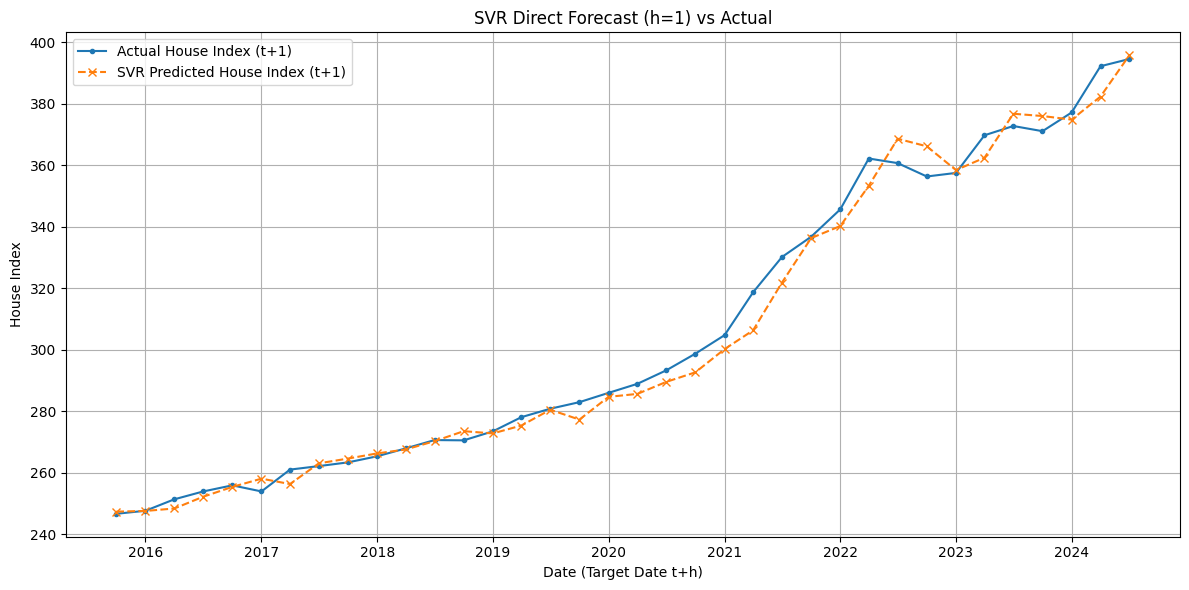


--- Completed Run for Horizon h = 1 ---


In [4]:
# --- Code Template for Direct Multi-Step SVR Evaluation (Single Horizon) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta # More robust for month/quarter steps

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
# ************************************************************
# ****** CHANGE THIS VALUE FOR EACH RUN (1 through 8) ******
forecast_horizon = 1  # Example: Set to 1 for the first run
# ************************************************************

data_file_3feat = 'DC_Data_For_Lasso_3Feat.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36 # Number of forecasts to generate in walk-forward

print(f"--- Running Direct SVR Evaluation for Horizon h = {forecast_horizon} ---")

# --- Load Data ---
try:
    df_svr_input_raw = pd.read_csv(data_file_3feat, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print("Data loaded successfully.")

    # --- Prepare Data for Direct Forecasting at Horizon h ---
    target_col_diff = df_svr_input_raw.columns[0] # 'Target_House_Index_diff1'

    # Features X are the original features (known at time t)
    X_orig = df_svr_input_raw.drop(columns=[target_col_diff])

    # Target y is the differenced value h steps *ahead* (target at t+h)
    # Use shift(-h) to bring future target values back to the current feature time t
    y_diff_h = df_svr_input_raw[target_col_diff].shift(-forecast_horizon)

    # Combine features and target, align them by index (time t)
    df_aligned = X_orig.copy()
    df_aligned['Target_h'] = y_diff_h

    # Drop rows with NaN target (the last h rows where target couldn't be shifted back)
    df_aligned.dropna(subset=['Target_h'], inplace=True)

    X = df_aligned.drop(columns=['Target_h'])
    y = df_aligned['Target_h'] # This is the differenced target at t+h

    print(f"Aligned data shape for h={forecast_horizon}: {df_aligned.shape}")

    if len(df_aligned) < n_test * 2:
         raise ValueError(f"Not enough data after alignment for horizon {forecast_horizon} to support n_test={n_test}.")

    # --- Split Data ---
    X_train_full, X_test = X[:-n_test], X[-n_test:]
    y_train_full, y_test = y[:-n_test], y[-n_test:] # y_test contains target values at t+h

    print(f"Train set size: {len(X_train_full)}")
    print(f"Test set size: {len(X_test)}")


    # --- Walk-Forward Validation for Horizon h ---
    history_X = X_train_full.copy()
    history_y = y_train_full.copy() # Target values for t+h relative to history_X time t
    predictions_diff_h = [] # Store predictions for y(t+h) on the differenced scale

    scaler_X = StandardScaler()
    scaler_y = StandardScaler() # Scale target

    print("\nStarting walk-forward validation...")
    for t in range(len(X_test)):
        # Scale data (fit on history, transform history and current test point)
        X_train_scaled = scaler_X.fit_transform(history_X)
        y_train_scaled = scaler_y.fit_transform(history_y.values.reshape(-1, 1)).ravel()

        # Configure and fit SVR model for this specific horizon h
        model = SVR()
        model.fit(X_train_scaled, y_train_scaled)

        # Prepare the current test input point (features at time t)
        current_X_test = X_test.iloc[[t]]
        current_X_test_scaled = scaler_X.transform(current_X_test)

        # Predict the scaled target value h steps ahead
        y_pred_scaled = model.predict(current_X_test_scaled)

        # Inverse transform the prediction to the differenced scale
        # This is the predicted change between t+h-1 and t+h
        y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]
        predictions_diff_h.append(y_pred_diff)

        # Update history with data corresponding to time t
        # We add the FEATURES from X_test[t] and the TARGET from y_test[t] (which is value at t+h)
        history_X = pd.concat([history_X, current_X_test], ignore_index=False)
        history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
             print(f"Processed {t + 1}/{len(X_test)} steps...")

    print("Walk-forward validation complete.")

    # --- Inverse Differencing for Direct Strategy ---
    # Need Actual House_Index at time t+h-1 to calculate predicted level at t+h
    predictions_original_scale = []
    actual_original_scale = []
    actual_prev_original_scale = [] # Values at t+h-1 for DA calc

    test_indices = y_test.index # These are the target dates (t+h)

    for i in range(len(predictions_diff_h)):
        pred_diff = predictions_diff_h[i] # Predicted change HI(t+h) - HI(t+h-1)
        target_date = test_indices[i] # Date for which prediction is made (t+h)

        # Find the date for the previous actual value needed: t+h-1
        # Use relativedelta for safety with quarters/months
        prev_date = target_date - relativedelta(months=3)

        # Get actual values from master data
        try:
            actual_target_value = df_master.loc[target_date, 'House_Index']
            actual_prev_value = df_master.loc[prev_date, 'House_Index']

            # Calculate predicted level: Prev_Actual + Predicted_Diff
            predicted_original = actual_prev_value + pred_diff

            predictions_original_scale.append(predicted_original)
            actual_original_scale.append(actual_target_value)
            actual_prev_original_scale.append(actual_prev_value)

        except KeyError as e:
            print(f"Warning: Date not found in master data for inverse differencing: {e}. Skipping point.")
            # Append NaN or handle appropriately if skipping points
            # For simplicity here, we might let it fail or append NaN if errors are expected
            # If skipping, need to handle in metric calculation too.
            # Let's assume dates exist for now.


    # --- Calculate Metrics for Horizon h ---
    if not predictions_original_scale: # Check if any predictions were made
         print("\nNo valid predictions generated. Cannot calculate metrics.")
    else:
        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        # Use actual_prev_original_scale for DA
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        print("\n--- SVR Performance Metrics (Direct Strategy) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        # --- Optional: Plotting for Horizon h ---
        results_df = pd.DataFrame({
            'Actual_Original': actual_original_scale,
            'Predicted_Original': predictions_original_scale
        }, index=test_indices[:len(actual_original_scale)]) # Ensure index length matches data

        plt.figure(figsize=(12, 6))
        plt.plot(results_df.index, results_df['Actual_Original'], label=f'Actual House Index (t+{forecast_horizon})', marker='.')
        plt.plot(results_df.index, results_df['Predicted_Original'], label=f'SVR Predicted House Index (t+{forecast_horizon})', marker='x', linestyle='--')
        plt.title(f'SVR Direct Forecast (h={forecast_horizon}) vs Actual')
        plt.xlabel('Date (Target Date t+h)')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV files or DataFrames. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except IndexError as e:
    print(f"Error: Index error, possibly during data alignment or access. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Run for Horizon h = {forecast_horizon} ---")

--- Running Direct SVR Evaluation for Horizon h = 2 ---
Data loaded successfully.
Aligned data shape for h=2: (134, 4)
Train set size: 98
Test set size: 36

Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- SVR Performance Metrics (Direct Strategy) ---
Forecast Horizon (h): 2
MAE:  3.667
RMSE: 4.850
MAPE: 1.145%
DA:   77.778%


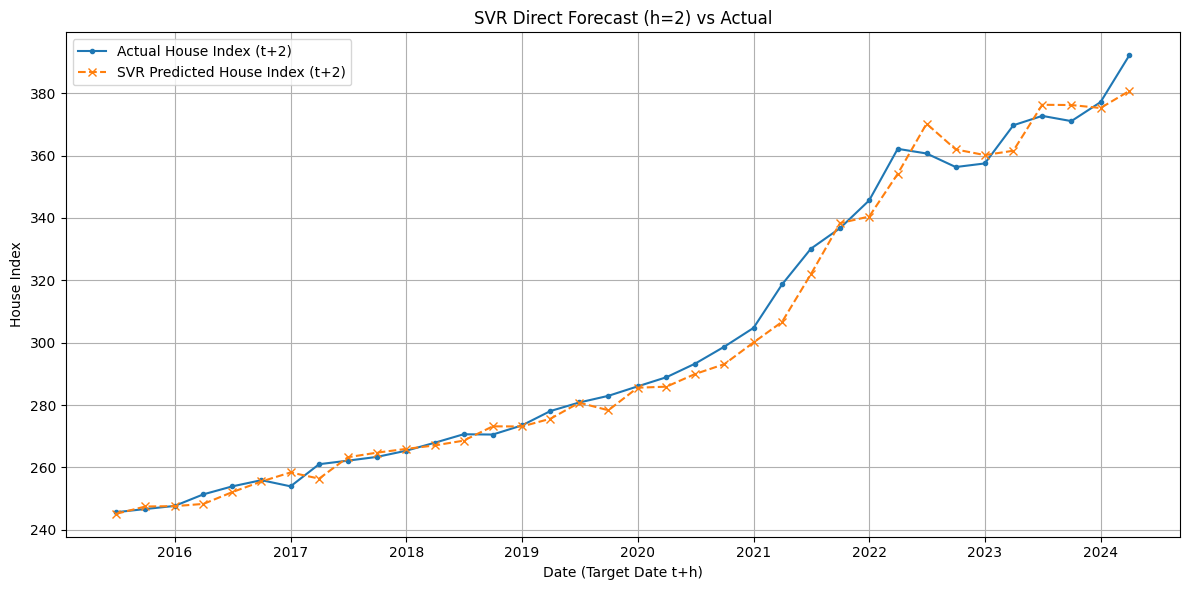


--- Completed Run for Horizon h = 2 ---


In [5]:
# --- Code Template for Direct Multi-Step SVR Evaluation (Single Horizon) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta # More robust for month/quarter steps

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
# ************************************************************
# ****** CHANGE THIS VALUE FOR EACH RUN (1 through 8) ******
forecast_horizon = 2  # Example: Set to 1 for the first run
# ************************************************************

data_file_3feat = 'DC_Data_For_Lasso_3Feat.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36 # Number of forecasts to generate in walk-forward

print(f"--- Running Direct SVR Evaluation for Horizon h = {forecast_horizon} ---")

# --- Load Data ---
try:
    df_svr_input_raw = pd.read_csv(data_file_3feat, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print("Data loaded successfully.")

    # --- Prepare Data for Direct Forecasting at Horizon h ---
    target_col_diff = df_svr_input_raw.columns[0] # 'Target_House_Index_diff1'

    # Features X are the original features (known at time t)
    X_orig = df_svr_input_raw.drop(columns=[target_col_diff])

    # Target y is the differenced value h steps *ahead* (target at t+h)
    # Use shift(-h) to bring future target values back to the current feature time t
    y_diff_h = df_svr_input_raw[target_col_diff].shift(-forecast_horizon)

    # Combine features and target, align them by index (time t)
    df_aligned = X_orig.copy()
    df_aligned['Target_h'] = y_diff_h

    # Drop rows with NaN target (the last h rows where target couldn't be shifted back)
    df_aligned.dropna(subset=['Target_h'], inplace=True)

    X = df_aligned.drop(columns=['Target_h'])
    y = df_aligned['Target_h'] # This is the differenced target at t+h

    print(f"Aligned data shape for h={forecast_horizon}: {df_aligned.shape}")

    if len(df_aligned) < n_test * 2:
         raise ValueError(f"Not enough data after alignment for horizon {forecast_horizon} to support n_test={n_test}.")

    # --- Split Data ---
    X_train_full, X_test = X[:-n_test], X[-n_test:]
    y_train_full, y_test = y[:-n_test], y[-n_test:] # y_test contains target values at t+h

    print(f"Train set size: {len(X_train_full)}")
    print(f"Test set size: {len(X_test)}")


    # --- Walk-Forward Validation for Horizon h ---
    history_X = X_train_full.copy()
    history_y = y_train_full.copy() # Target values for t+h relative to history_X time t
    predictions_diff_h = [] # Store predictions for y(t+h) on the differenced scale

    scaler_X = StandardScaler()
    scaler_y = StandardScaler() # Scale target

    print("\nStarting walk-forward validation...")
    for t in range(len(X_test)):
        # Scale data (fit on history, transform history and current test point)
        X_train_scaled = scaler_X.fit_transform(history_X)
        y_train_scaled = scaler_y.fit_transform(history_y.values.reshape(-1, 1)).ravel()

        # Configure and fit SVR model for this specific horizon h
        model = SVR()
        model.fit(X_train_scaled, y_train_scaled)

        # Prepare the current test input point (features at time t)
        current_X_test = X_test.iloc[[t]]
        current_X_test_scaled = scaler_X.transform(current_X_test)

        # Predict the scaled target value h steps ahead
        y_pred_scaled = model.predict(current_X_test_scaled)

        # Inverse transform the prediction to the differenced scale
        # This is the predicted change between t+h-1 and t+h
        y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]
        predictions_diff_h.append(y_pred_diff)

        # Update history with data corresponding to time t
        # We add the FEATURES from X_test[t] and the TARGET from y_test[t] (which is value at t+h)
        history_X = pd.concat([history_X, current_X_test], ignore_index=False)
        history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
             print(f"Processed {t + 1}/{len(X_test)} steps...")

    print("Walk-forward validation complete.")

    # --- Inverse Differencing for Direct Strategy ---
    # Need Actual House_Index at time t+h-1 to calculate predicted level at t+h
    predictions_original_scale = []
    actual_original_scale = []
    actual_prev_original_scale = [] # Values at t+h-1 for DA calc

    test_indices = y_test.index # These are the target dates (t+h)

    for i in range(len(predictions_diff_h)):
        pred_diff = predictions_diff_h[i] # Predicted change HI(t+h) - HI(t+h-1)
        target_date = test_indices[i] # Date for which prediction is made (t+h)

        # Find the date for the previous actual value needed: t+h-1
        # Use relativedelta for safety with quarters/months
        prev_date = target_date - relativedelta(months=3)

        # Get actual values from master data
        try:
            actual_target_value = df_master.loc[target_date, 'House_Index']
            actual_prev_value = df_master.loc[prev_date, 'House_Index']

            # Calculate predicted level: Prev_Actual + Predicted_Diff
            predicted_original = actual_prev_value + pred_diff

            predictions_original_scale.append(predicted_original)
            actual_original_scale.append(actual_target_value)
            actual_prev_original_scale.append(actual_prev_value)

        except KeyError as e:
            print(f"Warning: Date not found in master data for inverse differencing: {e}. Skipping point.")
            # Append NaN or handle appropriately if skipping points
            # For simplicity here, we might let it fail or append NaN if errors are expected
            # If skipping, need to handle in metric calculation too.
            # Let's assume dates exist for now.


    # --- Calculate Metrics for Horizon h ---
    if not predictions_original_scale: # Check if any predictions were made
         print("\nNo valid predictions generated. Cannot calculate metrics.")
    else:
        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        # Use actual_prev_original_scale for DA
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        print("\n--- SVR Performance Metrics (Direct Strategy) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        # --- Optional: Plotting for Horizon h ---
        results_df = pd.DataFrame({
            'Actual_Original': actual_original_scale,
            'Predicted_Original': predictions_original_scale
        }, index=test_indices[:len(actual_original_scale)]) # Ensure index length matches data

        plt.figure(figsize=(12, 6))
        plt.plot(results_df.index, results_df['Actual_Original'], label=f'Actual House Index (t+{forecast_horizon})', marker='.')
        plt.plot(results_df.index, results_df['Predicted_Original'], label=f'SVR Predicted House Index (t+{forecast_horizon})', marker='x', linestyle='--')
        plt.title(f'SVR Direct Forecast (h={forecast_horizon}) vs Actual')
        plt.xlabel('Date (Target Date t+h)')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV files or DataFrames. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except IndexError as e:
    print(f"Error: Index error, possibly during data alignment or access. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Run for Horizon h = {forecast_horizon} ---")

--- Running Direct SVR Evaluation for Horizon h = 3 ---
Data loaded successfully.
Aligned data shape for h=3: (133, 4)
Train set size: 97
Test set size: 36

Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- SVR Performance Metrics (Direct Strategy) ---
Forecast Horizon (h): 3
MAE:  3.284
RMSE: 4.455
MAPE: 1.044%
DA:   80.556%


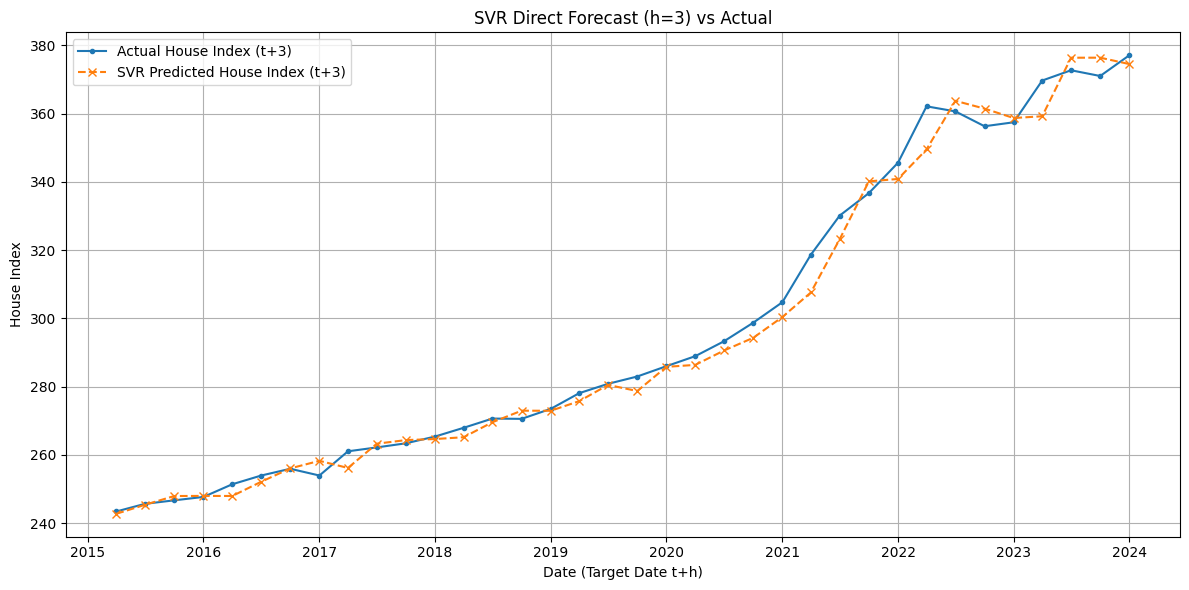


--- Completed Run for Horizon h = 3 ---


In [6]:
# --- Code Template for Direct Multi-Step SVR Evaluation (Single Horizon) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta # More robust for month/quarter steps

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
# ************************************************************
# ****** CHANGE THIS VALUE FOR EACH RUN (1 through 8) ******
forecast_horizon = 3  # Example: Set to 1 for the first run
# ************************************************************

data_file_3feat = 'DC_Data_For_Lasso_3Feat.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36 # Number of forecasts to generate in walk-forward

print(f"--- Running Direct SVR Evaluation for Horizon h = {forecast_horizon} ---")

# --- Load Data ---
try:
    df_svr_input_raw = pd.read_csv(data_file_3feat, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print("Data loaded successfully.")

    # --- Prepare Data for Direct Forecasting at Horizon h ---
    target_col_diff = df_svr_input_raw.columns[0] # 'Target_House_Index_diff1'

    # Features X are the original features (known at time t)
    X_orig = df_svr_input_raw.drop(columns=[target_col_diff])

    # Target y is the differenced value h steps *ahead* (target at t+h)
    # Use shift(-h) to bring future target values back to the current feature time t
    y_diff_h = df_svr_input_raw[target_col_diff].shift(-forecast_horizon)

    # Combine features and target, align them by index (time t)
    df_aligned = X_orig.copy()
    df_aligned['Target_h'] = y_diff_h

    # Drop rows with NaN target (the last h rows where target couldn't be shifted back)
    df_aligned.dropna(subset=['Target_h'], inplace=True)

    X = df_aligned.drop(columns=['Target_h'])
    y = df_aligned['Target_h'] # This is the differenced target at t+h

    print(f"Aligned data shape for h={forecast_horizon}: {df_aligned.shape}")

    if len(df_aligned) < n_test * 2:
         raise ValueError(f"Not enough data after alignment for horizon {forecast_horizon} to support n_test={n_test}.")

    # --- Split Data ---
    X_train_full, X_test = X[:-n_test], X[-n_test:]
    y_train_full, y_test = y[:-n_test], y[-n_test:] # y_test contains target values at t+h

    print(f"Train set size: {len(X_train_full)}")
    print(f"Test set size: {len(X_test)}")


    # --- Walk-Forward Validation for Horizon h ---
    history_X = X_train_full.copy()
    history_y = y_train_full.copy() # Target values for t+h relative to history_X time t
    predictions_diff_h = [] # Store predictions for y(t+h) on the differenced scale

    scaler_X = StandardScaler()
    scaler_y = StandardScaler() # Scale target

    print("\nStarting walk-forward validation...")
    for t in range(len(X_test)):
        # Scale data (fit on history, transform history and current test point)
        X_train_scaled = scaler_X.fit_transform(history_X)
        y_train_scaled = scaler_y.fit_transform(history_y.values.reshape(-1, 1)).ravel()

        # Configure and fit SVR model for this specific horizon h
        model = SVR()
        model.fit(X_train_scaled, y_train_scaled)

        # Prepare the current test input point (features at time t)
        current_X_test = X_test.iloc[[t]]
        current_X_test_scaled = scaler_X.transform(current_X_test)

        # Predict the scaled target value h steps ahead
        y_pred_scaled = model.predict(current_X_test_scaled)

        # Inverse transform the prediction to the differenced scale
        # This is the predicted change between t+h-1 and t+h
        y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]
        predictions_diff_h.append(y_pred_diff)

        # Update history with data corresponding to time t
        # We add the FEATURES from X_test[t] and the TARGET from y_test[t] (which is value at t+h)
        history_X = pd.concat([history_X, current_X_test], ignore_index=False)
        history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
             print(f"Processed {t + 1}/{len(X_test)} steps...")

    print("Walk-forward validation complete.")

    # --- Inverse Differencing for Direct Strategy ---
    # Need Actual House_Index at time t+h-1 to calculate predicted level at t+h
    predictions_original_scale = []
    actual_original_scale = []
    actual_prev_original_scale = [] # Values at t+h-1 for DA calc

    test_indices = y_test.index # These are the target dates (t+h)

    for i in range(len(predictions_diff_h)):
        pred_diff = predictions_diff_h[i] # Predicted change HI(t+h) - HI(t+h-1)
        target_date = test_indices[i] # Date for which prediction is made (t+h)

        # Find the date for the previous actual value needed: t+h-1
        # Use relativedelta for safety with quarters/months
        prev_date = target_date - relativedelta(months=3)

        # Get actual values from master data
        try:
            actual_target_value = df_master.loc[target_date, 'House_Index']
            actual_prev_value = df_master.loc[prev_date, 'House_Index']

            # Calculate predicted level: Prev_Actual + Predicted_Diff
            predicted_original = actual_prev_value + pred_diff

            predictions_original_scale.append(predicted_original)
            actual_original_scale.append(actual_target_value)
            actual_prev_original_scale.append(actual_prev_value)

        except KeyError as e:
            print(f"Warning: Date not found in master data for inverse differencing: {e}. Skipping point.")
            # Append NaN or handle appropriately if skipping points
            # For simplicity here, we might let it fail or append NaN if errors are expected
            # If skipping, need to handle in metric calculation too.
            # Let's assume dates exist for now.


    # --- Calculate Metrics for Horizon h ---
    if not predictions_original_scale: # Check if any predictions were made
         print("\nNo valid predictions generated. Cannot calculate metrics.")
    else:
        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        # Use actual_prev_original_scale for DA
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        print("\n--- SVR Performance Metrics (Direct Strategy) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        # --- Optional: Plotting for Horizon h ---
        results_df = pd.DataFrame({
            'Actual_Original': actual_original_scale,
            'Predicted_Original': predictions_original_scale
        }, index=test_indices[:len(actual_original_scale)]) # Ensure index length matches data

        plt.figure(figsize=(12, 6))
        plt.plot(results_df.index, results_df['Actual_Original'], label=f'Actual House Index (t+{forecast_horizon})', marker='.')
        plt.plot(results_df.index, results_df['Predicted_Original'], label=f'SVR Predicted House Index (t+{forecast_horizon})', marker='x', linestyle='--')
        plt.title(f'SVR Direct Forecast (h={forecast_horizon}) vs Actual')
        plt.xlabel('Date (Target Date t+h)')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV files or DataFrames. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except IndexError as e:
    print(f"Error: Index error, possibly during data alignment or access. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Run for Horizon h = {forecast_horizon} ---")

--- Running Direct SVR Evaluation for Horizon h = 4 ---
Data loaded successfully.
Aligned data shape for h=4: (132, 4)
Train set size: 96
Test set size: 36

Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- SVR Performance Metrics (Direct Strategy) ---
Forecast Horizon (h): 4
MAE:  3.322
RMSE: 4.913
MAPE: 1.052%
DA:   75.000%


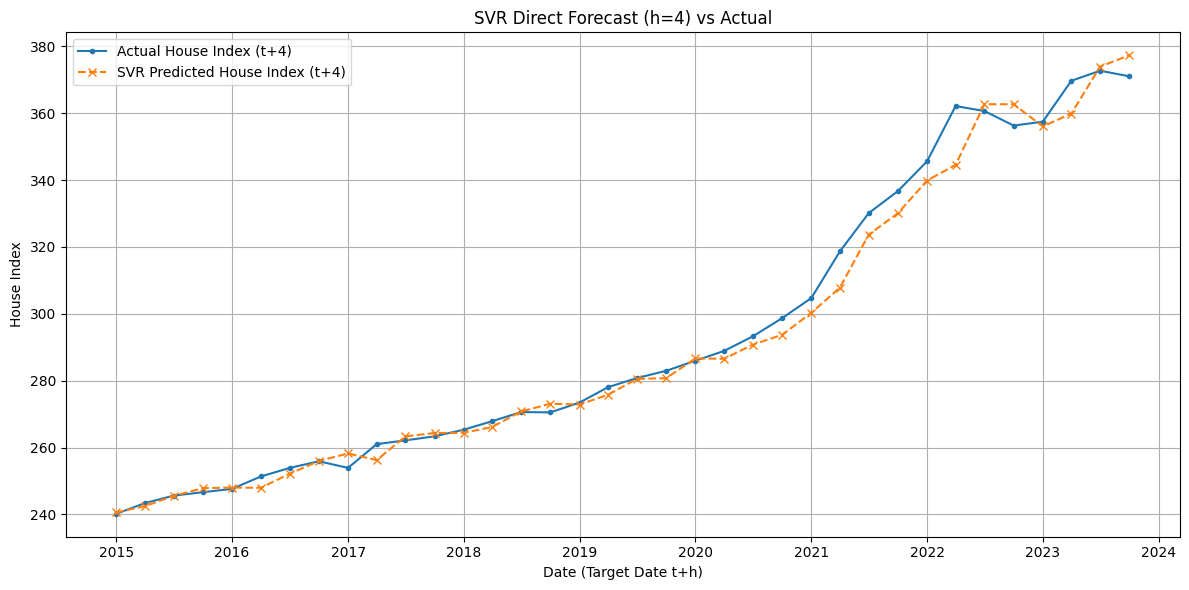


--- Completed Run for Horizon h = 4 ---


In [7]:
# --- Code Template for Direct Multi-Step SVR Evaluation (Single Horizon) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta # More robust for month/quarter steps

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
# ************************************************************
# ****** CHANGE THIS VALUE FOR EACH RUN (1 through 8) ******
forecast_horizon = 4  # Example: Set to 1 for the first run
# ************************************************************

data_file_3feat = 'DC_Data_For_Lasso_3Feat.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36 # Number of forecasts to generate in walk-forward

print(f"--- Running Direct SVR Evaluation for Horizon h = {forecast_horizon} ---")

# --- Load Data ---
try:
    df_svr_input_raw = pd.read_csv(data_file_3feat, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print("Data loaded successfully.")

    # --- Prepare Data for Direct Forecasting at Horizon h ---
    target_col_diff = df_svr_input_raw.columns[0] # 'Target_House_Index_diff1'

    # Features X are the original features (known at time t)
    X_orig = df_svr_input_raw.drop(columns=[target_col_diff])

    # Target y is the differenced value h steps *ahead* (target at t+h)
    # Use shift(-h) to bring future target values back to the current feature time t
    y_diff_h = df_svr_input_raw[target_col_diff].shift(-forecast_horizon)

    # Combine features and target, align them by index (time t)
    df_aligned = X_orig.copy()
    df_aligned['Target_h'] = y_diff_h

    # Drop rows with NaN target (the last h rows where target couldn't be shifted back)
    df_aligned.dropna(subset=['Target_h'], inplace=True)

    X = df_aligned.drop(columns=['Target_h'])
    y = df_aligned['Target_h'] # This is the differenced target at t+h

    print(f"Aligned data shape for h={forecast_horizon}: {df_aligned.shape}")

    if len(df_aligned) < n_test * 2:
         raise ValueError(f"Not enough data after alignment for horizon {forecast_horizon} to support n_test={n_test}.")

    # --- Split Data ---
    X_train_full, X_test = X[:-n_test], X[-n_test:]
    y_train_full, y_test = y[:-n_test], y[-n_test:] # y_test contains target values at t+h

    print(f"Train set size: {len(X_train_full)}")
    print(f"Test set size: {len(X_test)}")


    # --- Walk-Forward Validation for Horizon h ---
    history_X = X_train_full.copy()
    history_y = y_train_full.copy() # Target values for t+h relative to history_X time t
    predictions_diff_h = [] # Store predictions for y(t+h) on the differenced scale

    scaler_X = StandardScaler()
    scaler_y = StandardScaler() # Scale target

    print("\nStarting walk-forward validation...")
    for t in range(len(X_test)):
        # Scale data (fit on history, transform history and current test point)
        X_train_scaled = scaler_X.fit_transform(history_X)
        y_train_scaled = scaler_y.fit_transform(history_y.values.reshape(-1, 1)).ravel()

        # Configure and fit SVR model for this specific horizon h
        model = SVR()
        model.fit(X_train_scaled, y_train_scaled)

        # Prepare the current test input point (features at time t)
        current_X_test = X_test.iloc[[t]]
        current_X_test_scaled = scaler_X.transform(current_X_test)

        # Predict the scaled target value h steps ahead
        y_pred_scaled = model.predict(current_X_test_scaled)

        # Inverse transform the prediction to the differenced scale
        # This is the predicted change between t+h-1 and t+h
        y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]
        predictions_diff_h.append(y_pred_diff)

        # Update history with data corresponding to time t
        # We add the FEATURES from X_test[t] and the TARGET from y_test[t] (which is value at t+h)
        history_X = pd.concat([history_X, current_X_test], ignore_index=False)
        history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
             print(f"Processed {t + 1}/{len(X_test)} steps...")

    print("Walk-forward validation complete.")

    # --- Inverse Differencing for Direct Strategy ---
    # Need Actual House_Index at time t+h-1 to calculate predicted level at t+h
    predictions_original_scale = []
    actual_original_scale = []
    actual_prev_original_scale = [] # Values at t+h-1 for DA calc

    test_indices = y_test.index # These are the target dates (t+h)

    for i in range(len(predictions_diff_h)):
        pred_diff = predictions_diff_h[i] # Predicted change HI(t+h) - HI(t+h-1)
        target_date = test_indices[i] # Date for which prediction is made (t+h)

        # Find the date for the previous actual value needed: t+h-1
        # Use relativedelta for safety with quarters/months
        prev_date = target_date - relativedelta(months=3)

        # Get actual values from master data
        try:
            actual_target_value = df_master.loc[target_date, 'House_Index']
            actual_prev_value = df_master.loc[prev_date, 'House_Index']

            # Calculate predicted level: Prev_Actual + Predicted_Diff
            predicted_original = actual_prev_value + pred_diff

            predictions_original_scale.append(predicted_original)
            actual_original_scale.append(actual_target_value)
            actual_prev_original_scale.append(actual_prev_value)

        except KeyError as e:
            print(f"Warning: Date not found in master data for inverse differencing: {e}. Skipping point.")
            # Append NaN or handle appropriately if skipping points
            # For simplicity here, we might let it fail or append NaN if errors are expected
            # If skipping, need to handle in metric calculation too.
            # Let's assume dates exist for now.


    # --- Calculate Metrics for Horizon h ---
    if not predictions_original_scale: # Check if any predictions were made
         print("\nNo valid predictions generated. Cannot calculate metrics.")
    else:
        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        # Use actual_prev_original_scale for DA
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        print("\n--- SVR Performance Metrics (Direct Strategy) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        # --- Optional: Plotting for Horizon h ---
        results_df = pd.DataFrame({
            'Actual_Original': actual_original_scale,
            'Predicted_Original': predictions_original_scale
        }, index=test_indices[:len(actual_original_scale)]) # Ensure index length matches data

        plt.figure(figsize=(12, 6))
        plt.plot(results_df.index, results_df['Actual_Original'], label=f'Actual House Index (t+{forecast_horizon})', marker='.')
        plt.plot(results_df.index, results_df['Predicted_Original'], label=f'SVR Predicted House Index (t+{forecast_horizon})', marker='x', linestyle='--')
        plt.title(f'SVR Direct Forecast (h={forecast_horizon}) vs Actual')
        plt.xlabel('Date (Target Date t+h)')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV files or DataFrames. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except IndexError as e:
    print(f"Error: Index error, possibly during data alignment or access. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Run for Horizon h = {forecast_horizon} ---")

--- Running Direct SVR Evaluation for Horizon h = 5 ---
Data loaded successfully.
Aligned data shape for h=5: (131, 4)
Train set size: 95
Test set size: 36

Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- SVR Performance Metrics (Direct Strategy) ---
Forecast Horizon (h): 5
MAE:  3.426
RMSE: 5.053
MAPE: 1.094%
DA:   83.333%


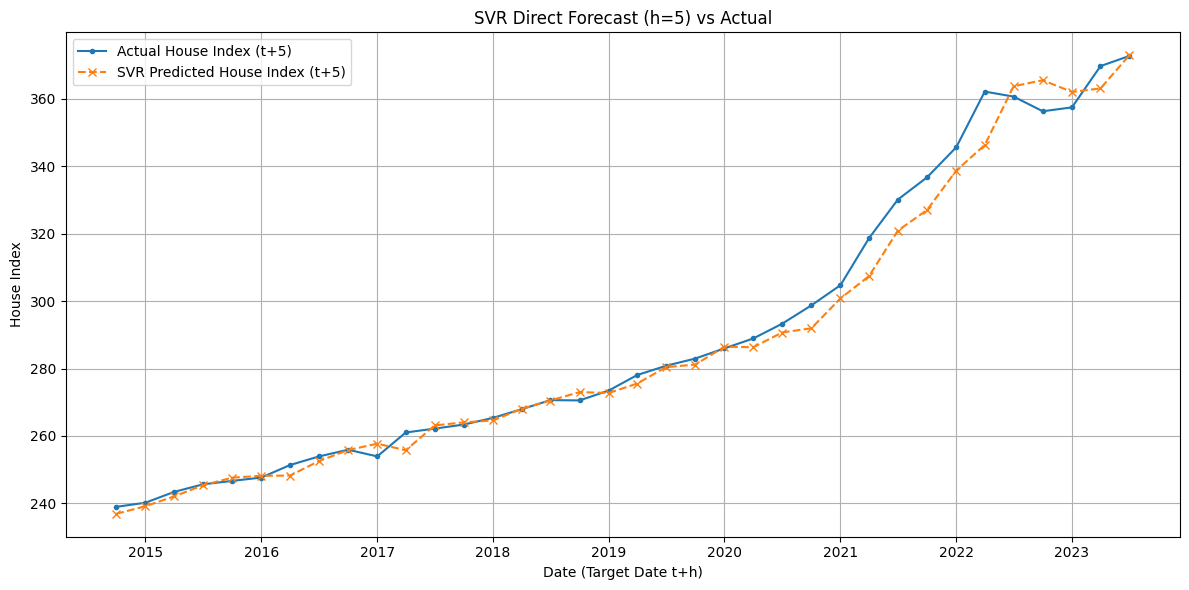


--- Completed Run for Horizon h = 5 ---


In [8]:
# --- Code Template for Direct Multi-Step SVR Evaluation (Single Horizon) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta # More robust for month/quarter steps

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
# ************************************************************
# ****** CHANGE THIS VALUE FOR EACH RUN (1 through 8) ******
forecast_horizon = 5  # Example: Set to 1 for the first run
# ************************************************************

data_file_3feat = 'DC_Data_For_Lasso_3Feat.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36 # Number of forecasts to generate in walk-forward

print(f"--- Running Direct SVR Evaluation for Horizon h = {forecast_horizon} ---")

# --- Load Data ---
try:
    df_svr_input_raw = pd.read_csv(data_file_3feat, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print("Data loaded successfully.")

    # --- Prepare Data for Direct Forecasting at Horizon h ---
    target_col_diff = df_svr_input_raw.columns[0] # 'Target_House_Index_diff1'

    # Features X are the original features (known at time t)
    X_orig = df_svr_input_raw.drop(columns=[target_col_diff])

    # Target y is the differenced value h steps *ahead* (target at t+h)
    # Use shift(-h) to bring future target values back to the current feature time t
    y_diff_h = df_svr_input_raw[target_col_diff].shift(-forecast_horizon)

    # Combine features and target, align them by index (time t)
    df_aligned = X_orig.copy()
    df_aligned['Target_h'] = y_diff_h

    # Drop rows with NaN target (the last h rows where target couldn't be shifted back)
    df_aligned.dropna(subset=['Target_h'], inplace=True)

    X = df_aligned.drop(columns=['Target_h'])
    y = df_aligned['Target_h'] # This is the differenced target at t+h

    print(f"Aligned data shape for h={forecast_horizon}: {df_aligned.shape}")

    if len(df_aligned) < n_test * 2:
         raise ValueError(f"Not enough data after alignment for horizon {forecast_horizon} to support n_test={n_test}.")

    # --- Split Data ---
    X_train_full, X_test = X[:-n_test], X[-n_test:]
    y_train_full, y_test = y[:-n_test], y[-n_test:] # y_test contains target values at t+h

    print(f"Train set size: {len(X_train_full)}")
    print(f"Test set size: {len(X_test)}")


    # --- Walk-Forward Validation for Horizon h ---
    history_X = X_train_full.copy()
    history_y = y_train_full.copy() # Target values for t+h relative to history_X time t
    predictions_diff_h = [] # Store predictions for y(t+h) on the differenced scale

    scaler_X = StandardScaler()
    scaler_y = StandardScaler() # Scale target

    print("\nStarting walk-forward validation...")
    for t in range(len(X_test)):
        # Scale data (fit on history, transform history and current test point)
        X_train_scaled = scaler_X.fit_transform(history_X)
        y_train_scaled = scaler_y.fit_transform(history_y.values.reshape(-1, 1)).ravel()

        # Configure and fit SVR model for this specific horizon h
        model = SVR()
        model.fit(X_train_scaled, y_train_scaled)

        # Prepare the current test input point (features at time t)
        current_X_test = X_test.iloc[[t]]
        current_X_test_scaled = scaler_X.transform(current_X_test)

        # Predict the scaled target value h steps ahead
        y_pred_scaled = model.predict(current_X_test_scaled)

        # Inverse transform the prediction to the differenced scale
        # This is the predicted change between t+h-1 and t+h
        y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]
        predictions_diff_h.append(y_pred_diff)

        # Update history with data corresponding to time t
        # We add the FEATURES from X_test[t] and the TARGET from y_test[t] (which is value at t+h)
        history_X = pd.concat([history_X, current_X_test], ignore_index=False)
        history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
             print(f"Processed {t + 1}/{len(X_test)} steps...")

    print("Walk-forward validation complete.")

    # --- Inverse Differencing for Direct Strategy ---
    # Need Actual House_Index at time t+h-1 to calculate predicted level at t+h
    predictions_original_scale = []
    actual_original_scale = []
    actual_prev_original_scale = [] # Values at t+h-1 for DA calc

    test_indices = y_test.index # These are the target dates (t+h)

    for i in range(len(predictions_diff_h)):
        pred_diff = predictions_diff_h[i] # Predicted change HI(t+h) - HI(t+h-1)
        target_date = test_indices[i] # Date for which prediction is made (t+h)

        # Find the date for the previous actual value needed: t+h-1
        # Use relativedelta for safety with quarters/months
        prev_date = target_date - relativedelta(months=3)

        # Get actual values from master data
        try:
            actual_target_value = df_master.loc[target_date, 'House_Index']
            actual_prev_value = df_master.loc[prev_date, 'House_Index']

            # Calculate predicted level: Prev_Actual + Predicted_Diff
            predicted_original = actual_prev_value + pred_diff

            predictions_original_scale.append(predicted_original)
            actual_original_scale.append(actual_target_value)
            actual_prev_original_scale.append(actual_prev_value)

        except KeyError as e:
            print(f"Warning: Date not found in master data for inverse differencing: {e}. Skipping point.")
            # Append NaN or handle appropriately if skipping points
            # For simplicity here, we might let it fail or append NaN if errors are expected
            # If skipping, need to handle in metric calculation too.
            # Let's assume dates exist for now.


    # --- Calculate Metrics for Horizon h ---
    if not predictions_original_scale: # Check if any predictions were made
         print("\nNo valid predictions generated. Cannot calculate metrics.")
    else:
        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        # Use actual_prev_original_scale for DA
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        print("\n--- SVR Performance Metrics (Direct Strategy) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        # --- Optional: Plotting for Horizon h ---
        results_df = pd.DataFrame({
            'Actual_Original': actual_original_scale,
            'Predicted_Original': predictions_original_scale
        }, index=test_indices[:len(actual_original_scale)]) # Ensure index length matches data

        plt.figure(figsize=(12, 6))
        plt.plot(results_df.index, results_df['Actual_Original'], label=f'Actual House Index (t+{forecast_horizon})', marker='.')
        plt.plot(results_df.index, results_df['Predicted_Original'], label=f'SVR Predicted House Index (t+{forecast_horizon})', marker='x', linestyle='--')
        plt.title(f'SVR Direct Forecast (h={forecast_horizon}) vs Actual')
        plt.xlabel('Date (Target Date t+h)')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV files or DataFrames. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except IndexError as e:
    print(f"Error: Index error, possibly during data alignment or access. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Run for Horizon h = {forecast_horizon} ---")

--- Running Direct SVR Evaluation for Horizon h = 6 ---
Data loaded successfully.
Aligned data shape for h=6: (130, 4)
Train set size: 94
Test set size: 36

Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- SVR Performance Metrics (Direct Strategy) ---
Forecast Horizon (h): 6
MAE:  3.331
RMSE: 4.869
MAPE: 1.069%
DA:   83.333%


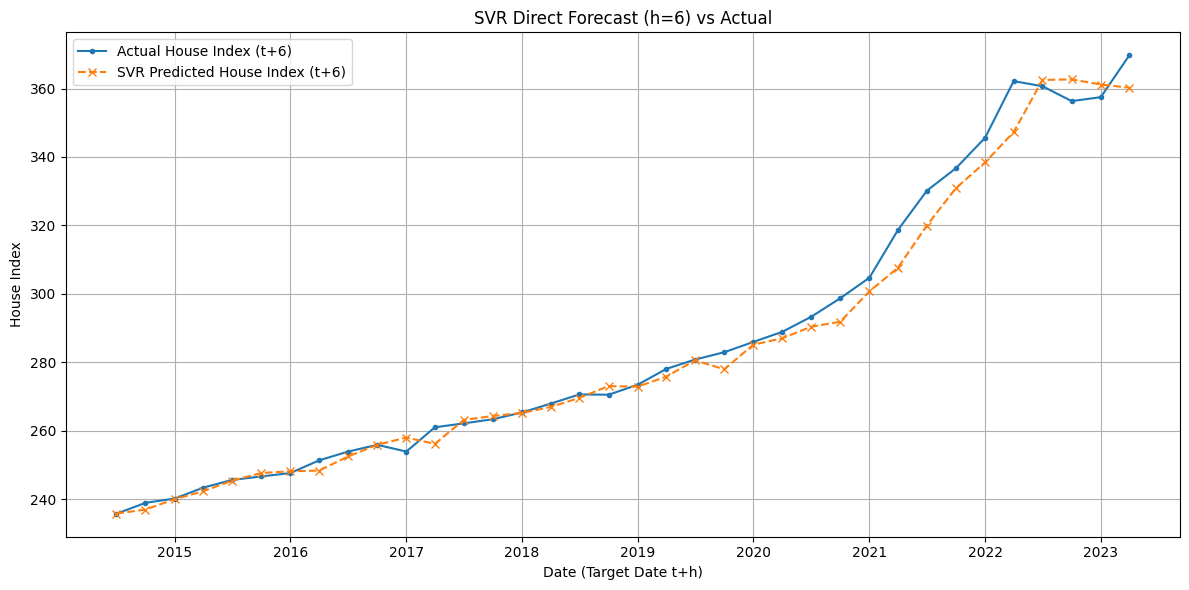


--- Completed Run for Horizon h = 6 ---


In [9]:
# --- Code Template for Direct Multi-Step SVR Evaluation (Single Horizon) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta # More robust for month/quarter steps

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
# ************************************************************
# ****** CHANGE THIS VALUE FOR EACH RUN (1 through 8) ******
forecast_horizon = 6  # Example: Set to 1 for the first run
# ************************************************************

data_file_3feat = 'DC_Data_For_Lasso_3Feat.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36 # Number of forecasts to generate in walk-forward

print(f"--- Running Direct SVR Evaluation for Horizon h = {forecast_horizon} ---")

# --- Load Data ---
try:
    df_svr_input_raw = pd.read_csv(data_file_3feat, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print("Data loaded successfully.")

    # --- Prepare Data for Direct Forecasting at Horizon h ---
    target_col_diff = df_svr_input_raw.columns[0] # 'Target_House_Index_diff1'

    # Features X are the original features (known at time t)
    X_orig = df_svr_input_raw.drop(columns=[target_col_diff])

    # Target y is the differenced value h steps *ahead* (target at t+h)
    # Use shift(-h) to bring future target values back to the current feature time t
    y_diff_h = df_svr_input_raw[target_col_diff].shift(-forecast_horizon)

    # Combine features and target, align them by index (time t)
    df_aligned = X_orig.copy()
    df_aligned['Target_h'] = y_diff_h

    # Drop rows with NaN target (the last h rows where target couldn't be shifted back)
    df_aligned.dropna(subset=['Target_h'], inplace=True)

    X = df_aligned.drop(columns=['Target_h'])
    y = df_aligned['Target_h'] # This is the differenced target at t+h

    print(f"Aligned data shape for h={forecast_horizon}: {df_aligned.shape}")

    if len(df_aligned) < n_test * 2:
         raise ValueError(f"Not enough data after alignment for horizon {forecast_horizon} to support n_test={n_test}.")

    # --- Split Data ---
    X_train_full, X_test = X[:-n_test], X[-n_test:]
    y_train_full, y_test = y[:-n_test], y[-n_test:] # y_test contains target values at t+h

    print(f"Train set size: {len(X_train_full)}")
    print(f"Test set size: {len(X_test)}")


    # --- Walk-Forward Validation for Horizon h ---
    history_X = X_train_full.copy()
    history_y = y_train_full.copy() # Target values for t+h relative to history_X time t
    predictions_diff_h = [] # Store predictions for y(t+h) on the differenced scale

    scaler_X = StandardScaler()
    scaler_y = StandardScaler() # Scale target

    print("\nStarting walk-forward validation...")
    for t in range(len(X_test)):
        # Scale data (fit on history, transform history and current test point)
        X_train_scaled = scaler_X.fit_transform(history_X)
        y_train_scaled = scaler_y.fit_transform(history_y.values.reshape(-1, 1)).ravel()

        # Configure and fit SVR model for this specific horizon h
        model = SVR()
        model.fit(X_train_scaled, y_train_scaled)

        # Prepare the current test input point (features at time t)
        current_X_test = X_test.iloc[[t]]
        current_X_test_scaled = scaler_X.transform(current_X_test)

        # Predict the scaled target value h steps ahead
        y_pred_scaled = model.predict(current_X_test_scaled)

        # Inverse transform the prediction to the differenced scale
        # This is the predicted change between t+h-1 and t+h
        y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]
        predictions_diff_h.append(y_pred_diff)

        # Update history with data corresponding to time t
        # We add the FEATURES from X_test[t] and the TARGET from y_test[t] (which is value at t+h)
        history_X = pd.concat([history_X, current_X_test], ignore_index=False)
        history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
             print(f"Processed {t + 1}/{len(X_test)} steps...")

    print("Walk-forward validation complete.")

    # --- Inverse Differencing for Direct Strategy ---
    # Need Actual House_Index at time t+h-1 to calculate predicted level at t+h
    predictions_original_scale = []
    actual_original_scale = []
    actual_prev_original_scale = [] # Values at t+h-1 for DA calc

    test_indices = y_test.index # These are the target dates (t+h)

    for i in range(len(predictions_diff_h)):
        pred_diff = predictions_diff_h[i] # Predicted change HI(t+h) - HI(t+h-1)
        target_date = test_indices[i] # Date for which prediction is made (t+h)

        # Find the date for the previous actual value needed: t+h-1
        # Use relativedelta for safety with quarters/months
        prev_date = target_date - relativedelta(months=3)

        # Get actual values from master data
        try:
            actual_target_value = df_master.loc[target_date, 'House_Index']
            actual_prev_value = df_master.loc[prev_date, 'House_Index']

            # Calculate predicted level: Prev_Actual + Predicted_Diff
            predicted_original = actual_prev_value + pred_diff

            predictions_original_scale.append(predicted_original)
            actual_original_scale.append(actual_target_value)
            actual_prev_original_scale.append(actual_prev_value)

        except KeyError as e:
            print(f"Warning: Date not found in master data for inverse differencing: {e}. Skipping point.")
            # Append NaN or handle appropriately if skipping points
            # For simplicity here, we might let it fail or append NaN if errors are expected
            # If skipping, need to handle in metric calculation too.
            # Let's assume dates exist for now.


    # --- Calculate Metrics for Horizon h ---
    if not predictions_original_scale: # Check if any predictions were made
         print("\nNo valid predictions generated. Cannot calculate metrics.")
    else:
        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        # Use actual_prev_original_scale for DA
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        print("\n--- SVR Performance Metrics (Direct Strategy) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        # --- Optional: Plotting for Horizon h ---
        results_df = pd.DataFrame({
            'Actual_Original': actual_original_scale,
            'Predicted_Original': predictions_original_scale
        }, index=test_indices[:len(actual_original_scale)]) # Ensure index length matches data

        plt.figure(figsize=(12, 6))
        plt.plot(results_df.index, results_df['Actual_Original'], label=f'Actual House Index (t+{forecast_horizon})', marker='.')
        plt.plot(results_df.index, results_df['Predicted_Original'], label=f'SVR Predicted House Index (t+{forecast_horizon})', marker='x', linestyle='--')
        plt.title(f'SVR Direct Forecast (h={forecast_horizon}) vs Actual')
        plt.xlabel('Date (Target Date t+h)')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV files or DataFrames. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except IndexError as e:
    print(f"Error: Index error, possibly during data alignment or access. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Run for Horizon h = {forecast_horizon} ---")

--- Running Direct SVR Evaluation for Horizon h = 7 ---
Data loaded successfully.
Aligned data shape for h=7: (129, 4)
Train set size: 93
Test set size: 36

Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- SVR Performance Metrics (Direct Strategy) ---
Forecast Horizon (h): 7
MAE:  2.933
RMSE: 4.279
MAPE: 0.977%
DA:   80.556%


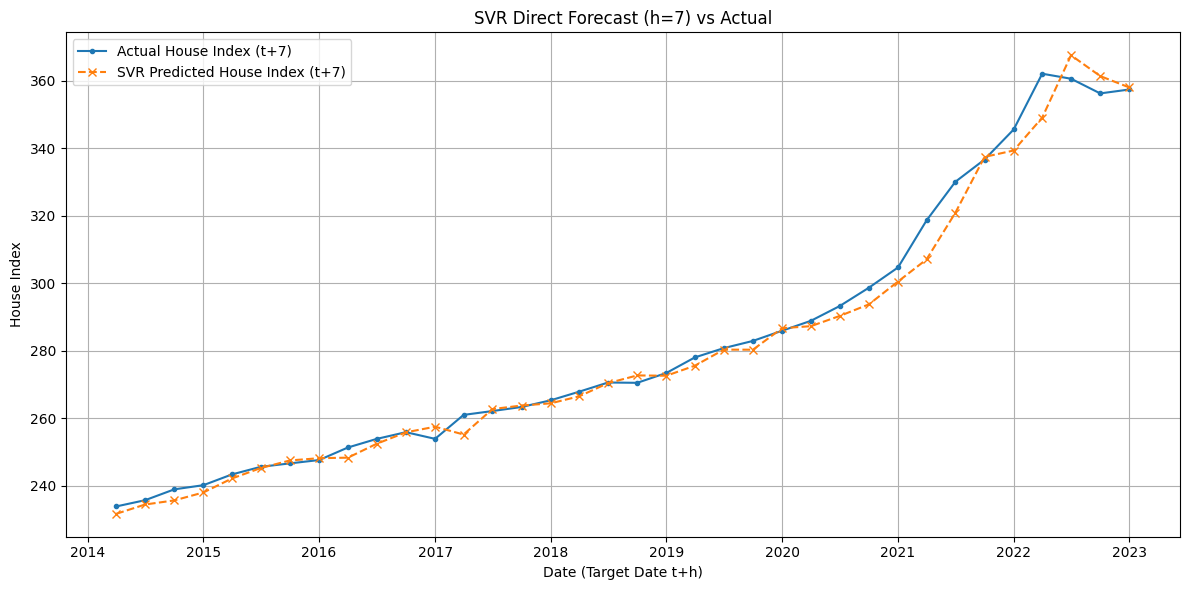


--- Completed Run for Horizon h = 7 ---


In [10]:
# --- Code Template for Direct Multi-Step SVR Evaluation (Single Horizon) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta # More robust for month/quarter steps

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
# ************************************************************
# ****** CHANGE THIS VALUE FOR EACH RUN (1 through 8) ******
forecast_horizon = 7  # Example: Set to 1 for the first run
# ************************************************************

data_file_3feat = 'DC_Data_For_Lasso_3Feat.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36 # Number of forecasts to generate in walk-forward

print(f"--- Running Direct SVR Evaluation for Horizon h = {forecast_horizon} ---")

# --- Load Data ---
try:
    df_svr_input_raw = pd.read_csv(data_file_3feat, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print("Data loaded successfully.")

    # --- Prepare Data for Direct Forecasting at Horizon h ---
    target_col_diff = df_svr_input_raw.columns[0] # 'Target_House_Index_diff1'

    # Features X are the original features (known at time t)
    X_orig = df_svr_input_raw.drop(columns=[target_col_diff])

    # Target y is the differenced value h steps *ahead* (target at t+h)
    # Use shift(-h) to bring future target values back to the current feature time t
    y_diff_h = df_svr_input_raw[target_col_diff].shift(-forecast_horizon)

    # Combine features and target, align them by index (time t)
    df_aligned = X_orig.copy()
    df_aligned['Target_h'] = y_diff_h

    # Drop rows with NaN target (the last h rows where target couldn't be shifted back)
    df_aligned.dropna(subset=['Target_h'], inplace=True)

    X = df_aligned.drop(columns=['Target_h'])
    y = df_aligned['Target_h'] # This is the differenced target at t+h

    print(f"Aligned data shape for h={forecast_horizon}: {df_aligned.shape}")

    if len(df_aligned) < n_test * 2:
         raise ValueError(f"Not enough data after alignment for horizon {forecast_horizon} to support n_test={n_test}.")

    # --- Split Data ---
    X_train_full, X_test = X[:-n_test], X[-n_test:]
    y_train_full, y_test = y[:-n_test], y[-n_test:] # y_test contains target values at t+h

    print(f"Train set size: {len(X_train_full)}")
    print(f"Test set size: {len(X_test)}")


    # --- Walk-Forward Validation for Horizon h ---
    history_X = X_train_full.copy()
    history_y = y_train_full.copy() # Target values for t+h relative to history_X time t
    predictions_diff_h = [] # Store predictions for y(t+h) on the differenced scale

    scaler_X = StandardScaler()
    scaler_y = StandardScaler() # Scale target

    print("\nStarting walk-forward validation...")
    for t in range(len(X_test)):
        # Scale data (fit on history, transform history and current test point)
        X_train_scaled = scaler_X.fit_transform(history_X)
        y_train_scaled = scaler_y.fit_transform(history_y.values.reshape(-1, 1)).ravel()

        # Configure and fit SVR model for this specific horizon h
        model = SVR()
        model.fit(X_train_scaled, y_train_scaled)

        # Prepare the current test input point (features at time t)
        current_X_test = X_test.iloc[[t]]
        current_X_test_scaled = scaler_X.transform(current_X_test)

        # Predict the scaled target value h steps ahead
        y_pred_scaled = model.predict(current_X_test_scaled)

        # Inverse transform the prediction to the differenced scale
        # This is the predicted change between t+h-1 and t+h
        y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]
        predictions_diff_h.append(y_pred_diff)

        # Update history with data corresponding to time t
        # We add the FEATURES from X_test[t] and the TARGET from y_test[t] (which is value at t+h)
        history_X = pd.concat([history_X, current_X_test], ignore_index=False)
        history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
             print(f"Processed {t + 1}/{len(X_test)} steps...")

    print("Walk-forward validation complete.")

    # --- Inverse Differencing for Direct Strategy ---
    # Need Actual House_Index at time t+h-1 to calculate predicted level at t+h
    predictions_original_scale = []
    actual_original_scale = []
    actual_prev_original_scale = [] # Values at t+h-1 for DA calc

    test_indices = y_test.index # These are the target dates (t+h)

    for i in range(len(predictions_diff_h)):
        pred_diff = predictions_diff_h[i] # Predicted change HI(t+h) - HI(t+h-1)
        target_date = test_indices[i] # Date for which prediction is made (t+h)

        # Find the date for the previous actual value needed: t+h-1
        # Use relativedelta for safety with quarters/months
        prev_date = target_date - relativedelta(months=3)

        # Get actual values from master data
        try:
            actual_target_value = df_master.loc[target_date, 'House_Index']
            actual_prev_value = df_master.loc[prev_date, 'House_Index']

            # Calculate predicted level: Prev_Actual + Predicted_Diff
            predicted_original = actual_prev_value + pred_diff

            predictions_original_scale.append(predicted_original)
            actual_original_scale.append(actual_target_value)
            actual_prev_original_scale.append(actual_prev_value)

        except KeyError as e:
            print(f"Warning: Date not found in master data for inverse differencing: {e}. Skipping point.")
            # Append NaN or handle appropriately if skipping points
            # For simplicity here, we might let it fail or append NaN if errors are expected
            # If skipping, need to handle in metric calculation too.
            # Let's assume dates exist for now.


    # --- Calculate Metrics for Horizon h ---
    if not predictions_original_scale: # Check if any predictions were made
         print("\nNo valid predictions generated. Cannot calculate metrics.")
    else:
        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        # Use actual_prev_original_scale for DA
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        print("\n--- SVR Performance Metrics (Direct Strategy) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        # --- Optional: Plotting for Horizon h ---
        results_df = pd.DataFrame({
            'Actual_Original': actual_original_scale,
            'Predicted_Original': predictions_original_scale
        }, index=test_indices[:len(actual_original_scale)]) # Ensure index length matches data

        plt.figure(figsize=(12, 6))
        plt.plot(results_df.index, results_df['Actual_Original'], label=f'Actual House Index (t+{forecast_horizon})', marker='.')
        plt.plot(results_df.index, results_df['Predicted_Original'], label=f'SVR Predicted House Index (t+{forecast_horizon})', marker='x', linestyle='--')
        plt.title(f'SVR Direct Forecast (h={forecast_horizon}) vs Actual')
        plt.xlabel('Date (Target Date t+h)')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV files or DataFrames. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except IndexError as e:
    print(f"Error: Index error, possibly during data alignment or access. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Run for Horizon h = {forecast_horizon} ---")

--- Running Direct SVR Evaluation for Horizon h = 8 ---
Data loaded successfully.
Aligned data shape for h=8: (128, 4)
Train set size: 92
Test set size: 36

Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- SVR Performance Metrics (Direct Strategy) ---
Forecast Horizon (h): 8
MAE:  3.095
RMSE: 4.507
MAPE: 1.029%
DA:   80.556%


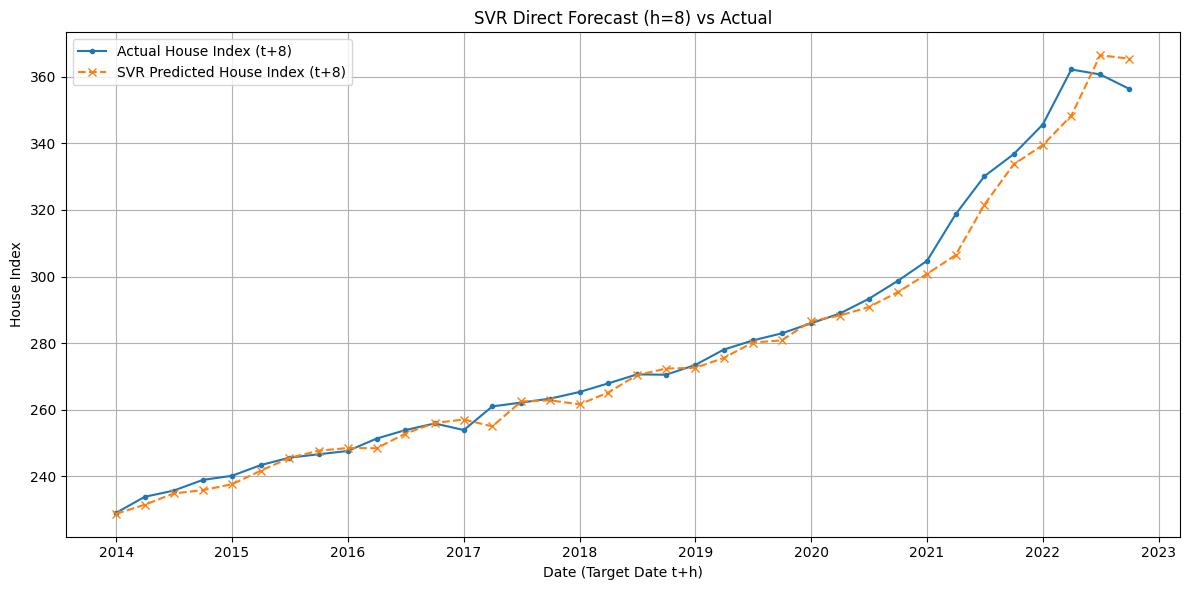


--- Completed Run for Horizon h = 8 ---


In [11]:
# --- Code Template for Direct Multi-Step SVR Evaluation (Single Horizon) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta # More robust for month/quarter steps

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
# ************************************************************
# ****** CHANGE THIS VALUE FOR EACH RUN (1 through 8) ******
forecast_horizon = 8  # Example: Set to 1 for the first run
# ************************************************************

data_file_3feat = 'DC_Data_For_Lasso_3Feat.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36 # Number of forecasts to generate in walk-forward

print(f"--- Running Direct SVR Evaluation for Horizon h = {forecast_horizon} ---")

# --- Load Data ---
try:
    df_svr_input_raw = pd.read_csv(data_file_3feat, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print("Data loaded successfully.")

    # --- Prepare Data for Direct Forecasting at Horizon h ---
    target_col_diff = df_svr_input_raw.columns[0] # 'Target_House_Index_diff1'

    # Features X are the original features (known at time t)
    X_orig = df_svr_input_raw.drop(columns=[target_col_diff])

    # Target y is the differenced value h steps *ahead* (target at t+h)
    # Use shift(-h) to bring future target values back to the current feature time t
    y_diff_h = df_svr_input_raw[target_col_diff].shift(-forecast_horizon)

    # Combine features and target, align them by index (time t)
    df_aligned = X_orig.copy()
    df_aligned['Target_h'] = y_diff_h

    # Drop rows with NaN target (the last h rows where target couldn't be shifted back)
    df_aligned.dropna(subset=['Target_h'], inplace=True)

    X = df_aligned.drop(columns=['Target_h'])
    y = df_aligned['Target_h'] # This is the differenced target at t+h

    print(f"Aligned data shape for h={forecast_horizon}: {df_aligned.shape}")

    if len(df_aligned) < n_test * 2:
         raise ValueError(f"Not enough data after alignment for horizon {forecast_horizon} to support n_test={n_test}.")

    # --- Split Data ---
    X_train_full, X_test = X[:-n_test], X[-n_test:]
    y_train_full, y_test = y[:-n_test], y[-n_test:] # y_test contains target values at t+h

    print(f"Train set size: {len(X_train_full)}")
    print(f"Test set size: {len(X_test)}")


    # --- Walk-Forward Validation for Horizon h ---
    history_X = X_train_full.copy()
    history_y = y_train_full.copy() # Target values for t+h relative to history_X time t
    predictions_diff_h = [] # Store predictions for y(t+h) on the differenced scale

    scaler_X = StandardScaler()
    scaler_y = StandardScaler() # Scale target

    print("\nStarting walk-forward validation...")
    for t in range(len(X_test)):
        # Scale data (fit on history, transform history and current test point)
        X_train_scaled = scaler_X.fit_transform(history_X)
        y_train_scaled = scaler_y.fit_transform(history_y.values.reshape(-1, 1)).ravel()

        # Configure and fit SVR model for this specific horizon h
        model = SVR()
        model.fit(X_train_scaled, y_train_scaled)

        # Prepare the current test input point (features at time t)
        current_X_test = X_test.iloc[[t]]
        current_X_test_scaled = scaler_X.transform(current_X_test)

        # Predict the scaled target value h steps ahead
        y_pred_scaled = model.predict(current_X_test_scaled)

        # Inverse transform the prediction to the differenced scale
        # This is the predicted change between t+h-1 and t+h
        y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]
        predictions_diff_h.append(y_pred_diff)

        # Update history with data corresponding to time t
        # We add the FEATURES from X_test[t] and the TARGET from y_test[t] (which is value at t+h)
        history_X = pd.concat([history_X, current_X_test], ignore_index=False)
        history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
             print(f"Processed {t + 1}/{len(X_test)} steps...")

    print("Walk-forward validation complete.")

    # --- Inverse Differencing for Direct Strategy ---
    # Need Actual House_Index at time t+h-1 to calculate predicted level at t+h
    predictions_original_scale = []
    actual_original_scale = []
    actual_prev_original_scale = [] # Values at t+h-1 for DA calc

    test_indices = y_test.index # These are the target dates (t+h)

    for i in range(len(predictions_diff_h)):
        pred_diff = predictions_diff_h[i] # Predicted change HI(t+h) - HI(t+h-1)
        target_date = test_indices[i] # Date for which prediction is made (t+h)

        # Find the date for the previous actual value needed: t+h-1
        # Use relativedelta for safety with quarters/months
        prev_date = target_date - relativedelta(months=3)

        # Get actual values from master data
        try:
            actual_target_value = df_master.loc[target_date, 'House_Index']
            actual_prev_value = df_master.loc[prev_date, 'House_Index']

            # Calculate predicted level: Prev_Actual + Predicted_Diff
            predicted_original = actual_prev_value + pred_diff

            predictions_original_scale.append(predicted_original)
            actual_original_scale.append(actual_target_value)
            actual_prev_original_scale.append(actual_prev_value)

        except KeyError as e:
            print(f"Warning: Date not found in master data for inverse differencing: {e}. Skipping point.")
            # Append NaN or handle appropriately if skipping points
            # For simplicity here, we might let it fail or append NaN if errors are expected
            # If skipping, need to handle in metric calculation too.
            # Let's assume dates exist for now.


    # --- Calculate Metrics for Horizon h ---
    if not predictions_original_scale: # Check if any predictions were made
         print("\nNo valid predictions generated. Cannot calculate metrics.")
    else:
        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        # Use actual_prev_original_scale for DA
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        print("\n--- SVR Performance Metrics (Direct Strategy) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        # --- Optional: Plotting for Horizon h ---
        results_df = pd.DataFrame({
            'Actual_Original': actual_original_scale,
            'Predicted_Original': predictions_original_scale
        }, index=test_indices[:len(actual_original_scale)]) # Ensure index length matches data

        plt.figure(figsize=(12, 6))
        plt.plot(results_df.index, results_df['Actual_Original'], label=f'Actual House Index (t+{forecast_horizon})', marker='.')
        plt.plot(results_df.index, results_df['Predicted_Original'], label=f'SVR Predicted House Index (t+{forecast_horizon})', marker='x', linestyle='--')
        plt.title(f'SVR Direct Forecast (h={forecast_horizon}) vs Actual')
        plt.xlabel('Date (Target Date t+h)')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV files or DataFrames. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except IndexError as e:
    print(f"Error: Index error, possibly during data alignment or access. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Run for Horizon h = {forecast_horizon} ---")

--- Running Direct SVR Evaluation (All Features) for Horizon h = 8 ---
Data loaded successfully from DC_Data_For_Lasso.csv.
Input data shape: (133, 35)
Number of features being used: 34
Aligned data shape for h=8: (125, 35)
Train set size: 89
Test set size: 36

Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- SVR Performance Metrics (Direct Strategy - All Features) ---
Forecast Horizon (h): 8
MAE:  3.145
RMSE: 4.557
MAPE: 1.046%
DA:   80.556%


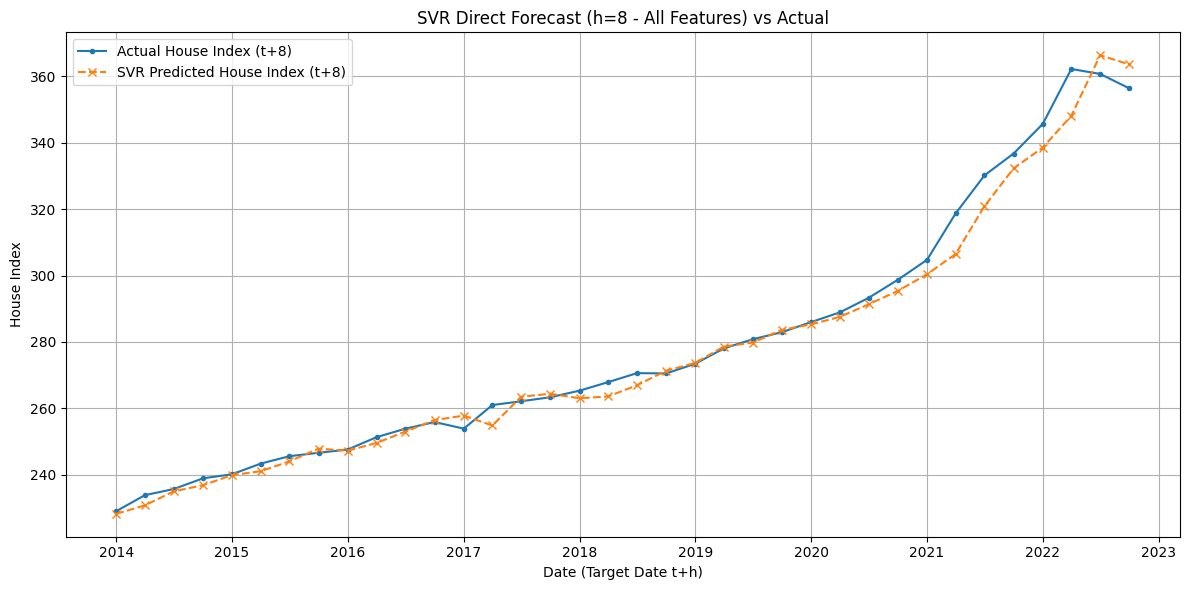


--- Completed Run for Horizon h = 8 (All Features) ---


In [13]:
# --- Code Template for Direct Multi-Step SVR Evaluation (Single Horizon - ALL FEATURES) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta # More robust for month/quarter steps

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
# ************************************************************
# ****** CHANGE THIS VALUE FOR EACH RUN (1 through 8) ******
forecast_horizon = 8  # Example: Set to 1 for the first run
# ************************************************************

# ****** USING THE FILE WITH ALL FEATURES ******
data_file_all_features = 'DC_Data_For_Lasso.csv'
# *********************************************

master_file = 'DC_Master_Data_Filled.csv'
n_test = 36 # Number of forecasts to generate in walk-forward

print(f"--- Running Direct SVR Evaluation (All Features) for Horizon h = {forecast_horizon} ---")

# --- Load Data ---
try:
    # Load the dataset with ALL prepared features
    df_svr_input_raw = pd.read_csv(data_file_all_features, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print(f"Data loaded successfully from {data_file_all_features}.")
    print(f"Input data shape: {df_svr_input_raw.shape}") # Should have many columns now

    # --- Prepare Data for Direct Forecasting at Horizon h ---
    target_col_diff = df_svr_input_raw.columns[0] # Still 'Target_House_Index_diff1'

    # Features X are all columns except the target
    X_orig = df_svr_input_raw.drop(columns=[target_col_diff])
    print(f"Number of features being used: {X_orig.shape[1]}")

    # Target y is the differenced value h steps *ahead* (target at t+h)
    y_diff_h = df_svr_input_raw[target_col_diff].shift(-forecast_horizon)

    # Combine features and target, align them by index (time t)
    df_aligned = X_orig.copy()
    df_aligned['Target_h'] = y_diff_h

    # Drop rows with NaN target (the last h rows where target couldn't be shifted back)
    df_aligned.dropna(subset=['Target_h'], inplace=True)

    X = df_aligned.drop(columns=['Target_h'])
    y = df_aligned['Target_h'] # This is the differenced target at t+h

    print(f"Aligned data shape for h={forecast_horizon}: {df_aligned.shape}")

    if len(df_aligned) < n_test * 2:
         raise ValueError(f"Not enough data after alignment for horizon {forecast_horizon} to support n_test={n_test}.")

    # --- Split Data ---
    X_train_full, X_test = X[:-n_test], X[-n_test:]
    y_train_full, y_test = y[:-n_test], y[-n_test:] # y_test contains target values at t+h

    print(f"Train set size: {len(X_train_full)}")
    print(f"Test set size: {len(X_test)}")


    # --- Walk-Forward Validation for Horizon h ---
    history_X = X_train_full.copy()
    history_y = y_train_full.copy() # Target values for t+h relative to history_X time t
    predictions_diff_h = [] # Store predictions for y(t+h) on the differenced scale

    scaler_X = StandardScaler()
    scaler_y = StandardScaler() # Scale target

    print("\nStarting walk-forward validation...")
    for t in range(len(X_test)):
        # Scale data (fit on history, transform history and current test point)
        X_train_scaled = scaler_X.fit_transform(history_X)
        y_train_scaled = scaler_y.fit_transform(history_y.values.reshape(-1, 1)).ravel()

        # Configure and fit SVR model for this specific horizon h
        model = SVR() # Using default parameters
        model.fit(X_train_scaled, y_train_scaled)

        # Prepare the current test input point (features at time t)
        current_X_test = X_test.iloc[[t]]
        current_X_test_scaled = scaler_X.transform(current_X_test)

        # Predict the scaled target value h steps ahead
        y_pred_scaled = model.predict(current_X_test_scaled)

        # Inverse transform the prediction to the differenced scale
        y_pred_diff = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]
        predictions_diff_h.append(y_pred_diff)

        # Update history with data corresponding to time t
        history_X = pd.concat([history_X, current_X_test], ignore_index=False)
        history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
             print(f"Processed {t + 1}/{len(X_test)} steps...")

    print("Walk-forward validation complete.")

    # --- Inverse Differencing for Direct Strategy ---
    predictions_original_scale = []
    actual_original_scale = []
    actual_prev_original_scale = [] # Values at t+h-1 for DA calc

    test_indices = y_test.index # These are the target dates (t+h)

    for i in range(len(predictions_diff_h)):
        pred_diff = predictions_diff_h[i] # Predicted change HI(t+h) - HI(t+h-1)
        target_date = test_indices[i] # Date for which prediction is made (t+h)
        prev_date = target_date - relativedelta(months=3) # Date t+h-1

        try:
            actual_target_value = df_master.loc[target_date, 'House_Index']
            actual_prev_value = df_master.loc[prev_date, 'House_Index']
            predicted_original = actual_prev_value + pred_diff

            predictions_original_scale.append(predicted_original)
            actual_original_scale.append(actual_target_value)
            actual_prev_original_scale.append(actual_prev_value)

        except KeyError as e:
            print(f"Warning: Date not found in master data for inverse differencing: {e}. Skipping point {target_date}.")
            # If we skip, metrics might be calculated on fewer points. Consider appending NaN and handling later.


    # --- Calculate Metrics for Horizon h ---
    if not predictions_original_scale:
         print("\nNo valid predictions generated. Cannot calculate metrics.")
    else:
        # Ensure lengths match if points were skipped
        min_len = min(len(actual_original_scale), len(predictions_original_scale), len(actual_prev_original_scale))
        actual_original_scale = actual_original_scale[:min_len]
        predictions_original_scale = predictions_original_scale[:min_len]
        actual_prev_original_scale = actual_prev_original_scale[:min_len]

        if min_len < len(predictions_diff_h):
             print(f"Warning: Metrics calculated on {min_len} points due to missing dates in master file during inverse differencing.")

        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        print("\n--- SVR Performance Metrics (Direct Strategy - All Features) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        # --- Optional: Plotting for Horizon h ---
        results_df = pd.DataFrame({
            'Actual_Original': actual_original_scale,
            'Predicted_Original': predictions_original_scale
        }, index=test_indices[:min_len]) # Use index corresponding to actual data points used

        plt.figure(figsize=(12, 6))
        plt.plot(results_df.index, results_df['Actual_Original'], label=f'Actual House Index (t+{forecast_horizon})', marker='.')
        plt.plot(results_df.index, results_df['Predicted_Original'], label=f'SVR Predicted House Index (t+{forecast_horizon})', marker='x', linestyle='--')
        plt.title(f'SVR Direct Forecast (h={forecast_horizon} - All Features) vs Actual')
        plt.xlabel('Date (Target Date t+h)')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names in CSV files or DataFrames. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except IndexError as e:
    print(f"Error: Index error, possibly during data alignment or access. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Run for Horizon h = {forecast_horizon} (All Features) ---")

--- Running Direct LGBM Evaluation (All Features) for Horizons: [1, 4, 8] ---
Data loaded successfully from DC_Data_For_Lasso.csv.
Number of features being used: 34

===== Processing Horizon h = 1 =====
Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- LGBM Performance Metrics (Direct Strategy - All Features) ---
Forecast Horizon (h): 1
MAE:  3.762
RMSE: 4.577
MAPE: 1.215%
DA:   63.889%

===== Processing Horizon h = 4 =====
Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- LGBM Performance Metrics (Direct Strategy - All Features) ---
Forecast Horizon (h): 4
MAE:  4.298
RMSE: 5.931
MAPE: 1.391%
DA:   47.222%

===== Processing Horizon h = 8 =====
Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 3

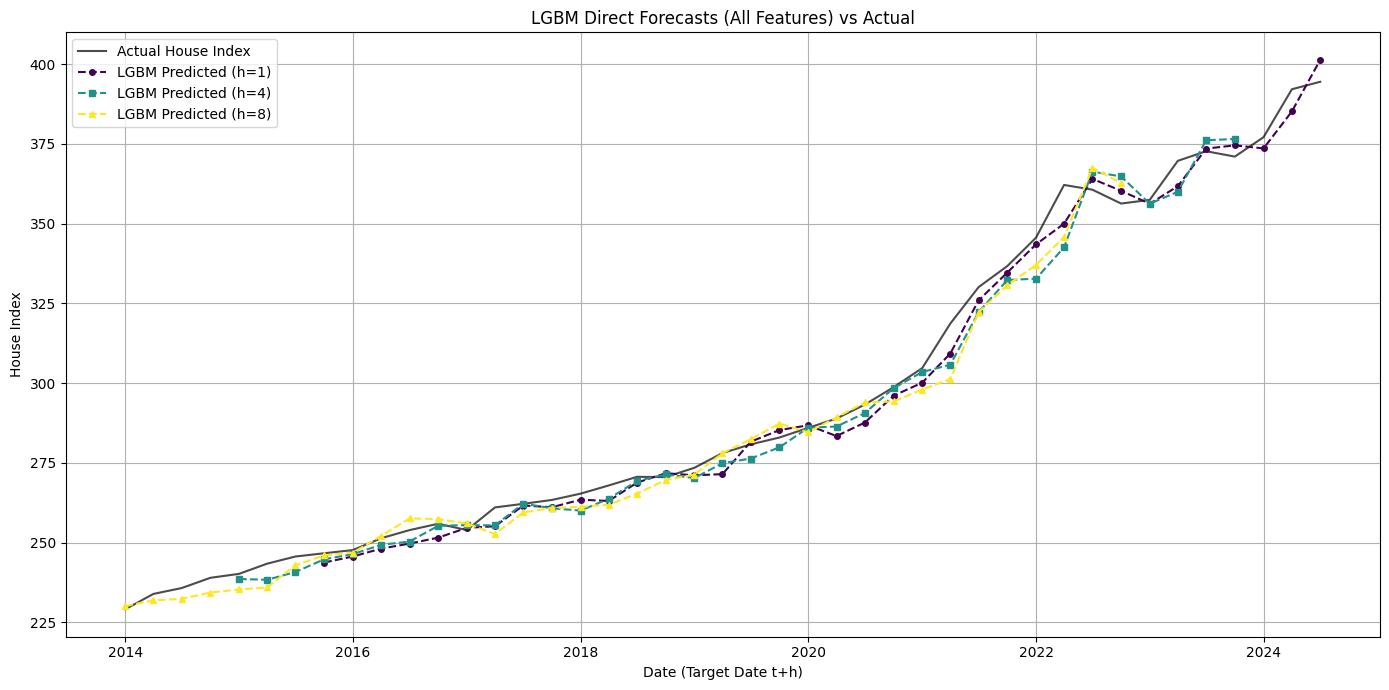


--- Completed LGBM Runs ---


In [14]:
# --- Code for Direct Multi-Step LGBM Evaluation (Multiple Horizons) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
# Use LightGBM instead of SVR
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy - Same as before) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
horizons_to_run = [1, 4, 8] # Run for h=1, h=4, h=8
data_file_all_features = 'DC_Data_For_Lasso.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36 # Number of forecasts to generate in walk-forward

results_all_horizons = {} # Store results

print(f"--- Running Direct LGBM Evaluation (All Features) for Horizons: {horizons_to_run} ---")

# --- Load Data ---
try:
    df_svr_input_raw = pd.read_csv(data_file_all_features, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print(f"Data loaded successfully from {data_file_all_features}.")

    target_col_diff = df_svr_input_raw.columns[0]
    X_orig_full = df_svr_input_raw.drop(columns=[target_col_diff])
    print(f"Number of features being used: {X_orig_full.shape[1]}")

    # --- Loop through specified horizons ---
    for forecast_horizon in horizons_to_run:
        print(f"\n===== Processing Horizon h = {forecast_horizon} =====")

        # Prepare Data for Direct Forecasting at Horizon h
        y_diff_h = df_svr_input_raw[target_col_diff].shift(-forecast_horizon)
        df_aligned = X_orig_full.copy()
        df_aligned['Target_h'] = y_diff_h
        df_aligned.dropna(subset=['Target_h'], inplace=True)
        X = df_aligned.drop(columns=['Target_h'])
        y = df_aligned['Target_h']

        if len(df_aligned) < n_test * 2:
            print(f"Warning: Not enough data after alignment for horizon {forecast_horizon}. Skipping.")
            continue

        # Split Data
        X_train_full, X_test = X[:-n_test], X[-n_test:]
        y_train_full, y_test = y[:-n_test], y[-n_test:]

        # --- Walk-Forward Validation for Horizon h ---
        history_X = X_train_full.copy()
        history_y = y_train_full.copy()
        predictions_diff_h = []

        # Note: Scaling features is often recommended for SVR/NNs, but less critical
        # for tree-based models like LightGBM. We can skip scaling X for simplicity here.
        # Target 'y' is not scaled either for LGBM regression by default.

        print("Starting walk-forward validation...")
        for t in range(len(X_test)):
            # Prepare data for current step (no scaling needed for X, y for default LGBM)
            X_train_step = history_X
            y_train_step = history_y

            # Configure and fit LightGBM Regressor model for horizon h
            # Using default parameters for LGBM
            model = lgb.LGBMRegressor(random_state=42, verbosity=-1) # Suppress verbosity
            model.fit(X_train_step, y_train_step)

            # Prepare the current test input point
            current_X_test = X_test.iloc[[t]]

            # Predict the target value h steps ahead (directly predicts the differenced value)
            y_pred_diff = model.predict(current_X_test)[0] # Predict returns array
            predictions_diff_h.append(y_pred_diff)

            # Update history
            history_X = pd.concat([history_X, current_X_test], ignore_index=False)
            history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

            # Minimal progress print
            if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
                 print(f"Processed {t + 1}/{len(X_test)} steps...")

        print("Walk-forward validation complete.")

        # --- Inverse Differencing ---
        predictions_original_scale = []
        actual_original_scale = []
        actual_prev_original_scale = []
        test_indices = y_test.index # Target dates (t+h)
        valid_indices = [] # Keep track of indices where calculation worked

        for i in range(len(predictions_diff_h)):
            pred_diff = predictions_diff_h[i]
            target_date = test_indices[i]
            prev_date = target_date - relativedelta(months=3)

            try:
                actual_target_value = df_master.loc[target_date, 'House_Index']
                actual_prev_value = df_master.loc[prev_date, 'House_Index']
                predicted_original = actual_prev_value + pred_diff

                predictions_original_scale.append(predicted_original)
                actual_original_scale.append(actual_target_value)
                actual_prev_original_scale.append(actual_prev_value)
                valid_indices.append(target_date) # Store index if successful

            except KeyError:
                print(f"Warning: Date not found in master data for inverse differencing: {target_date} or {prev_date}. Skipping point.")

        # --- Calculate Metrics for Horizon h ---
        if not predictions_original_scale:
            print("No valid predictions generated. Cannot calculate metrics.")
            results_all_horizons[forecast_horizon] = None
            continue # Skip to next horizon

        min_len = len(predictions_original_scale)
        if min_len < len(predictions_diff_h):
            print(f"Warning: Metrics calculated on {min_len} points due to missing dates.")

        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        metrics = {
            'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'DA': da
        }
        results_all_horizons[forecast_horizon] = {
            'metrics': metrics,
            'predictions_df': pd.DataFrame({
                'Actual_Original': actual_original_scale,
                'Predicted_Original': predictions_original_scale
            }, index=pd.to_datetime(valid_indices)) # Use validated indices
        }

        print("\n--- LGBM Performance Metrics (Direct Strategy - All Features) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")


    # --- Plotting Combined Results ---
    print("\n--- Plotting Results for All Processed Horizons ---")
    plt.figure(figsize=(14, 7))
    # Find overall min/max dates for plot limits if needed
    # Plot actual data from master file for context (over the test period range)
    min_plot_date = min(df.index.min() for df in [r['predictions_df'] for r in results_all_horizons.values() if r] if not df.empty) if any(results_all_horizons.values()) else None
    max_plot_date = max(df.index.max() for df in [r['predictions_df'] for r in results_all_horizons.values() if r] if not df.empty) if any(results_all_horizons.values()) else None

    if min_plot_date and max_plot_date:
        actual_data_subset = df_master[(df_master.index >= min_plot_date) & (df_master.index <= max_plot_date)]
        plt.plot(actual_data_subset.index, actual_data_subset['House_Index'], label='Actual House Index', color='black', linewidth=1.5, alpha=0.7)
    else:
         print("Could not determine date range for plotting actuals.")


    colors = plt.cm.viridis(np.linspace(0, 1, len(horizons_to_run)))
    markers = ['o', 's', '^', 'd', 'v', '<', '>', '*']

    for i, h in enumerate(horizons_to_run):
        if results_all_horizons.get(h):
            results_df = results_all_horizons[h]['predictions_df']
            if not results_df.empty:
                 plt.plot(results_df.index, results_df['Predicted_Original'],
                          label=f'LGBM Predicted (h={h})', color=colors[i],
                          marker=markers[i % len(markers)], linestyle='--', markersize=4)

    plt.title('LGBM Direct Forecasts (All Features) vs Actual')
    plt.xlabel('Date (Target Date t+h)')
    plt.ylabel('House Index')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed LGBM Runs ---")

--- Running Direct LGBM Evaluation (Predicting LEVEL, All Features + Trend) for Horizons: [1, 4, 8] ---
Feature data loaded successfully from DC_Data_For_Lasso.csv.
Master data loaded successfully from DC_Master_Data_Filled.csv.
Number of features being used (incl. time trend): 35

===== Processing Horizon h = 1 =====
Aligned data shape for h=1: 132 rows
Train set size: 96
Test set size: 36
Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- LGBM Performance Metrics (Direct Strategy - Predicting LEVEL) ---
Forecast Horizon (h): 1
MAE:  26.318
RMSE: 33.971
MAPE: 7.767%
DA:   30.556%

===== Processing Horizon h = 4 =====
Aligned data shape for h=4: 129 rows
Train set size: 93
Test set size: 36
Starting walk-forward validation...
Processed 10/36 steps...
Processed 20/36 steps...
Processed 30/36 steps...
Processed 36/36 steps...
Walk-forward validation complete.

--- L

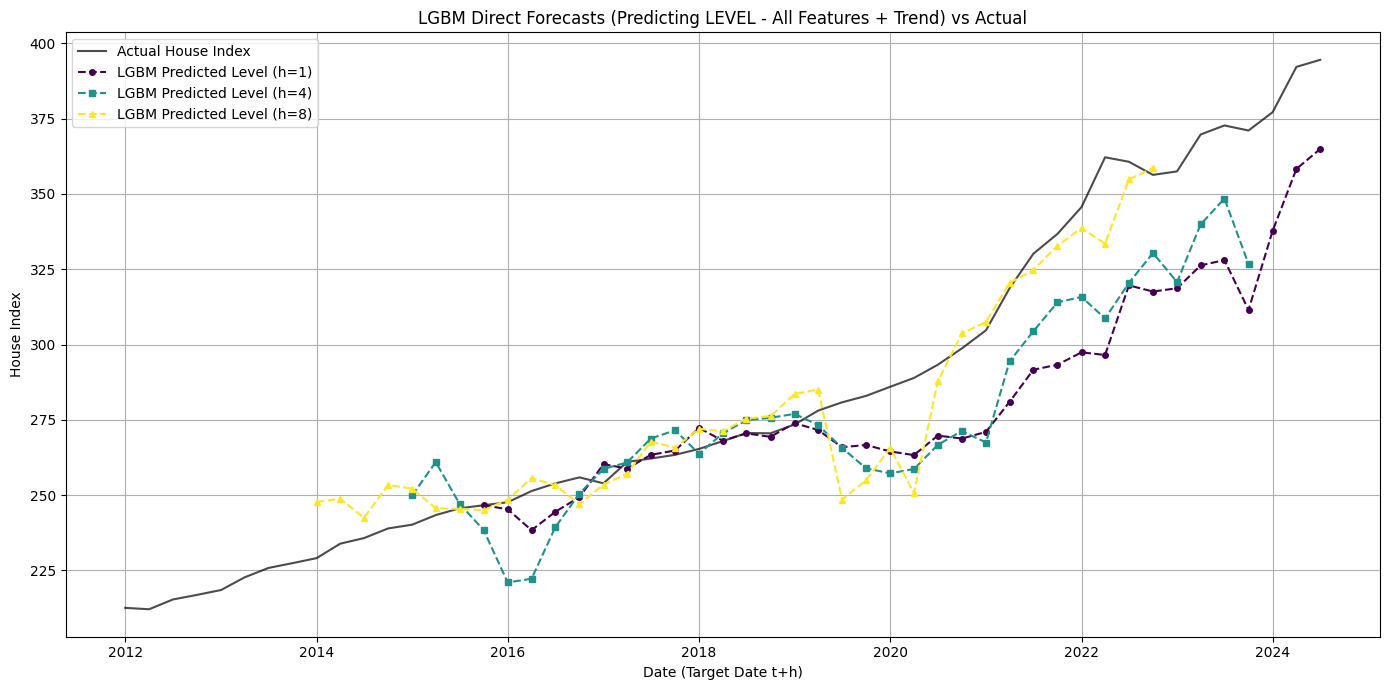


--- Completed LGBM Runs (Predicting Level) ---


In [15]:
# --- Code for Direct Multi-Step LGBM Evaluation (Predicting LEVEL) ---

import pandas as pd
import numpy as np
# Use LightGBM
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta

warnings.filterwarnings('ignore')

# --- Helper Functions (MAPE, Directional Accuracy - Same as before) ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# --- Configuration ---
horizons_to_run = [1, 4, 8] # Run for h=1, h=4, h=8
# Use the file with all STATIONARY features
feature_file = 'DC_Data_For_Lasso.csv'
master_file = 'DC_Master_Data_Filled.csv' # Needed for the LEVEL target
n_test = 36 # Number of forecasts to generate in walk-forward

results_all_horizons = {} # Store results

print(f"--- Running Direct LGBM Evaluation (Predicting LEVEL, All Features + Trend) for Horizons: {horizons_to_run} ---")

# --- Load Data ---
try:
    df_features_raw = pd.read_csv(feature_file, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print(f"Feature data loaded successfully from {feature_file}.")
    print(f"Master data loaded successfully from {master_file}.")

    # Prepare Features X: Use all columns from feature_file EXCEPT the target_diff
    target_col_diff = df_features_raw.columns[0] # Original differenced target
    X_orig = df_features_raw.drop(columns=[target_col_diff])

    # Add a time trend feature
    X_orig['time_trend'] = np.arange(len(X_orig))
    print(f"Number of features being used (incl. time trend): {X_orig.shape[1]}")

    # Prepare Target y: Use the actual LEVEL 'House_Index' from master file
    y_level_full = df_master['House_Index']

    # --- Loop through specified horizons ---
    for forecast_horizon in horizons_to_run:
        print(f"\n===== Processing Horizon h = {forecast_horizon} =====")

        # Prepare Data for Direct Forecasting at Horizon h (Predicting Level)
        # Target y is the level h steps *ahead* (target at t+h)
        y_level_h = y_level_full.shift(-forecast_horizon)

        # Align features X(t) with target y(t+h)
        df_aligned = X_orig.copy()
        df_aligned['Target_Level_h'] = y_level_h

        # Drop rows with NaN target (last h rows) AND ensure indices match features
        df_aligned.dropna(subset=['Target_Level_h'], inplace=True)

        # Ensure only dates present in BOTH X_orig and the shifted target are kept
        common_index = X_orig.index.intersection(df_aligned.index)
        X = X_orig.loc[common_index]
        y = df_aligned.loc[common_index, 'Target_Level_h'] # This is the LEVEL target at t+h

        print(f"Aligned data shape for h={forecast_horizon}: {X.shape[0]} rows")

        if len(X) < n_test * 2:
            print(f"Warning: Not enough data after alignment for horizon {forecast_horizon}. Skipping.")
            continue

        # Split Data
        X_train_full, X_test = X[:-n_test], X[-n_test:]
        y_train_full, y_test = y[:-n_test], y[-n_test:] # y_test contains LEVEL target values at t+h

        print(f"Train set size: {len(X_train_full)}")
        print(f"Test set size: {len(X_test)}")

        # --- Walk-Forward Validation for Horizon h ---
        history_X = X_train_full.copy()
        history_y = y_train_full.copy() # Level target values for t+h
        predictions_level_h = [] # Store predictions for y(t+h) on the LEVEL scale

        print("Starting walk-forward validation...")
        for t in range(len(X_test)):
            X_train_step = history_X
            y_train_step = history_y

            # Configure and fit LightGBM Regressor model for horizon h
            model = lgb.LGBMRegressor(random_state=42, verbosity=-1) # Suppress verbosity
            model.fit(X_train_step, y_train_step)

            # Prepare the current test input point
            current_X_test = X_test.iloc[[t]]

            # Predict the target LEVEL value h steps ahead
            y_pred_level = model.predict(current_X_test)[0]
            predictions_level_h.append(y_pred_level)

            # Update history
            history_X = pd.concat([history_X, current_X_test], ignore_index=False)
            history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False) # Add level target

            if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
                 print(f"Processed {t + 1}/{len(X_test)} steps...")

        print("Walk-forward validation complete.")

        # --- Prepare Data for Metrics Calculation ---
        # Predictions are already on the original level scale
        actual_original_scale = y_test.values # The actual levels at t+h
        predictions_original_scale = np.array(predictions_level_h)

        # Get previous actual values (at t+h-1) for DA calculation
        actual_prev_original_scale = []
        test_indices = y_test.index # Target dates (t+h)
        valid_indices_metric = [] # Indices where all data is available for metrics

        for i in range(len(test_indices)):
            target_date = test_indices[i]
            prev_date = target_date - relativedelta(months=3) # Date t+h-1
            try:
                # We only need the previous value for DA calc
                actual_prev_value = df_master.loc[prev_date, 'House_Index']
                actual_prev_original_scale.append(actual_prev_value)
                valid_indices_metric.append(target_date) # This index has a valid previous value
            except KeyError:
                print(f"Warning: Date {prev_date} not found in master data for DA calculation. Corresponding prediction for {target_date} will be excluded from DA.")
                # Need to align actuals and predictions based on valid_indices_metric later if points are skipped

        # Align all arrays based on valid_indices_metric for consistent metric calculation
        # Find indices in y_test corresponding to valid_indices_metric
        valid_mask = y_test.index.isin(valid_indices_metric)
        actual_original_scale_metric = y_test[valid_mask].values
        predictions_original_scale_metric = predictions_original_scale[valid_mask] # Assumes predictions align one-to-one with y_test initially
        actual_prev_original_scale_metric = np.array(actual_prev_original_scale) # Already aligned with valid_indices_metric

        # --- Calculate Metrics for Horizon h ---
        if len(actual_original_scale_metric) == 0:
            print("\nNo valid points for metric calculation. Skipping metrics.")
            results_all_horizons[forecast_horizon] = None
            continue

        min_len = len(actual_original_scale_metric)
        if min_len < len(predictions_level_h):
             print(f"Warning: Metrics calculated on {min_len} points due to missing dates for DA calculation.")

        mae = mean_absolute_error(actual_original_scale_metric, predictions_original_scale_metric)
        rmse = np.sqrt(mean_squared_error(actual_original_scale_metric, predictions_original_scale_metric))
        mape = mean_absolute_percentage_error(actual_original_scale_metric, predictions_original_scale_metric)
        da = directional_accuracy(actual_original_scale_metric, predictions_original_scale_metric, actual_prev_original_scale_metric)

        metrics = { 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'DA': da }
        results_all_horizons[forecast_horizon] = {
            'metrics': metrics,
            # Store predictions aligned with y_test index for plotting
            'predictions_df': pd.DataFrame({
                 # Use y_test directly for actuals as it's already aligned with predictions
                'Actual_Original': y_test.values,
                'Predicted_Original': predictions_original_scale
            }, index=y_test.index)
        }

        print("\n--- LGBM Performance Metrics (Direct Strategy - Predicting LEVEL) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%") # Note DA calculated on potentially fewer points


    # --- Plotting Combined Results ---
    print("\n--- Plotting Results for All Processed Horizons ---")
    plt.figure(figsize=(14, 7))

    min_plot_date = min((r['predictions_df'].index.min() for r in results_all_horizons.values() if r and not r['predictions_df'].empty), default=None)
    max_plot_date = max((r['predictions_df'].index.max() for r in results_all_horizons.values() if r and not r['predictions_df'].empty), default=None)

    if min_plot_date and max_plot_date:
        actual_data_subset = df_master[(df_master.index >= min_plot_date - relativedelta(years=2)) & (df_master.index <= max_plot_date)] # Show some history
        plt.plot(actual_data_subset.index, actual_data_subset['House_Index'], label='Actual House Index', color='black', linewidth=1.5, alpha=0.7)
    else:
         print("Could not determine date range for plotting actuals.")


    colors = plt.cm.viridis(np.linspace(0, 1, len(horizons_to_run)))
    markers = ['o', 's', '^', 'd', 'v', '<', '>', '*']

    for i, h in enumerate(horizons_to_run):
        if results_all_horizons.get(h):
            results_df = results_all_horizons[h]['predictions_df']
            if not results_df.empty:
                 # Plot only predictions within the calculated date range if possible
                 plot_data = results_df[(results_df.index >= min_plot_date) & (results_df.index <= max_plot_date)] if min_plot_date else results_df
                 plt.plot(plot_data.index, plot_data['Predicted_Original'],
                          label=f'LGBM Predicted Level (h={h})', color=colors[i],
                          marker=markers[i % len(markers)], linestyle='--', markersize=4)

    plt.title('LGBM Direct Forecasts (Predicting LEVEL - All Features + Trend) vs Actual')
    plt.xlabel('Date (Target Date t+h)')
    plt.ylabel('House Index')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed LGBM Runs (Predicting Level) ---")

--- Running TUNED Direct LGBM Evaluation (Predicting LEVEL) for Horizons: [1, 4, 8] ---
Feature data loaded successfully from DC_Data_For_Lasso.csv.
Master data loaded successfully from DC_Master_Data_Filled.csv.

===== Processing Horizon h = 1 =====
Tuning set size: 96
Test set size: 36
Starting GridSearchCV for h=1... (This may take time)
GridSearchCV finished in 2.95 seconds.
Best parameters found for h=1: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 15, 'reg_alpha': 0.0, 'reg_lambda': 0.1}
Starting walk-forward validation with best parameters...
Walk-forward validation complete.

--- TUNED LGBM Performance Metrics (Direct Strategy - Predicting LEVEL) ---
Forecast Horizon (h): 1
MAE:  23.958
RMSE: 30.910
MAPE: 7.099%
DA:   36.111%
Total time for horizon 1: 3.49 seconds.

===== Processing Horizon h = 4 =====
Tuning set size: 93
Test set size: 36
Starting GridSearchCV for h=4... (This may take time)
GridSearchCV finished in 1.03 seconds.
Best parameters found for h=4: {'l

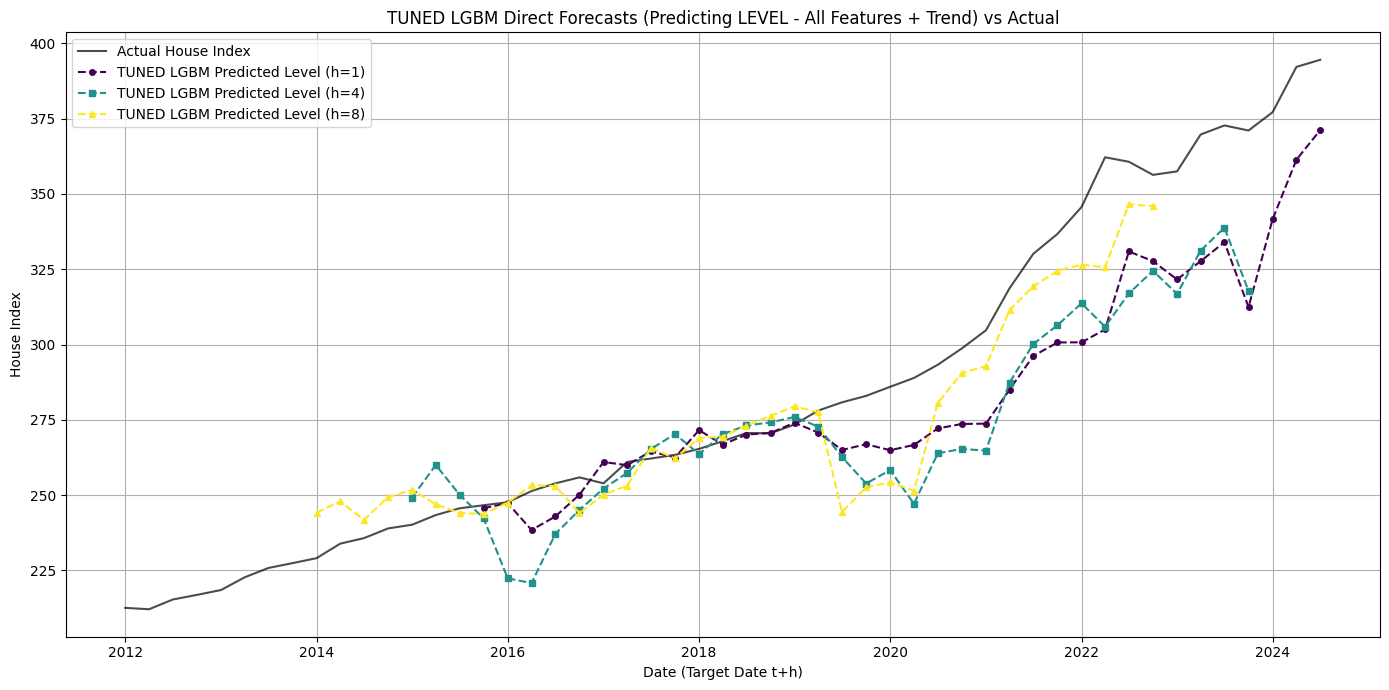


--- Completed TUNED LGBM Runs (Predicting Level) ---

Best parameters found per horizon:
{1: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 15, 'reg_alpha': 0.0, 'reg_lambda': 0.1}, 4: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 15, 'reg_alpha': 0.0, 'reg_lambda': 0.1}, 8: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 15, 'reg_alpha': 0.1, 'reg_lambda': 0.1}}


In [17]:
# --- Code for TUNED Direct Multi-Step LGBM Evaluation (Predicting LEVEL) ---

import pandas as pd
import numpy as np
# Use LightGBM
import lightgbm as lgb
# For Tuning
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta
import time # To time operations

warnings.filterwarnings('ignore')

# --- Helper Functions ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# Define RMSE scorer for GridSearchCV
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False) # We want to minimize RMSE

# --- Configuration ---
horizons_to_run = [1, 4, 8]
feature_file = 'DC_Data_For_Lasso.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36
# TimeSeriesSplit for cross-validation during tuning
n_splits_cv = 3 # Number of splits for TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=n_splits_cv)

# Hyperparameter Grid for LightGBM (reduced for reasonable speed)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [15, 31], # Relatively small values
    # 'max_depth': [-1, 5], # Default -1 means no limit
    'reg_alpha': [0.0, 0.1], # L1 regularization
    'reg_lambda': [0.0, 0.1] # L2 regularization
}

results_all_horizons = {}
best_params_all_horizons = {}

print(f"--- Running TUNED Direct LGBM Evaluation (Predicting LEVEL) for Horizons: {horizons_to_run} ---")

# --- Load Data ---
try:
    df_features_raw = pd.read_csv(feature_file, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print(f"Feature data loaded successfully from {feature_file}.")
    print(f"Master data loaded successfully from {master_file}.")

    target_col_diff = df_features_raw.columns[0]
    X_orig = df_features_raw.drop(columns=[target_col_diff])
    X_orig['time_trend'] = np.arange(len(X_orig))
    y_level_full = df_master['House_Index']

    # --- Loop through specified horizons ---
    for forecast_horizon in horizons_to_run:
        start_time_h = time.time()
        print(f"\n===== Processing Horizon h = {forecast_horizon} =====")

        # Prepare Data for horizon h
        y_level_h = y_level_full.shift(-forecast_horizon)
        df_aligned = X_orig.copy()
        df_aligned['Target_Level_h'] = y_level_h
        df_aligned.dropna(subset=['Target_Level_h'], inplace=True)
        common_index = X_orig.index.intersection(df_aligned.index)
        X = X_orig.loc[common_index]
        y = df_aligned.loc[common_index, 'Target_Level_h'] # LEVEL target

        if len(X) < n_test + n_splits_cv + 1: # Need enough data for split + CV splits
            print(f"Warning: Not enough data ({len(X)}) for horizon {forecast_horizon} to perform {n_splits_cv}-split CV and test split of size {n_test}. Skipping.")
            continue

        # Split Data (split off test set *before* tuning)
        X_train_tune, X_test = X[:-n_test], X[-n_test:]
        y_train_tune, y_test = y[:-n_test], y[-n_test:] # y_test contains LEVEL targets

        print(f"Tuning set size: {len(X_train_tune)}")
        print(f"Test set size: {len(X_test)}")

        # --- Hyperparameter Tuning using GridSearchCV ---
        print(f"Starting GridSearchCV for h={forecast_horizon}... (This may take time)")
        start_tune_time = time.time()

        lgbm = lgb.LGBMRegressor(random_state=42, verbosity=-1)
        grid_search = GridSearchCV(estimator=lgbm,
                                   param_grid=param_grid,
                                   scoring=rmse_scorer, # Use negative RMSE because higher score is better
                                   cv=tscv,
                                   n_jobs=-1, # Use all available CPU cores
                                   verbose=0) # Set to 1 or 2 for more messages
        grid_search.fit(X_train_tune, y_train_tune)

        tune_time = time.time() - start_tune_time
        print(f"GridSearchCV finished in {tune_time:.2f} seconds.")
        print(f"Best parameters found for h={forecast_horizon}: {grid_search.best_params_}")
        best_params = grid_search.best_params_
        best_params_all_horizons[forecast_horizon] = best_params

        # --- Walk-Forward Validation using Best Parameters ---
        print("Starting walk-forward validation with best parameters...")
        # Use the full training set (including the part used for tuning) for the initial history
        # Although conceptually slightly overlapping, it's common practice to use all data before the test set starts
        X_train_full, _ = X[:-n_test], X[-n_test:] # Re-define for clarity
        y_train_full, _ = y[:-n_test], y[-n_test:]

        history_X = X_train_full.copy()
        history_y = y_train_full.copy()
        predictions_level_h = []

        for t in range(len(X_test)):
            X_train_step = history_X
            y_train_step = history_y

            # Instantiate LGBM with the BEST parameters found
            model = lgb.LGBMRegressor(**best_params, random_state=42, verbosity=-1)
            model.fit(X_train_step, y_train_step)

            current_X_test = X_test.iloc[[t]]
            y_pred_level = model.predict(current_X_test)[0]
            predictions_level_h.append(y_pred_level)

            history_X = pd.concat([history_X, current_X_test], ignore_index=False)
            history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

            # Minimal progress print
            # if (t + 1) % 10 == 0 or (t + 1) == len(X_test):
            #      print(f"Processed {t + 1}/{len(X_test)} walk-forward steps...")

        print("Walk-forward validation complete.")

        # --- Prepare Data for Metrics Calculation ---
        actual_original_scale = y_test.values
        predictions_original_scale = np.array(predictions_level_h)
        actual_prev_original_scale = []
        test_indices = y_test.index
        valid_indices_metric = []

        for i in range(len(test_indices)):
            target_date = test_indices[i]
            prev_date = target_date - relativedelta(months=3)
            try:
                actual_prev_value = df_master.loc[prev_date, 'House_Index']
                actual_prev_original_scale.append(actual_prev_value)
                valid_indices_metric.append(target_date)
            except KeyError:
                 print(f"Warning: Date {prev_date} not found in master data for DA calculation for target {target_date}. Point excluded from DA.")

        valid_mask = y_test.index.isin(valid_indices_metric)
        actual_original_scale_metric = y_test[valid_mask].values
        predictions_original_scale_metric = predictions_original_scale[valid_mask]
        actual_prev_original_scale_metric = np.array(actual_prev_original_scale)

        # --- Calculate Metrics for Horizon h ---
        if len(actual_original_scale_metric) == 0:
            print("\nNo valid points for metric calculation. Skipping metrics.")
            results_all_horizons[forecast_horizon] = None
            continue

        min_len = len(actual_original_scale_metric)
        if min_len < len(predictions_level_h):
             print(f"Warning: Metrics calculated on {min_len} points due to missing dates for DA calculation.")

        mae = mean_absolute_error(actual_original_scale_metric, predictions_original_scale_metric)
        rmse = np.sqrt(mean_squared_error(actual_original_scale_metric, predictions_original_scale_metric))
        mape = mean_absolute_percentage_error(actual_original_scale_metric, predictions_original_scale_metric)
        da = directional_accuracy(actual_original_scale_metric, predictions_original_scale_metric, actual_prev_original_scale_metric)

        metrics = { 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'DA': da }
        results_all_horizons[forecast_horizon] = {
            'metrics': metrics,
            'predictions_df': pd.DataFrame({
                'Actual_Original': y_test.values,
                'Predicted_Original': predictions_original_scale
            }, index=y_test.index)
        }

        print(f"\n--- TUNED LGBM Performance Metrics (Direct Strategy - Predicting LEVEL) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        end_time_h = time.time()
        print(f"Total time for horizon {forecast_horizon}: {end_time_h - start_time_h:.2f} seconds.")


    # --- Plotting Combined Results ---
    print("\n--- Plotting Results for All Processed Horizons ---")
    plt.figure(figsize=(14, 7))

    min_plot_date = min((r['predictions_df'].index.min() for r in results_all_horizons.values() if r and not r['predictions_df'].empty), default=None)
    max_plot_date = max((r['predictions_df'].index.max() for r in results_all_horizons.values() if r and not r['predictions_df'].empty), default=None)

    if min_plot_date and max_plot_date:
        actual_data_subset = df_master[(df_master.index >= min_plot_date - relativedelta(years=2)) & (df_master.index <= max_plot_date)] # Show some history
        plt.plot(actual_data_subset.index, actual_data_subset['House_Index'], label='Actual House Index', color='black', linewidth=1.5, alpha=0.7)
    else:
         print("Could not determine date range for plotting actuals.")

    colors = plt.cm.viridis(np.linspace(0, 1, len(horizons_to_run)))
    markers = ['o', 's', '^', 'd', 'v', '<', '>', '*']

    for i, h in enumerate(horizons_to_run):
        if results_all_horizons.get(h):
            results_df = results_all_horizons[h]['predictions_df']
            if not results_df.empty:
                 plot_data = results_df[(results_df.index >= min_plot_date) & (results_df.index <= max_plot_date)] if min_plot_date else results_df
                 plt.plot(plot_data.index, plot_data['Predicted_Original'],
                          label=f'TUNED LGBM Predicted Level (h={h})', color=colors[i],
                          marker=markers[i % len(markers)], linestyle='--', markersize=4)

    plt.title('TUNED LGBM Direct Forecasts (Predicting LEVEL - All Features + Trend) vs Actual')
    plt.xlabel('Date (Target Date t+h)')
    plt.ylabel('House Index')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed TUNED LGBM Runs (Predicting Level) ---")
print("\nBest parameters found per horizon:")
print(best_params_all_horizons)

--- Running EXTENSIVELY TUNED Direct LGBM Evaluation (Predicting LEVEL) for Horizons: [1, 4, 8] ---
Using RandomizedSearchCV with n_iter = 1500
Feature data loaded successfully from DC_Data_For_Lasso.csv.
Master data loaded successfully from DC_Master_Data_Filled.csv.

===== Processing Horizon h = 1 =====
Tuning set size: 96
Test set size: 36
Starting RandomizedSearchCV for h=1 (n_iter=1500)... (This will take time)
RandomizedSearchCV finished in 91.55 seconds.
Best parameters found for h=1: {'colsample_bytree': 0.6427679457519285, 'learning_rate': 0.06047543235655418, 'max_depth': 7, 'n_estimators': 440, 'num_leaves': 24, 'reg_alpha': 0.8386972402950503, 'reg_lambda': 0.5821807361446398, 'subsample': 0.6995265261352889}
Starting walk-forward validation with best parameters...
Walk-forward validation complete.

--- EXTENSIVELY TUNED LGBM Performance Metrics (Direct Strategy - Predicting LEVEL) ---
Forecast Horizon (h): 1
MAE:  29.630
RMSE: 36.683
MAPE: 8.948%
DA:   25.000%
Total time f

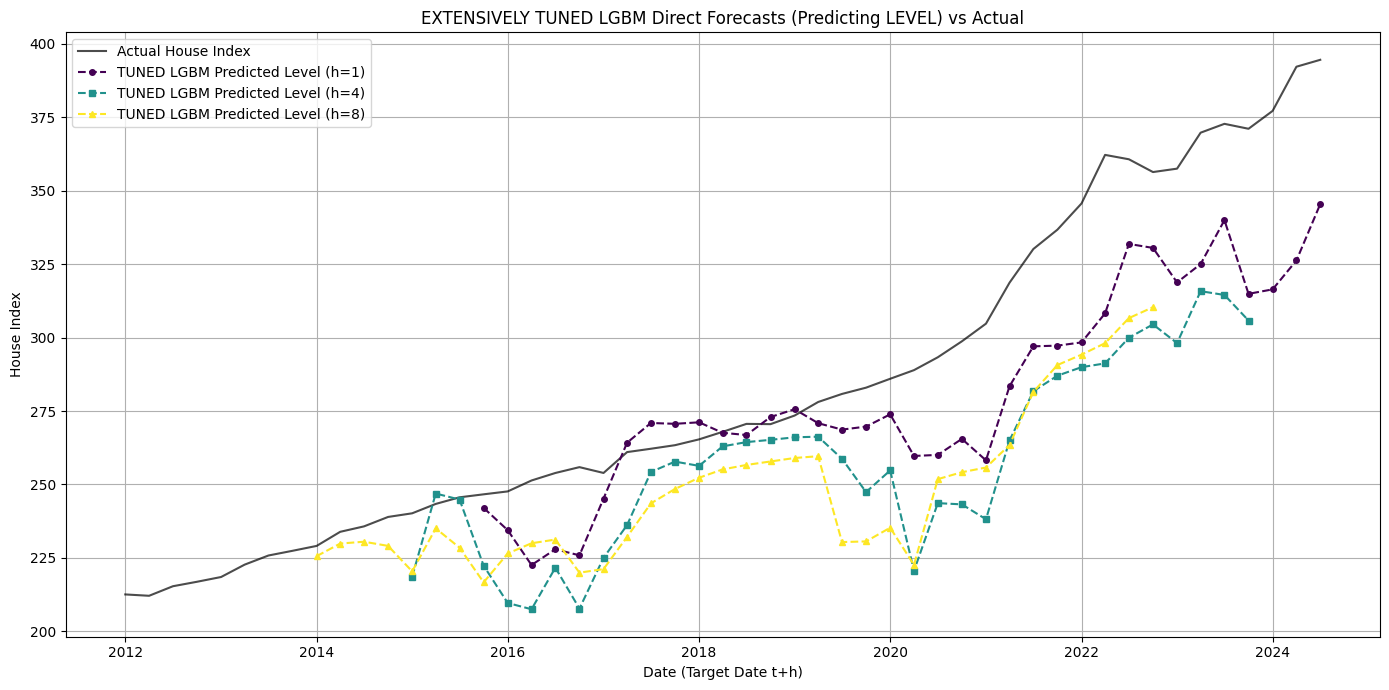


--- Completed EXTENSIVELY TUNED LGBM Runs (Predicting Level) ---

Best parameters found per horizon:
{1: {'colsample_bytree': 0.6427679457519285, 'learning_rate': 0.06047543235655418, 'max_depth': 7, 'n_estimators': 440, 'num_leaves': 24, 'reg_alpha': 0.8386972402950503, 'reg_lambda': 0.5821807361446398, 'subsample': 0.6995265261352889}, 4: {'colsample_bytree': 0.7378416337790239, 'learning_rate': 0.013085790430807246, 'max_depth': 3, 'n_estimators': 172, 'num_leaves': 22, 'reg_alpha': 0.21339334797568954, 'reg_lambda': 0.6651461942384054, 'subsample': 0.6629305120007313}, 8: {'colsample_bytree': 0.7867128308924751, 'learning_rate': 0.013446125942500001, 'max_depth': 8, 'n_estimators': 116, 'num_leaves': 60, 'reg_alpha': 0.4626756050653935, 'reg_lambda': 0.9809873781626851, 'subsample': 0.7933629743892586}}


In [19]:
# --- Code for TUNED Direct Multi-Step LGBM Evaluation (Predicting LEVEL - RandomizedSearch) ---

import pandas as pd
import numpy as np
import lightgbm as lgb
# For Tuning
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV # Use RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
# For parameter distributions
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta
import time

warnings.filterwarnings('ignore')

# --- Helper Functions ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

# --- Configuration ---
horizons_to_run = [1, 4, 8]
feature_file = 'DC_Data_For_Lasso.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test = 36
n_splits_cv = 3
tscv = TimeSeriesSplit(n_splits=n_splits_cv)

# Number of parameter settings that are sampled. n_iter trades off runtime vs quality of the solution.
n_iter_search = 1500 # Increase this for a more thorough search (will take longer)

# Parameter Distributions for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(100, 501), # Random integer between 100 and 500
    'learning_rate': uniform(0.01, 0.1), # Uniform distribution between 0.01 and 0.11
    'num_leaves': randint(10, 61), # Random integer between 10 and 60
    'max_depth': randint(3, 11), # Random integer between 3 and 10
    'reg_alpha': uniform(0.0, 1.0), # Uniform distribution between 0.0 and 1.0
    'reg_lambda': uniform(0.0, 1.0), # Uniform distribution between 0.0 and 1.0
    'colsample_bytree': uniform(0.6, 0.4), # Uniform distribution between 0.6 and 1.0
    'subsample': uniform(0.6, 0.4) # Uniform distribution between 0.6 and 1.0
}

results_all_horizons = {}
best_params_all_horizons = {}

print(f"--- Running EXTENSIVELY TUNED Direct LGBM Evaluation (Predicting LEVEL) for Horizons: {horizons_to_run} ---")
print(f"Using RandomizedSearchCV with n_iter = {n_iter_search}")

# --- Load Data ---
try:
    df_features_raw = pd.read_csv(feature_file, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print(f"Feature data loaded successfully from {feature_file}.")
    print(f"Master data loaded successfully from {master_file}.")

    target_col_diff = df_features_raw.columns[0]
    X_orig = df_features_raw.drop(columns=[target_col_diff])
    X_orig['time_trend'] = np.arange(len(X_orig))
    y_level_full = df_master['House_Index']

    # --- Loop through specified horizons ---
    for forecast_horizon in horizons_to_run:
        start_time_h = time.time()
        print(f"\n===== Processing Horizon h = {forecast_horizon} =====")

        # Prepare Data for horizon h
        y_level_h = y_level_full.shift(-forecast_horizon)
        df_aligned = X_orig.copy()
        df_aligned['Target_Level_h'] = y_level_h
        df_aligned.dropna(subset=['Target_Level_h'], inplace=True)
        common_index = X_orig.index.intersection(df_aligned.index)
        X = X_orig.loc[common_index]
        y = df_aligned.loc[common_index, 'Target_Level_h'] # LEVEL target

        if len(X) < n_test + n_splits_cv + 1:
            print(f"Warning: Not enough data ({len(X)}) for horizon {forecast_horizon}. Skipping.")
            continue

        # Split Data
        X_train_tune, X_test = X[:-n_test], X[-n_test:]
        y_train_tune, y_test = y[:-n_test], y[-n_test:]

        print(f"Tuning set size: {len(X_train_tune)}")
        print(f"Test set size: {len(X_test)}")

        # --- Hyperparameter Tuning using RandomizedSearchCV ---
        print(f"Starting RandomizedSearchCV for h={forecast_horizon} (n_iter={n_iter_search})... (This will take time)")
        start_tune_time = time.time()

        lgbm = lgb.LGBMRegressor(random_state=42, verbosity=-1)
        random_search = RandomizedSearchCV(estimator=lgbm,
                                           param_distributions=param_distributions,
                                           n_iter=n_iter_search, # Number of iterations
                                           scoring=rmse_scorer,
                                           cv=tscv,
                                           n_jobs=-1, # Use all cores
                                           random_state=42, # for reproducibility
                                           verbose=0)
        random_search.fit(X_train_tune, y_train_tune)

        tune_time = time.time() - start_tune_time
        print(f"RandomizedSearchCV finished in {tune_time:.2f} seconds.")
        print(f"Best parameters found for h={forecast_horizon}: {random_search.best_params_}")
        best_params = random_search.best_params_
        best_params_all_horizons[forecast_horizon] = best_params

        # --- Walk-Forward Validation using Best Parameters ---
        print("Starting walk-forward validation with best parameters...")
        X_train_full, _ = X[:-n_test], X[-n_test:]
        y_train_full, _ = y[:-n_test], y[-n_test:]
        history_X = X_train_full.copy()
        history_y = y_train_full.copy()
        predictions_level_h = []

        for t in range(len(X_test)):
            X_train_step = history_X
            y_train_step = history_y
            model = lgb.LGBMRegressor(**best_params, random_state=42, verbosity=-1)
            model.fit(X_train_step, y_train_step)
            current_X_test = X_test.iloc[[t]]
            y_pred_level = model.predict(current_X_test)[0]
            predictions_level_h.append(y_pred_level)
            history_X = pd.concat([history_X, current_X_test], ignore_index=False)
            history_y = pd.concat([history_y, y_test.iloc[[t]]], ignore_index=False)

        print("Walk-forward validation complete.")

        # --- Prepare Data for Metrics Calculation ---
        actual_original_scale = y_test.values
        predictions_original_scale = np.array(predictions_level_h)
        actual_prev_original_scale = []
        test_indices = y_test.index
        valid_indices_metric = []

        for i in range(len(test_indices)):
            target_date = test_indices[i]
            prev_date = target_date - relativedelta(months=3)
            try:
                actual_prev_value = df_master.loc[prev_date, 'House_Index']
                actual_prev_original_scale.append(actual_prev_value)
                valid_indices_metric.append(target_date)
            except KeyError:
                 print(f"Warning: Date {prev_date} not found for DA calculation (target {target_date}).")

        valid_mask = y_test.index.isin(valid_indices_metric)
        actual_original_scale_metric = y_test[valid_mask].values
        predictions_original_scale_metric = predictions_original_scale[valid_mask]
        actual_prev_original_scale_metric = np.array(actual_prev_original_scale)

        # --- Calculate Metrics for Horizon h ---
        if len(actual_original_scale_metric) == 0:
            print("\nNo valid points for metric calculation. Skipping metrics.")
            results_all_horizons[forecast_horizon] = None
            continue

        min_len = len(actual_original_scale_metric)
        if min_len < len(predictions_level_h):
             print(f"Warning: Metrics calculated on {min_len} points.")

        mae = mean_absolute_error(actual_original_scale_metric, predictions_original_scale_metric)
        rmse = np.sqrt(mean_squared_error(actual_original_scale_metric, predictions_original_scale_metric))
        mape = mean_absolute_percentage_error(actual_original_scale_metric, predictions_original_scale_metric)
        da = directional_accuracy(actual_original_scale_metric, predictions_original_scale_metric, actual_prev_original_scale_metric)

        metrics = { 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'DA': da }
        results_all_horizons[forecast_horizon] = {
            'metrics': metrics,
            'predictions_df': pd.DataFrame({
                'Actual_Original': y_test.values,
                'Predicted_Original': predictions_original_scale
            }, index=y_test.index)
        }

        print(f"\n--- EXTENSIVELY TUNED LGBM Performance Metrics (Direct Strategy - Predicting LEVEL) ---")
        print(f"Forecast Horizon (h): {forecast_horizon}")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        end_time_h = time.time()
        print(f"Total time for horizon {forecast_horizon}: {end_time_h - start_time_h:.2f} seconds.")


    # --- Plotting Combined Results ---
    print("\n--- Plotting Results for All Processed Horizons ---")
    plt.figure(figsize=(14, 7))

    min_plot_date = min((r['predictions_df'].index.min() for r in results_all_horizons.values() if r and not r['predictions_df'].empty), default=None)
    max_plot_date = max((r['predictions_df'].index.max() for r in results_all_horizons.values() if r and not r['predictions_df'].empty), default=None)

    if min_plot_date and max_plot_date:
        actual_data_subset = df_master[(df_master.index >= min_plot_date - relativedelta(years=2)) & (df_master.index <= max_plot_date)] # Show some history
        plt.plot(actual_data_subset.index, actual_data_subset['House_Index'], label='Actual House Index', color='black', linewidth=1.5, alpha=0.7)
    else:
         print("Could not determine date range for plotting actuals.")

    colors = plt.cm.viridis(np.linspace(0, 1, len(horizons_to_run)))
    markers = ['o', 's', '^', 'd', 'v', '<', '>', '*']

    for i, h in enumerate(horizons_to_run):
        if results_all_horizons.get(h):
            results_df = results_all_horizons[h]['predictions_df']
            if not results_df.empty:
                 plot_data = results_df[(results_df.index >= min_plot_date) & (results_df.index <= max_plot_date)] if min_plot_date else results_df
                 plt.plot(plot_data.index, plot_data['Predicted_Original'],
                          label=f'TUNED LGBM Predicted Level (h={h})', color=colors[i],
                          marker=markers[i % len(markers)], linestyle='--', markersize=4)

    plt.title('EXTENSIVELY TUNED LGBM Direct Forecasts (Predicting LEVEL) vs Actual')
    plt.xlabel('Date (Target Date t+h)')
    plt.ylabel('House Index')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed EXTENSIVELY TUNED LGBM Runs (Predicting Level) ---")
print("\nBest parameters found per horizon:")
print(best_params_all_horizons)

--- Running Baseline 1-Step LSTM Evaluation (Predicting Difference) ---
Timesteps=4, Epochs=30, LSTM Units=50
Feature data loaded successfully ((133, 35)).
Master data loaded successfully ((140, 9)).
Creating sequences with n_timesteps = 4...
Shape of sequence data: X=(129, 4, 34), y=(129,)
Sequence Train shapes: X=(93, 4, 34), y=(93,)
Sequence Test shapes: X=(36, 4, 34), y=(36,)

Starting walk-forward validation (LSTM retraining)...
Processing walk-forward step 1/36...
Step 1 finished in 1.87 seconds.
Processing walk-forward step 2/36...
Step 2 finished in 1.80 seconds.
Processing walk-forward step 3/36...
Step 3 finished in 1.80 seconds.
Processing walk-forward step 4/36...
Step 4 finished in 1.56 seconds.
Processing walk-forward step 5/36...
Step 5 finished in 1.86 seconds.
Processing walk-forward step 6/36...
Step 6 finished in 1.74 seconds.
Processing walk-forward step 7/36...
Step 7 finished in 1.74 seconds.
Processing walk-forward step 8/36...
Step 8 finished in 1.74 seconds.
Pr

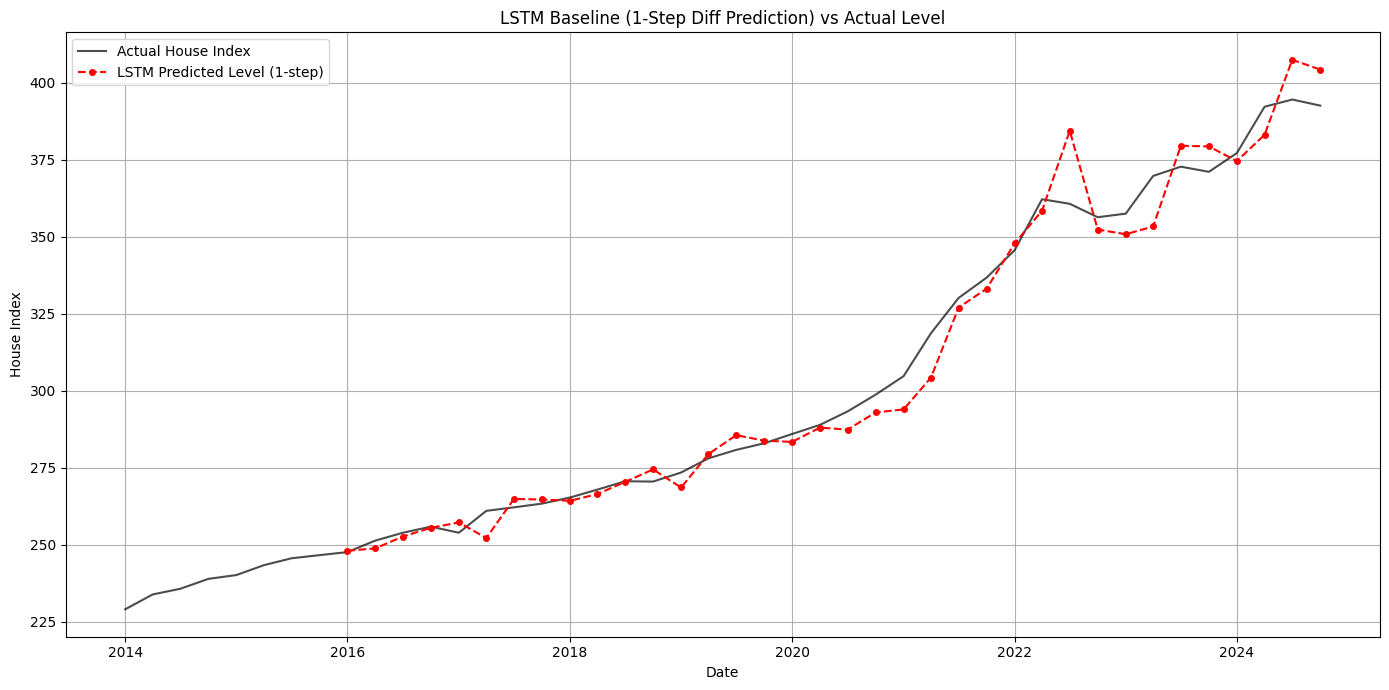


--- Completed LSTM Baseline Run ---


In [ ]:
# --- Code for Baseline 1-Step LSTM Evaluation (Predicting Difference) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Deep Learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta
import time

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

warnings.filterwarnings('ignore')

# --- Helper Functions ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    # Avoid issues with very small denominators if needed
    # epsilon = 1e-8
    # return np.mean(np.abs((y_true[mask] - y_pred[mask]) / (y_true[mask] + epsilon))) * 100
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    if not (len(y_true) == len(y_pred) == len(y_true_prev)): return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    if len(correct_direction) == 0: return np.nan
    return np.mean(correct_direction) * 100

# Function to create sequences
def create_sequences(X_data, y_data, n_timesteps):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - n_timesteps):
        # Sequence of features ends at i + n_timesteps - 1
        X_seq.append(X_data[i:(i + n_timesteps)])
        # Target corresponds to the step *after* the sequence ends
        y_seq.append(y_data[i + n_timesteps])
    return np.array(X_seq), np.array(y_seq)

# --- Configuration ---
n_timesteps = 4 # Lookback window (e.g., 4 quarters = 1 year)
n_epochs = 30   # Number of epochs for training at each step (keep low initially)
n_lstm_units = 50 # Number of units in the LSTM layer

feature_file = 'DC_Data_For_Lasso.csv' # File with all stationary features
master_file = 'DC_Master_Data_Filled.csv' # Needed for inverse differencing
n_test = 44 # Number of walk-forward steps

print(f"--- Running Baseline 1-Step LSTM Evaluation (Predicting Difference) ---")
print(f"Timesteps={n_timesteps}, Epochs={n_epochs}, LSTM Units={n_lstm_units}")

# --- Load Data ---
try:
    df_features_raw = pd.read_csv(feature_file, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print(f"Feature data loaded successfully ({df_features_raw.shape}).")
    print(f"Master data loaded successfully ({df_master.shape}).")

    # --- Prepare Data ---
    target_col_diff = df_features_raw.columns[0]
    y_diff = df_features_raw[[target_col_diff]] # Keep as DataFrame for scaler
    X_features = df_features_raw.drop(columns=[target_col_diff])
    n_features = X_features.shape[1]

    # --- Scaling ---
    # Scale features (fit only on initial training part)
    scaler_X = StandardScaler()
    X_train_presplit = X_features[:-n_test]
    scaler_X.fit(X_train_presplit) # Fit only on initial training data
    X_scaled = scaler_X.transform(X_features)

    # Scale target (differenced)
    scaler_y = StandardScaler()
    y_train_presplit = y_diff[:-n_test]
    scaler_y.fit(y_train_presplit) # Fit only on initial training data
    y_scaled = scaler_y.transform(y_diff)

    # --- Create Sequences ---
    print(f"Creating sequences with n_timesteps = {n_timesteps}...")
    X_seq, y_seq = create_sequences(X_scaled, y_scaled.flatten(), n_timesteps)
    # Get the corresponding dates for y_seq (which are t+1 relative to sequence end)
    # The first y_seq corresponds to index n_timesteps of the original df
    y_seq_dates = df_features_raw.index[n_timesteps:]

    print(f"Shape of sequence data: X={X_seq.shape}, y={y_seq.shape}") # y_seq should be (samples,)

    if len(X_seq) < n_test + 1: # Need at least n_test sequences + 1 for split
         raise ValueError(f"Not enough sequences ({len(X_seq)}) generated to support n_test={n_test}.")

    # --- Split Sequenced Data ---
    X_seq_train_full, X_seq_test = X_seq[:-n_test], X_seq[-n_test:]
    y_seq_train_full, y_seq_test = y_seq[:-n_test], y_seq[-n_test:]
    y_seq_test_dates = y_seq_dates[-n_test:] # Dates corresponding to y_seq_test

    print(f"Sequence Train shapes: X={X_seq_train_full.shape}, y={y_seq_train_full.shape}")
    print(f"Sequence Test shapes: X={X_seq_test.shape}, y={y_seq_test.shape}")

    # --- Walk-Forward Validation ---
    history_X = [x for x in X_seq_train_full] # Use list for easier appending
    history_y = [y for y in y_seq_train_full]
    predictions_diff_scaled = [] # Store SCALED diff predictions

    print("\nStarting walk-forward validation (LSTM retraining)...")
    start_walk_time = time.time()

    for t in range(len(X_seq_test)):
        print(f"Processing walk-forward step {t + 1}/{len(X_seq_test)}...")
        start_step_time = time.time()

        # Define the LSTM model architecture (redefine each time to reset weights)
        model = Sequential([
            Input(shape=(n_timesteps, n_features)),
            LSTM(n_lstm_units, activation='relu'), # Use relu or tanh
            Dense(1) # Output layer for regression
        ])
        model.compile(optimizer='adam', loss='mse')

        # Prepare training data for this step
        current_X_train = np.array(history_X)
        current_y_train = np.array(history_y)

        # Fit the model
        # Use early stopping potentially? Or fixed epochs. Let's use fixed for now.
        model.fit(current_X_train, current_y_train,
                  epochs=n_epochs, verbose=0, batch_size=8) # Smaller batch size

        # Prepare test input for prediction
        current_X_test_seq = X_seq_test[t].reshape((1, n_timesteps, n_features))

        # Predict (scaled value)
        y_pred_scaled = model.predict(current_X_test_seq, verbose=0)[0][0]
        predictions_diff_scaled.append(y_pred_scaled)

        # Update history (append the actual test sequence and target)
        history_X.append(X_seq_test[t])
        history_y.append(y_seq_test[t])

        step_time = time.time() - start_step_time
        print(f"Step {t + 1} finished in {step_time:.2f} seconds.")


    walk_time = time.time() - start_walk_time
    print(f"Walk-forward validation complete in {walk_time:.2f} seconds.")

    # --- Inverse Transform Predictions ---
    predictions_diff_scaled_array = np.array(predictions_diff_scaled).reshape(-1, 1)
    predictions_diff = scaler_y.inverse_transform(predictions_diff_scaled_array).flatten()

    # --- Inverse Differencing to Original Level Scale ---
    predictions_original_scale = []
    actual_original_scale = []
    actual_prev_original_scale = []
    valid_indices_metric = []

    for i in range(len(predictions_diff)):
        pred_diff = predictions_diff[i]
        target_date = y_seq_test_dates[i] # Date for which prediction is made (t+1)
        prev_date = target_date - relativedelta(months=3) # Date t

        try:
            # Get actual level at t+1 and t from master data
            actual_target_value = df_master.loc[target_date, 'House_Index']
            actual_prev_value = df_master.loc[prev_date, 'House_Index']

            # Calculate predicted level: Prev_Actual(t) + Predicted_Diff(t+1)
            predicted_original = actual_prev_value + pred_diff

            predictions_original_scale.append(predicted_original)
            actual_original_scale.append(actual_target_value)
            actual_prev_original_scale.append(actual_prev_value)
            valid_indices_metric.append(target_date)

        except KeyError:
            print(f"Warning: Date {target_date} or {prev_date} not found in master data for inverse differencing. Skipping point.")


    # --- Calculate Metrics (1-Step Ahead) ---
    if not predictions_original_scale:
         print("\nNo valid predictions generated. Cannot calculate metrics.")
    else:
        # Ensure all arrays for metrics are aligned and have the same length
        min_len = min(len(actual_original_scale), len(predictions_original_scale), len(actual_prev_original_scale))
        actual_original_scale = actual_original_scale[:min_len]
        predictions_original_scale = predictions_original_scale[:min_len]
        actual_prev_original_scale = actual_prev_original_scale[:min_len]

        if min_len < len(predictions_diff):
             print(f"Warning: Metrics calculated on {min_len} points due to missing dates.")

        mae = mean_absolute_error(actual_original_scale, predictions_original_scale)
        rmse = np.sqrt(mean_squared_error(actual_original_scale, predictions_original_scale))
        mape = mean_absolute_percentage_error(actual_original_scale, predictions_original_scale)
        da = directional_accuracy(actual_original_scale, predictions_original_scale, actual_prev_original_scale)

        print("\n--- LSTM Baseline Performance Metrics (1-Step Ahead, Predicting Difference) ---")
        print(f"MAE:  {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"MAPE: {mape:.3f}%")
        print(f"DA:   {da:.3f}%")

        # --- Plotting ---
        results_df = pd.DataFrame({
            'Actual_Original': actual_original_scale,
            'Predicted_Original': predictions_original_scale
        }, index=pd.to_datetime(valid_indices_metric)) # Use dates where calculation was successful

        plt.figure(figsize=(14, 7))

        # Plot actual data over the test period + some history
        min_plot_date = results_df.index.min() - relativedelta(years=2) if not results_df.empty else None
        max_plot_date = results_df.index.max() if not results_df.empty else None

        if min_plot_date and max_plot_date:
             actual_data_subset = df_master[(df_master.index >= min_plot_date) & (df_master.index <= max_plot_date)]
             plt.plot(actual_data_subset.index, actual_data_subset['House_Index'], label='Actual House Index', color='black', linewidth=1.5, alpha=0.7)
        else:
            print("Could not determine date range for actuals plot.")

        if not results_df.empty:
             plt.plot(results_df.index, results_df['Predicted_Original'], label='LSTM Predicted Level (1-step)', color='red', linestyle='--', marker='o', markersize=4)

        plt.title('LSTM Baseline (1-Step Diff Prediction) vs Actual Level')
        plt.xlabel('Date')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed LSTM Baseline Run ---")

--- Running Multi-Output LSTM Evaluation (Predicting Difference Vector) ---
Timesteps=4, Outputs=8, Epochs=50, LSTM Units=64
Feature data loaded successfully ((133, 35)).
Master data loaded successfully ((140, 9)).
Creating multi-output sequences (n_timesteps=4, n_outputs=8)...
Shape of sequence data: X=(122, 4, 34), y=(122, 8)
Sequence Train shapes: X=(86, 4, 34), y=(86, 8)
Sequence Test shapes: X=(36, 4, 34), y=(36, 8)

Starting walk-forward validation (Multi-Output LSTM retraining)...
Processing Origin 1/36 (Date: 2013-04-01)...
Processing Origin 2/36 (Date: 2013-07-01)...
Processing Origin 3/36 (Date: 2013-10-01)...
Processing Origin 4/36 (Date: 2014-01-01)...
Processing Origin 5/36 (Date: 2014-04-01)...
Processing Origin 6/36 (Date: 2014-07-01)...
Processing Origin 7/36 (Date: 2014-10-01)...
Processing Origin 8/36 (Date: 2015-01-01)...
Processing Origin 9/36 (Date: 2015-04-01)...
Processing Origin 10/36 (Date: 2015-07-01)...
Processing Origin 11/36 (Date: 2015-10-01)...
Processing

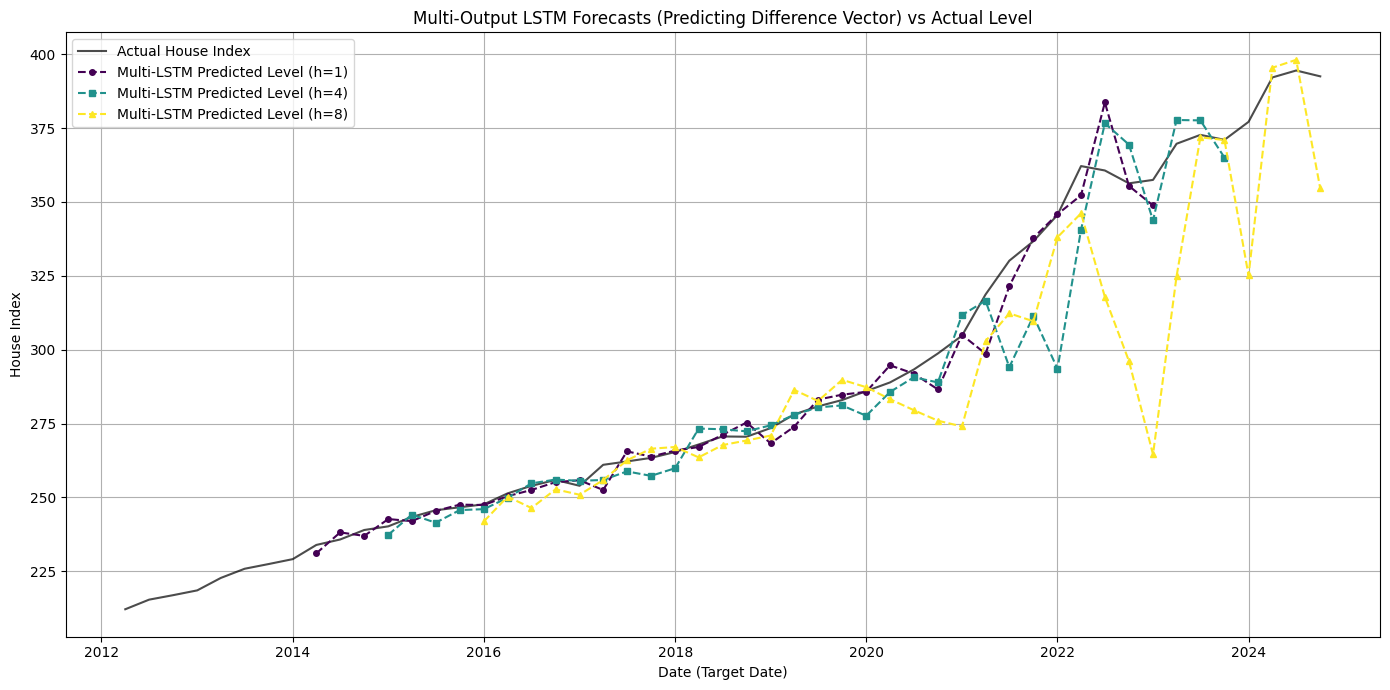


--- Completed Multi-Output LSTM Run ---


In [1]:
# --- Code for Multi-Output LSTM Evaluation (Predicting Difference Vector) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Deep Learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta
import time

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

warnings.filterwarnings('ignore')

# --- Helper Functions ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    # Ensure lengths match after potential filtering/alignment
    min_len = min(len(y_true), len(y_pred), len(y_true_prev))
    y_true, y_pred, y_true_prev = y_true[:min_len], y_pred[:min_len], y_true_prev[:min_len]
    if min_len == 0: return np.nan

    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    return np.mean(correct_direction) * 100

# Function to create sequences for multi-output target
def create_multi_output_sequences(X_data, y_data, n_timesteps, n_outputs):
    X_seq, y_seq = [], []
    # Ensure loop doesn't go out of bounds for features or targets
    # Need n_timesteps history for X, and n_outputs future for y
    for i in range(len(X_data) - n_timesteps - n_outputs + 1):
        # Input sequence: Features from i to i + n_timesteps - 1
        X_seq.append(X_data[i:(i + n_timesteps)])
        # Output sequence: Targets from i + n_timesteps to i + n_timesteps + n_outputs - 1
        y_seq.append(y_data[(i + n_timesteps):(i + n_timesteps + n_outputs)])
    return np.array(X_seq), np.array(y_seq)

# --- Configuration ---
n_timesteps = 4  # Lookback window
n_outputs = 8    # Number of steps to predict ahead (h=1 to 8)
n_epochs = 50    # Increased epochs slightly, will use early stopping
n_lstm_units = 64 # Increased units slightly

feature_file = 'DC_Data_For_Lasso.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test_origins = 36 # Number of forecast origins in walk-forward

print(f"--- Running Multi-Output LSTM Evaluation (Predicting Difference Vector) ---")
print(f"Timesteps={n_timesteps}, Outputs={n_outputs}, Epochs={n_epochs}, LSTM Units={n_lstm_units}")

# --- Load Data ---
try:
    df_features_raw = pd.read_csv(feature_file, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print(f"Feature data loaded successfully ({df_features_raw.shape}).")
    print(f"Master data loaded successfully ({df_master.shape}).")

    # --- Prepare Data ---
    target_col_diff = df_features_raw.columns[0]
    y_diff = df_features_raw[[target_col_diff]] # Keep as DataFrame for scaler
    X_features = df_features_raw.drop(columns=[target_col_diff])
    n_features = X_features.shape[1]

    # --- Scaling ---
    scaler_X = StandardScaler()
    # Fit scaler only on the portion used for initial training sequence creation
    # If n_test_origins starts after initial training, this split needs care
    # For simplicity, fit on data *before* the test origins start
    fit_end_index = len(df_features_raw) - n_test_origins
    scaler_X.fit(X_features[:fit_end_index])
    X_scaled = scaler_X.transform(X_features)

    scaler_y = StandardScaler()
    scaler_y.fit(y_diff[:fit_end_index])
    y_scaled = scaler_y.transform(y_diff)

    # --- Create Sequences ---
    print(f"Creating multi-output sequences (n_timesteps={n_timesteps}, n_outputs={n_outputs})...")
    X_seq, y_seq = create_multi_output_sequences(X_scaled, y_scaled.flatten(), n_timesteps, n_outputs)
    # Get the dates corresponding to the *start* of each input sequence
    seq_start_dates = df_features_raw.index[:len(X_seq)]
    # Dates corresponding to the *first* target in each output sequence y_seq[i]
    y_seq_start_dates = df_features_raw.index[n_timesteps : n_timesteps + len(y_seq)]

    print(f"Shape of sequence data: X={X_seq.shape}, y={y_seq.shape}")

    if len(X_seq) < n_test_origins + 1:
         raise ValueError(f"Not enough sequences ({len(X_seq)}) generated for n_test_origins={n_test_origins}.")

    # --- Split Sequenced Data ---
    # Split based on the number of forecast origins we want to test
    X_seq_train_full, X_seq_test = X_seq[:-n_test_origins], X_seq[-n_test_origins:]
    y_seq_train_full, y_seq_test = y_seq[:-n_test_origins], y_seq[-n_test_origins:]
    test_origin_dates = seq_start_dates[-n_test_origins:] # Dates when forecasts are made

    print(f"Sequence Train shapes: X={X_seq_train_full.shape}, y={y_seq_train_full.shape}")
    print(f"Sequence Test shapes: X={X_seq_test.shape}, y={y_seq_test.shape}") # y_seq_test is (n_test, n_outputs)

    # --- Walk-Forward Validation ---
    history_X = [x for x in X_seq_train_full]
    history_y = [y for y in y_seq_train_full]
    # Store predictions indexed by origin date and target date
    predictions_dict = {} # Key: target_date, Value: {origin_date: prediction}

    print("\nStarting walk-forward validation (Multi-Output LSTM retraining)...")
    start_walk_time = time.time()

    def build_multi_lstm_model(n_timesteps, n_features, n_outputs, n_lstm_units):
        model = Sequential([
            Input(shape=(n_timesteps, n_features)),
            LSTM(n_lstm_units, activation='relu'),
            Dense(n_outputs) # Output layer predicts all steps
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
        return model

    for t in range(len(X_seq_test)):
        origin_date = test_origin_dates[t]
        print(f"Processing Origin {t + 1}/{len(X_seq_test)} (Date: {origin_date.date()})...")
        start_step_time = time.time()

        model = build_multi_lstm_model(n_timesteps, n_features, n_outputs, n_lstm_units)

        current_X_train = np.array(history_X)
        current_y_train = np.array(history_y)

        early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True) # Increased patience
        model.fit(current_X_train, current_y_train,
                  epochs=n_epochs, verbose=0, batch_size=16,
                  callbacks=[early_stopping])

        current_X_test_seq = X_seq_test[t].reshape((1, n_timesteps, n_features))
        y_pred_scaled_vector = model.predict(current_X_test_seq, verbose=0)[0] # Shape (n_outputs,)

        # Inverse transform the predicted difference vector
        y_pred_diff_vector = scaler_y.inverse_transform(y_pred_scaled_vector.reshape(1, -1)).flatten() # Shape (n_outputs,)

        # Perform iterative inverse differencing to get level predictions
        try:
            # Get the actual level at the forecast origin date 't'
            last_actual_level = df_master.loc[origin_date + relativedelta(months=(n_timesteps-1)*3), 'House_Index'] # Level at end of input seq
        except KeyError:
             print(f"Warning: Cannot find level at {origin_date + relativedelta(months=(n_timesteps-1)*3)} to start inverse differencing for origin {origin_date.date()}. Skipping origin.")
             # Update history even if skipped
             history_X.append(X_seq_test[t])
             history_y.append(y_seq_test[t])
             continue


        predicted_levels = []
        current_level = last_actual_level
        for h in range(n_outputs): # h goes from 0 to 7
            pred_diff = y_pred_diff_vector[h]
            current_level = current_level + pred_diff # Predict level t+1 using level t and diff t+1
            target_date = origin_date + relativedelta(months=(n_timesteps + h)*3) # Target date relative to start of sequence
            predicted_levels.append(current_level)

            # Store prediction: predictions_dict[target_date] = current_level
            # Need to handle multiple predictions for the same target date from different origins if needed
            # For now, let's store based on origin and horizon
            if target_date not in predictions_dict:
                predictions_dict[target_date] = {}
            predictions_dict[target_date][origin_date] = current_level


        # Update history
        history_X.append(X_seq_test[t])
        history_y.append(y_seq_test[t])

        step_time = time.time() - start_step_time
        # print(f"Step {t + 1} finished in {step_time:.2f} seconds.")

    walk_time = time.time() - start_walk_time
    print(f"Walk-forward validation complete in {walk_time:.2f} seconds.")


    # --- Calculate Metrics for Each Horizon h ---
    print("\nCalculating performance metrics...")
    metrics_results = []
    all_preds_aligned = {h: [] for h in range(1, n_outputs + 1)}
    all_actuals_aligned = {h: [] for h in range(1, n_outputs + 1)}
    all_prev_actuals_aligned = {h: [] for h in range(1, n_outputs + 1)}
    valid_indices_by_h = {h: [] for h in range(1, n_outputs + 1)}

    # Iterate through test origins to gather predictions and actuals by horizon
    for t in range(len(X_seq_test)):
        origin_date = test_origin_dates[t]
        # Recalculate predicted levels for this origin to align with actuals
        # (Assuming prediction logic ran correctly and stored in predictions_dict or re-run predict step if needed)
        # Let's re-simulate the prediction and inverse differencing for simplicity here,
        # ensuring alignment with actuals from df_master.

        current_X_test_seq = X_seq_test[t].reshape((1, n_timesteps, n_features))
        # Need the model trained *just before* this step, or retrain final model?
        # For eval, we use the preds made during the loop. Let's structure accessing predictions_dict

        for h in range(1, n_outputs + 1): # Horizon h=1 to 8
             target_date = origin_date + relativedelta(months=(n_timesteps + h - 1)*3) # Target date relative to start of sequence
             prev_target_date = target_date - relativedelta(months=3) # Date for previous actual

             if target_date in predictions_dict and origin_date in predictions_dict[target_date]:
                 # Check if actual and previous actual exist
                 if target_date in df_master.index and prev_target_date in df_master.index:
                      pred_level = predictions_dict[target_date][origin_date]
                      actual_level = df_master.loc[target_date, 'House_Index']
                      prev_actual_level = df_master.loc[prev_target_date, 'House_Index']

                      all_preds_aligned[h].append(pred_level)
                      all_actuals_aligned[h].append(actual_level)
                      all_prev_actuals_aligned[h].append(prev_actual_level)
                      valid_indices_by_h[h].append(target_date)
                 # else:
                     # print(f"Skipping metric for h={h}, origin={origin_date.date()}: Actual/Prev date missing.")
             # else:
                 # print(f"Skipping metric for h={h}, origin={origin_date.date()}: Prediction missing.")


    # Now calculate metrics for each horizon
    final_metrics = []
    plot_dfs = {}
    for h in range(1, n_outputs + 1):
        preds = np.array(all_preds_aligned[h])
        actuals = np.array(all_actuals_aligned[h])
        prev_actuals = np.array(all_prev_actuals_aligned[h])
        indices = pd.to_datetime(valid_indices_by_h[h])

        if len(preds) > 0:
            mae = mean_absolute_error(actuals, preds)
            rmse = np.sqrt(mean_squared_error(actuals, preds))
            mape = mean_absolute_percentage_error(actuals, preds)
            da = directional_accuracy(actuals, preds, prev_actuals)

            final_metrics.append({
                'Forecast Horizon (Steps)': h,
                'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'DA': da
            })
            plot_dfs[h] = pd.DataFrame({'Actual_Original': actuals, 'Predicted_Original': preds}, index=indices)
        else:
            print(f"No valid predictions found for horizon h={h}. Skipping metrics.")
            final_metrics.append({
                'Forecast Horizon (Steps)': h,
                'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'DA': np.nan
            })


    metrics_df = pd.DataFrame(final_metrics)
    print("\n--- Multi-Output LSTM Performance Metrics ---")
    print(metrics_df.to_string(index=False, float_format="%.3f"))


    # --- Plotting Selected Horizons ---
    print("\n--- Plotting Results for Selected Horizons (h=1, 4, 8) ---")
    plt.figure(figsize=(14, 7))

    horizons_to_plot = [1, 4, 8]
    min_plot_date = min((df.index.min() for h, df in plot_dfs.items() if not df.empty), default=None)
    max_plot_date = max((df.index.max() for h, df in plot_dfs.items() if not df.empty), default=None)

    if min_plot_date and max_plot_date:
        actual_data_subset = df_master[(df_master.index >= min_plot_date - relativedelta(years=2)) & (df_master.index <= max_plot_date)]
        plt.plot(actual_data_subset.index, actual_data_subset['House_Index'], label='Actual House Index', color='black', linewidth=1.5, alpha=0.7)
    else:
         print("Could not determine date range for plotting actuals.")

    colors = plt.cm.viridis(np.linspace(0, 1, len(horizons_to_plot)))
    markers = ['o', 's', '^']

    for i, h in enumerate(horizons_to_plot):
        if h in plot_dfs and not plot_dfs[h].empty:
            results_df = plot_dfs[h]
            plot_data = results_df[(results_df.index >= min_plot_date) & (results_df.index <= max_plot_date)] if min_plot_date else results_df
            plt.plot(plot_data.index, plot_data['Predicted_Original'],
                      label=f'Multi-LSTM Predicted Level (h={h})', color=colors[i],
                      marker=markers[i % len(markers)], linestyle='--', markersize=4)

    plt.title('Multi-Output LSTM Forecasts (Predicting Difference Vector) vs Actual Level')
    plt.xlabel('Date (Target Date)')
    plt.ylabel('House Index')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names. {e}")
except ValueError as e:
    print(f"Error: Value error during processing. {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Multi-Output LSTM Run ---")

--- Generating Future Forecast (Q1 2025 - Q4 2026) using Final Multi-Output LSTM ---
Data loaded successfully.
Creating sequences on all data...
Shape of final sequence data: X=(122, 4, 34), y=(122, 8)
Training final Multi-Output LSTM model on all data...
Final model training complete in 2.28 seconds.
Shape of input sequence for forecast: (1, 4, 34)
Predicting future steps...
Inverse differencing future predictions...
Last actual House_Index value (2024-10-01): 392.54

--- Future Forecast Results (Q1 2025 - Q4 2026) ---
            Forecasted_House_Index
2025-01-01              409.007758
2025-04-01              418.015741
2025-07-01              424.925464
2025-10-01              433.150240
2026-01-01              439.567591
2026-04-01              447.807444
2026-07-01              446.159750
2026-10-01              453.897535


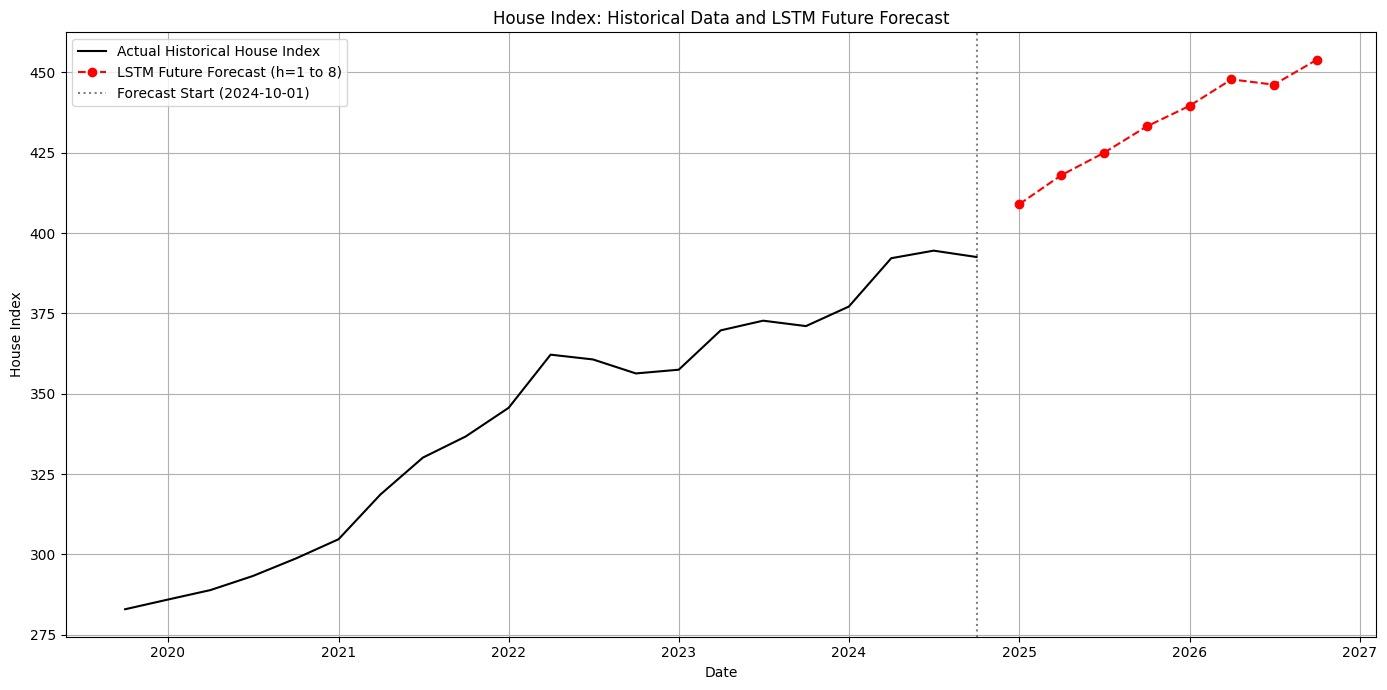


--- Completed LSTM Future Forecast Generation ---


In [23]:
# --- Code to Generate Future Forecast using Final Multi-Output LSTM ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
# Deep Learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
import warnings
from dateutil.relativedelta import relativedelta
import time

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

warnings.filterwarnings('ignore')

# Function to create sequences for multi-output target (same as before)
def create_multi_output_sequences(X_data, y_data, n_timesteps, n_outputs):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - n_timesteps - n_outputs + 1):
        X_seq.append(X_data[i:(i + n_timesteps)])
        y_seq.append(y_data[(i + n_timesteps):(i + n_timesteps + n_outputs)])
    return np.array(X_seq), np.array(y_seq)

# --- Configuration ---
n_timesteps = 4
n_outputs = 8
n_epochs = 50 # Use same epochs as walk-forward for consistency
n_lstm_units = 64

feature_file = 'DC_Data_For_Lasso.csv'
master_file = 'DC_Master_Data_Filled.csv'

print(f"--- Generating Future Forecast (Q1 2025 - Q4 2026) using Final Multi-Output LSTM ---")

# --- Load Data ---
try:
    df_features_raw = pd.read_csv(feature_file, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print("Data loaded successfully.")

    # --- Prepare ALL Data for Final Model Training ---
    target_col_diff = df_features_raw.columns[0]
    y_diff_full = df_features_raw[[target_col_diff]]
    X_features_full = df_features_raw.drop(columns=[target_col_diff])
    n_features = X_features_full.shape[1]

    # --- Scaling (Fit on ALL data now) ---
    scaler_X_final = StandardScaler()
    X_scaled_full = scaler_X_final.fit_transform(X_features_full)

    scaler_y_final = StandardScaler()
    y_scaled_full = scaler_y_final.fit_transform(y_diff_full)

    # --- Create Sequences on ALL Data ---
    # Need to ensure y_scaled_full aligns correctly for multi-output target
    # We only need the sequences for training, the actual y_seq isn't strictly needed
    # if we rebuild model each time, but good practice to create matching length X/y
    print(f"Creating sequences on all data...")
    # We need enough data points to form at least one sequence pair
    if len(X_scaled_full) < n_timesteps + n_outputs:
         raise ValueError("Not enough historical data points to create sequences for training.")

    # Create sequences for training the final model
    X_seq_final, y_seq_final = create_multi_output_sequences(
        X_scaled_full, y_scaled_full.flatten(), n_timesteps, n_outputs
    )
    print(f"Shape of final sequence data: X={X_seq_final.shape}, y={y_seq_final.shape}")

    # --- Train Final LSTM Model ---
    print("Training final Multi-Output LSTM model on all data...")
    start_train_time = time.time()

    def build_final_multi_lstm_model(n_timesteps, n_features, n_outputs, n_lstm_units):
        model = Sequential([
            Input(shape=(n_timesteps, n_features)),
            LSTM(n_lstm_units, activation='relu'),
            Dense(n_outputs)
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
        return model

    final_model = build_final_multi_lstm_model(n_timesteps, n_features, n_outputs, n_lstm_units)

    # No early stopping for the final model, train for full epochs
    final_model.fit(X_seq_final, y_seq_final,
                    epochs=n_epochs, verbose=0, batch_size=16)

    train_time = time.time() - start_train_time
    print(f"Final model training complete in {train_time:.2f} seconds.")

    # --- Prepare Input for Forecasting ---
    # Need the last sequence from the full dataset
    last_sequence_X_scaled = X_scaled_full[-n_timesteps:]
    # Reshape for LSTM input: (1 sample, n_timesteps, n_features)
    last_sequence_input = last_sequence_X_scaled.reshape((1, n_timesteps, n_features))
    print(f"Shape of input sequence for forecast: {last_sequence_input.shape}")

    # --- Predict Future Steps ---
    print("Predicting future steps...")
    y_pred_scaled_future_vector = final_model.predict(last_sequence_input, verbose=0)[0] # Shape (n_outputs,)

    # Inverse transform the predicted difference vector
    y_pred_diff_future = scaler_y_final.inverse_transform(y_pred_scaled_future_vector.reshape(1, -1)).flatten()

    # --- Inverse Differencing for Future Forecast ---
    print("Inverse differencing future predictions...")
    # Get the last known actual House_Index value
    last_actual_date = df_master.index.max()
    last_actual_level = df_master.loc[last_actual_date, 'House_Index']
    print(f"Last actual House_Index value ({last_actual_date.date()}): {last_actual_level:.2f}")

    future_predictions_level = []
    current_level = last_actual_level
    for h in range(n_outputs): # h=0 to 7
        pred_diff = y_pred_diff_future[h]
        current_level = current_level + pred_diff # Predicted Level(t+h+1) = Level(t+h) + Diff(t+h+1)
        future_predictions_level.append(current_level)

    # Create future dates index
    future_dates = pd.date_range(start=last_actual_date + relativedelta(months=3), periods=n_outputs, freq='QS')

    future_results_df = pd.DataFrame({
        'Forecasted_House_Index': future_predictions_level
    }, index=future_dates)

    print("\n--- Future Forecast Results (Q1 2025 - Q4 2026) ---")
    print(future_results_df)

    # --- Plotting Future Forecast ---
    plt.figure(figsize=(14, 7))

    # Plot historical actual data (e.g., last 5 years + forecast period)
    plot_start_date = last_actual_date - relativedelta(years=5)
    actual_data_subset = df_master[(df_master.index >= plot_start_date)]
    plt.plot(actual_data_subset.index, actual_data_subset['House_Index'], label='Actual Historical House Index', color='black', linewidth=1.5)

    # Plot future forecast
    plt.plot(future_results_df.index, future_results_df['Forecasted_House_Index'], label='LSTM Future Forecast (h=1 to 8)', color='red', linestyle='--', marker='o')

    plt.title('House Index: Historical Data and LSTM Future Forecast')
    plt.xlabel('Date')
    plt.ylabel('House Index')
    plt.axvline(last_actual_date, color='gray', linestyle=':', label=f'Forecast Start ({last_actual_date.date()})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names. {e}")
except ValueError as e:
    print(f"Error: Value error during processing: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed LSTM Future Forecast Generation ---")

In [2]:
# --- Code for TUNED Multi-Output LSTM Evaluation (Predicting Difference Vector) ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer
# Deep Learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
# For Tuning Keras Models with Scikit-learn
from scikeras.wrappers import KerasRegressor

# For Tuning Search and Distributions
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform # Use loguniform for learning rate potentially

import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta
import time





--- Running TUNED Multi-Output LSTM Evaluation (Predicting Difference) ---
Using RandomizedSearchCV with n_iter = 2000
Data loaded successfully.
Added time_trend feature.
Creating multi-output sequences...
Shape of full sequence data: X=(122, 4, 35), y=(122, 8)
Sequence Tuning shapes: X=(86, 4, 35), y=(86, 8)
Sequence Test shapes: X=(36, 4, 35), y=(36, 8)

Starting RandomizedSearchCV (n_iter=2000)... (This WILL take a long time!)
Fitting 3 folds for each of 2000 candidates, totalling 6000 fits
RandomizedSearchCV finished in 2272.26 seconds.
Best parameters found: {'batch_size': 32, 'model__activation': 'relu', 'model__dropout_rate': 0.1738912015244436, 'model__learning_rate': 0.00011048189703093158, 'model__lstm_units': 67}
Extracted best model params: {'activation': 'relu', 'dropout_rate': 0.1738912015244436, 'learning_rate': 0.00011048189703093158, 'lstm_units': 67}
Extracted best fit params: {'batch_size': 32}

Starting walk-forward validation with best parameters...
Processing Orig

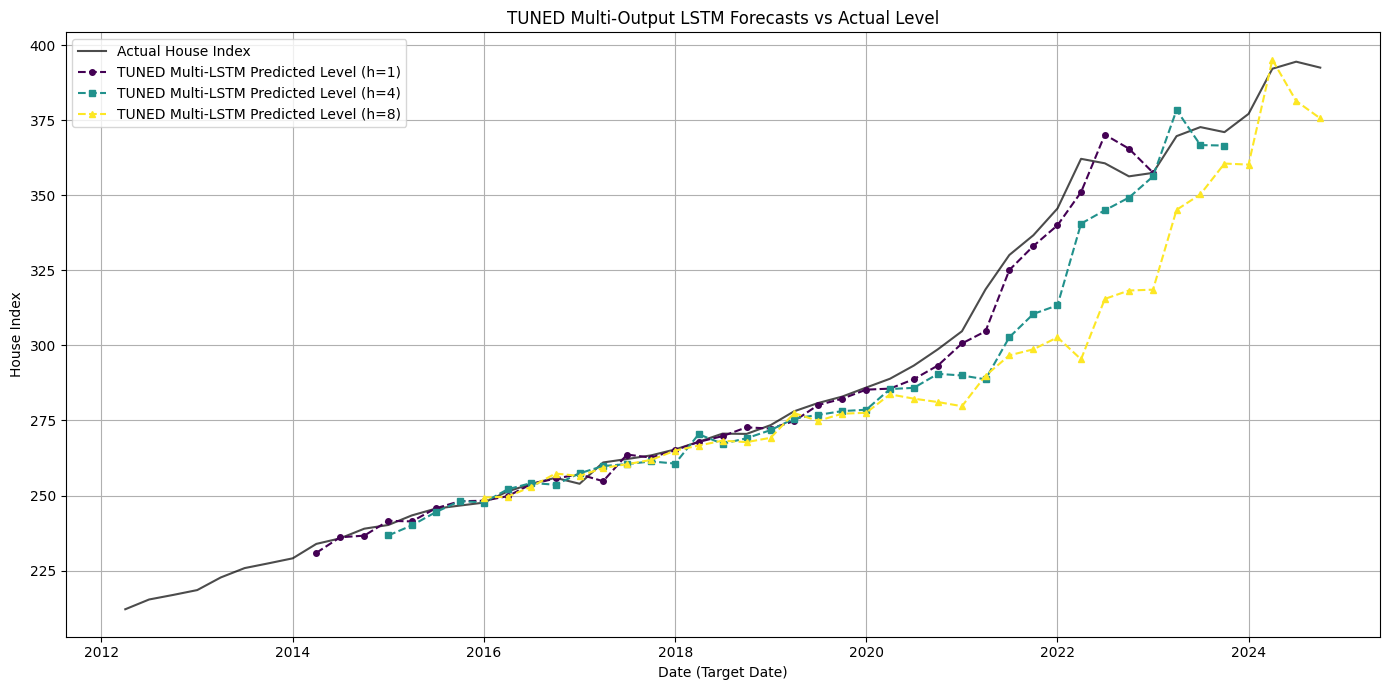


--- Completed TUNED Multi-Output LSTM Run ---

Best parameters found overall (used in final walk-forward):
{'batch_size': 32, 'model__activation': 'relu', 'model__dropout_rate': 0.1738912015244436, 'model__learning_rate': 0.00011048189703093158, 'model__lstm_units': 67}


In [3]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

warnings.filterwarnings('ignore')

# --- Helper Functions ---
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0: return np.nan
    if len(y_true[mask]) == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def directional_accuracy(y_true, y_pred, y_true_prev):
    y_true, y_pred, y_true_prev = np.array(y_true), np.array(y_pred), np.array(y_true_prev)
    min_len = min(len(y_true), len(y_pred), len(y_true_prev))
    y_true, y_pred, y_true_prev = y_true[:min_len], y_pred[:min_len], y_true_prev[:min_len]
    if min_len == 0: return np.nan
    actual_diff = np.sign(y_true - y_true_prev)
    pred_diff = np.sign(y_pred - y_true_prev)
    actual_diff[actual_diff == 0] = 1
    pred_diff[pred_diff == 0] = 1
    correct_direction = (actual_diff == pred_diff).astype(int)
    return np.mean(correct_direction) * 100

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

# Function to create sequences (same as before)
def create_multi_output_sequences(X_data, y_data, n_timesteps, n_outputs):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - n_timesteps - n_outputs + 1):
        X_seq.append(X_data[i:(i + n_timesteps)])
        y_seq.append(y_data[(i + n_timesteps):(i + n_timesteps + n_outputs)])
    return np.array(X_seq), np.array(y_seq)

# --- Keras Model Building Function (for Scikeras wrapper) ---
# Takes hyperparameters as arguments
def build_lstm_model_tuned(n_timesteps=4, n_features=34, n_outputs=8,
                           lstm_units=50, activation='relu', dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(n_timesteps, n_features)),
        LSTM(lstm_units, activation=activation),
        Dropout(dropout_rate), # Add dropout for regularization
        Dense(n_outputs)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

# --- Configuration ---
n_timesteps = 4  # Fixed for this tuning run
n_outputs = 8
n_epochs = 50    # Fixed epochs for tuning phase & final walk-forward
# n_lstm_units = 64 # This will be tuned

feature_file = 'DC_Data_For_Lasso.csv'
master_file = 'DC_Master_Data_Filled.csv'
n_test_origins = 36
n_splits_cv = 3
tscv = TimeSeriesSplit(n_splits=n_splits_cv)

# Number of parameter settings that are sampled.
n_iter_search = 2000 # <--- Set higher if you want an even longer/more thorough search

# Parameter Distributions for RandomizedSearchCV
param_distributions = {
    # Model parameters (note 'model__' prefix for KerasRegressor)
    'model__lstm_units': randint(32, 101),
    'model__activation': ['relu', 'tanh'],
    'model__dropout_rate': uniform(0.0, 0.5), # From 0.0 up to 0.5
    'model__learning_rate': loguniform(1e-4, 1e-2), # Log uniform often better for LR (0.0001 to 0.01)

    # Fit parameters
    'batch_size': [8, 16, 32]
    # 'epochs': [50, 100] # Could tune epochs, but keep fixed for now
}

results_all_horizons = {}
best_params_all_horizons = {}

print(f"--- Running TUNED Multi-Output LSTM Evaluation (Predicting Difference) ---")
print(f"Using RandomizedSearchCV with n_iter = {n_iter_search}")

# --- Load Data ---
try:
    df_features_raw = pd.read_csv(feature_file, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print(f"Data loaded successfully.")

    target_col_diff = df_features_raw.columns[0]
    y_diff_full = df_features_raw[[target_col_diff]]
    X_features_full = df_features_raw.drop(columns=[target_col_diff])
    n_features = X_features_full.shape[1]

    # Add time trend feature (as it wasn't in DC_Data_For_Lasso.csv originally)
    # Check if it already exists from previous runs potentially
    if 'time_trend' not in X_features_full.columns:
         X_features_full['time_trend'] = np.arange(len(X_features_full))
         n_features = X_features_full.shape[1] # Update feature count
         print("Added time_trend feature.")

    # --- Scaling ---
    scaler_X_final = StandardScaler()
    X_scaled_full = scaler_X_final.fit_transform(X_features_full)
    scaler_y_final = StandardScaler()
    y_scaled_full = scaler_y_final.fit_transform(y_diff_full)

    # --- Create Sequences ---
    print(f"Creating multi-output sequences...")
    if len(X_scaled_full) < n_timesteps + n_outputs:
         raise ValueError("Not enough historical data points.")
    X_seq_full, y_seq_full = create_multi_output_sequences(
        X_scaled_full, y_scaled_full.flatten(), n_timesteps, n_outputs
    )
    seq_start_dates_full = df_features_raw.index[:len(X_seq_full)]
    print(f"Shape of full sequence data: X={X_seq_full.shape}, y={y_seq_full.shape}")


    # --- Split Sequenced Data for Tuning & Final Test ---
    # Need to be careful with indexing if n_outputs > 1
    # Split based on the *start* date of the sequence
    if len(X_seq_full) < n_test_origins + 1:
        raise ValueError(f"Not enough sequences ({len(X_seq_full)}) for n_test_origins={n_test_origins}.")

    X_seq_train_tune, X_seq_test = X_seq_full[:-n_test_origins], X_seq_full[-n_test_origins:]
    y_seq_train_tune, y_seq_test = y_seq_full[:-n_test_origins], y_seq_full[-n_test_origins:]
    test_origin_dates = seq_start_dates_full[-n_test_origins:]

    print(f"Sequence Tuning shapes: X={X_seq_train_tune.shape}, y={y_seq_train_tune.shape}")
    print(f"Sequence Test shapes: X={X_seq_test.shape}, y={y_seq_test.shape}")

    # --- Hyperparameter Tuning using RandomizedSearchCV ---
    print(f"\nStarting RandomizedSearchCV (n_iter={n_iter_search})... (This WILL take a long time!)")
    start_tune_time = time.time()

    # Create KerasRegressor wrapper
    # Pass fixed parameters needed by the build function
    # Instead of passing all parameters directly
    keras_regressor = KerasRegressor(
        build_fn=build_lstm_model_tuned,
        model__n_timesteps=n_timesteps,
        model__n_features=n_features, 
        model__n_outputs=n_outputs,
        # Notice "model__" prefix for all model parameters
        model__lstm_units=50,
        model__activation='relu',
        model__dropout_rate=0.2,
        model__learning_rate=0.001,
        epochs=n_epochs,
        batch_size=16,
        verbose=0
    )

    random_search = RandomizedSearchCV(estimator=keras_regressor,
                                       param_distributions=param_distributions,
                                       n_iter=n_iter_search,
                                       scoring=rmse_scorer,
                                       cv=tscv,
                                       n_jobs=-1, # Use all cores if possible (check backend specifics)
                                       random_state=42,
                                       verbose=1) # Show progress for RandomizedSearchCV
    random_search.fit(X_seq_train_tune, y_seq_train_tune)

    tune_time = time.time() - start_tune_time
    print(f"RandomizedSearchCV finished in {tune_time:.2f} seconds.")
    # Note: best_params_ might contain 'model__' prefix depending on scikeras version
    print(f"Best parameters found: {random_search.best_params_}")
    # Extract best parameters, removing 'model__' prefix if present
    best_params_extracted = {}
    best_fit_params = {}
    for key, value in random_search.best_params_.items():
        if key.startswith('model__'):
            best_params_extracted[key[len('model__'):]] = value
        elif key in ['batch_size', 'epochs']: # Separate fit params
             best_fit_params[key] = value
        else: # Keep other params like batch_size if not prefixed
             best_fit_params[key] = value


    print("Extracted best model params:", best_params_extracted)
    print("Extracted best fit params:", best_fit_params)

    # --- Walk-Forward Validation using Best Parameters ---
    print("\nStarting walk-forward validation with best parameters...")
    X_train_full_seq, _ = X_seq_full[:-n_test_origins], X_seq_full[-n_test_origins:]
    y_train_full_seq, _ = y_seq_full[:-n_test_origins], y_seq_full[-n_test_origins:]

    history_X = [x for x in X_train_full_seq]
    history_y = [y for y in y_train_full_seq]
    predictions_dict = {} # Store predictions as before

    start_walk_time = time.time()

    # Get best fit params, provide defaults if not found by search
    final_epochs = best_fit_params.get('epochs', n_epochs) # Use fixed epochs if not tuned
    final_batch_size = best_fit_params.get('batch_size', 16)

    for t in range(len(X_seq_test)):
        origin_date = test_origin_dates[t]
        print(f"Processing Origin {t + 1}/{len(X_seq_test)} (Date: {origin_date.date()})...")

        # Build model with best hyperparameters found
        model = build_lstm_model_tuned(
            n_timesteps=n_timesteps,
            n_features=n_features,
            n_outputs=n_outputs,
            **best_params_extracted # Pass tuned model params
        )

        current_X_train = np.array(history_X)
        current_y_train = np.array(history_y)

        # Use early stopping during walk-forward fitting as well
        early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True, verbose=0)
        model.fit(current_X_train, current_y_train,
                  epochs=final_epochs, # Use final epochs
                  batch_size=final_batch_size, # Use best batch size
                  verbose=0,
                  callbacks=[early_stopping])

        current_X_test_seq = X_seq_test[t].reshape((1, n_timesteps, n_features))
        y_pred_scaled_vector = model.predict(current_X_test_seq, verbose=0)[0]
        y_pred_diff_vector = scaler_y_final.inverse_transform(y_pred_scaled_vector.reshape(1, -1)).flatten()

        # Perform iterative inverse differencing
        try:
            last_actual_level = df_master.loc[origin_date + relativedelta(months=(n_timesteps-1)*3), 'House_Index']
        except KeyError:
             print(f"Warning: Cannot find level for origin {origin_date.date()}. Skipping origin.")
             history_X.append(X_seq_test[t])
             history_y.append(y_seq_test[t]) # Still update history
             continue

        current_level = last_actual_level
        for h in range(n_outputs):
            pred_diff = y_pred_diff_vector[h]
            current_level = current_level + pred_diff
            target_date = origin_date + relativedelta(months=(n_timesteps + h)*3)
            if target_date not in predictions_dict:
                predictions_dict[target_date] = {}
            predictions_dict[target_date][origin_date] = current_level

        # Update history
        history_X.append(X_seq_test[t])
        history_y.append(y_seq_test[t])

    walk_time = time.time() - start_walk_time
    print(f"Walk-forward validation complete in {walk_time:.2f} seconds.")

    # --- Calculate Metrics for Each Horizon h ---
    print("\nCalculating performance metrics...")
    # (Metric calculation logic remains the same as previous multi-output run)
    metrics_results = []
    all_preds_aligned = {h: [] for h in range(1, n_outputs + 1)}
    all_actuals_aligned = {h: [] for h in range(1, n_outputs + 1)}
    all_prev_actuals_aligned = {h: [] for h in range(1, n_outputs + 1)}
    valid_indices_by_h = {h: [] for h in range(1, n_outputs + 1)}

    for t in range(len(X_seq_test)):
        origin_date = test_origin_dates[t]
        for h in range(1, n_outputs + 1):
             target_date = origin_date + relativedelta(months=(n_timesteps + h - 1)*3)
             prev_target_date = target_date - relativedelta(months=3)

             if target_date in predictions_dict and origin_date in predictions_dict[target_date]:
                 if target_date in df_master.index and prev_target_date in df_master.index:
                      pred_level = predictions_dict[target_date][origin_date]
                      actual_level = df_master.loc[target_date, 'House_Index']
                      prev_actual_level = df_master.loc[prev_target_date, 'House_Index']
                      all_preds_aligned[h].append(pred_level)
                      all_actuals_aligned[h].append(actual_level)
                      all_prev_actuals_aligned[h].append(prev_actual_level)
                      valid_indices_by_h[h].append(target_date)

    final_metrics = []
    plot_dfs = {}
    for h in range(1, n_outputs + 1):
        preds = np.array(all_preds_aligned[h])
        actuals = np.array(all_actuals_aligned[h])
        prev_actuals = np.array(all_prev_actuals_aligned[h])
        indices = pd.to_datetime(valid_indices_by_h[h])

        if len(preds) > 0:
            mae = mean_absolute_error(actuals, preds)
            rmse = np.sqrt(mean_squared_error(actuals, preds))
            mape = mean_absolute_percentage_error(actuals, preds)
            da = directional_accuracy(actuals, preds, prev_actuals)
            final_metrics.append({'Forecast Horizon (Steps)': h, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'DA': da})
            plot_dfs[h] = pd.DataFrame({'Actual_Original': actuals, 'Predicted_Original': preds}, index=indices)
        else:
            final_metrics.append({'Forecast Horizon (Steps)': h, 'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'DA': np.nan})

    metrics_df = pd.DataFrame(final_metrics)
    print("\n--- TUNED Multi-Output LSTM Performance Metrics ---")
    print(metrics_df.to_string(index=False, float_format="%.3f"))

    # --- Plotting Selected Horizons ---
    print("\n--- Plotting Results for Selected Horizons (h=1, 4, 8) ---")
    # (Plotting logic remains the same)
    plt.figure(figsize=(14, 7))
    horizons_to_plot = [1, 4, 8]
    min_plot_date = min((df.index.min() for h, df in plot_dfs.items() if h in horizons_to_plot and not df.empty), default=None)
    max_plot_date = max((df.index.max() for h, df in plot_dfs.items() if h in horizons_to_plot and not df.empty), default=None)

    if min_plot_date and max_plot_date:
        actual_data_subset = df_master[(df_master.index >= min_plot_date - relativedelta(years=2)) & (df_master.index <= max_plot_date)]
        plt.plot(actual_data_subset.index, actual_data_subset['House_Index'], label='Actual House Index', color='black', linewidth=1.5, alpha=0.7)
    else:
         print("Could not determine date range for plotting actuals.")

    colors = plt.cm.viridis(np.linspace(0, 1, len(horizons_to_plot)))
    markers = ['o', 's', '^']

    for i, h in enumerate(horizons_to_plot):
        if h in plot_dfs and not plot_dfs[h].empty:
            results_df = plot_dfs[h]
            plot_data = results_df[(results_df.index >= min_plot_date) & (results_df.index <= max_plot_date)] if min_plot_date else results_df
            plt.plot(plot_data.index, plot_data['Predicted_Original'],
                      label=f'TUNED Multi-LSTM Predicted Level (h={h})', color=colors[i],
                      marker=markers[i % len(markers)], linestyle='--', markersize=4)

    plt.title('TUNED Multi-Output LSTM Forecasts vs Actual Level')
    plt.xlabel('Date (Target Date)')
    plt.ylabel('House Index')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names. {e}")
except ValueError as e:
    print(f"Error: Value error during processing: {e}")
except ImportError as e:
     print(f"Import Error: {e}. Make sure 'scikeras' is installed (`pip install scikeras`).")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed TUNED Multi-Output LSTM Run ---")
print("\nBest parameters found overall (used in final walk-forward):")
# Note: RandomizedSearch finds best params for the *entire* dataset's CV process,
# not per horizon. We apply these overall best params to each walk-forward step.
if 'random_search' in locals() and hasattr(random_search, 'best_params_'):
    print(random_search.best_params_)
else:
    print("Could not retrieve best parameters (tuning might have failed).")

--- Generating Future Forecast (Q1 2025 - Q4 2026) using Tuned Multi-Output LSTM ---
Using hyperparameters: batch_size=32, lstm_units=67, dropout_rate=0.1739, learning_rate=0.00011048
Data loaded successfully.
Creating sequences on all data...
Shape of final sequence data: X=(122, 4, 34), y=(122, 8)
Training final Multi-Output LSTM model on all data with tuned hyperparameters...
Final model training complete in 2.19 seconds.
Shape of input sequence for forecast: (1, 4, 34)
Predicting future steps...
Inverse differencing future predictions...
Last actual House_Index value (2024-10-01): 392.54

--- Future Forecast Results (Q1 2025 - Q4 2026) ---
            Forecasted_House_Index
2025-01-01              394.554664
2025-04-01              396.733788
2025-07-01              399.725279
2025-10-01              402.099157
2026-01-01              403.121569
2026-04-01              403.715639
2026-07-01              406.828288
2026-10-01              409.367517


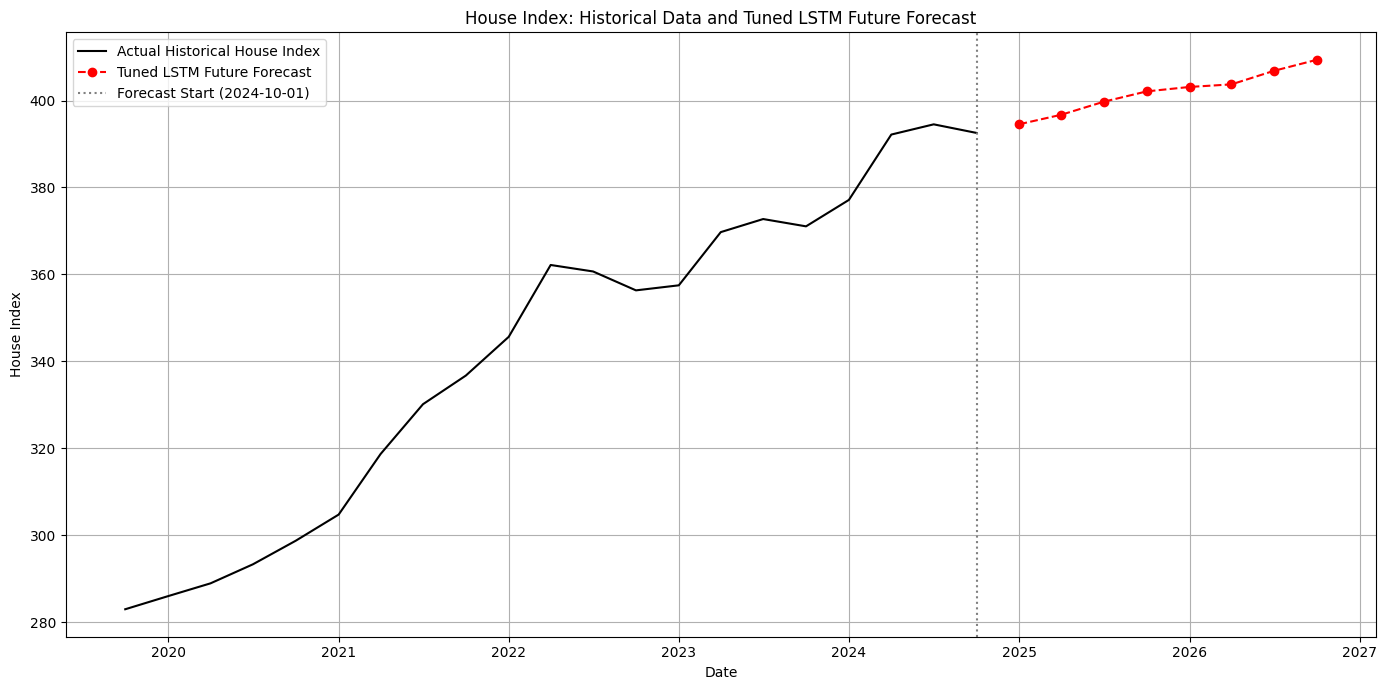


--- Completed Tuned LSTM Future Forecast Generation ---


In [5]:
# --- Code to Generate Future Forecast using Final Multi-Output LSTM with Tuned Hyperparameters ---

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
# Deep Learning imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import warnings
from dateutil.relativedelta import relativedelta
import time

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

warnings.filterwarnings('ignore')

# Function to create sequences for multi-output target
def create_multi_output_sequences(X_data, y_data, n_timesteps, n_outputs):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - n_timesteps - n_outputs + 1):
        X_seq.append(X_data[i:(i + n_timesteps)])
        y_seq.append(y_data[(i + n_timesteps):(i + n_timesteps + n_outputs)])
    return np.array(X_seq), np.array(y_seq)

# --- Configuration ---
n_timesteps = 4
n_outputs = 8
n_epochs = 50 

# Tuned hyperparameters
batch_size = 32
activation = 'relu'
dropout_rate = 0.1738912015244436
learning_rate = 0.00011048189703093158
lstm_units = 67  # From tuning

feature_file = 'DC_Data_For_Lasso.csv'
master_file = 'DC_Master_Data_Filled.csv'

print(f"--- Generating Future Forecast (Q1 2025 - Q4 2026) using Tuned Multi-Output LSTM ---")
print(f"Using hyperparameters: batch_size={batch_size}, lstm_units={lstm_units}, dropout_rate={dropout_rate:.4f}, learning_rate={learning_rate:.8f}")

# --- Load Data ---
try:
    df_features_raw = pd.read_csv(feature_file, index_col='Date', parse_dates=True)
    df_master = pd.read_csv(master_file, index_col='Date', parse_dates=True)
    print("Data loaded successfully.")

    # --- Prepare ALL Data for Final Model Training ---
    target_col_diff = df_features_raw.columns[0]
    y_diff_full = df_features_raw[[target_col_diff]]
    X_features_full = df_features_raw.drop(columns=[target_col_diff])
    n_features = X_features_full.shape[1]

    # --- Scaling (Fit on ALL data now) ---
    scaler_X_final = StandardScaler()
    X_scaled_full = scaler_X_final.fit_transform(X_features_full)

    scaler_y_final = StandardScaler()
    y_scaled_full = scaler_y_final.fit_transform(y_diff_full)

    # --- Create Sequences on ALL Data ---
    print(f"Creating sequences on all data...")
    if len(X_scaled_full) < n_timesteps + n_outputs:
         raise ValueError("Not enough historical data points to create sequences for training.")

    # Create sequences for training the final model
    X_seq_final, y_seq_final = create_multi_output_sequences(
        X_scaled_full, y_scaled_full.flatten(), n_timesteps, n_outputs
    )
    print(f"Shape of final sequence data: X={X_seq_final.shape}, y={y_seq_final.shape}")

    # --- Train Final LSTM Model with Tuned Hyperparameters ---
    print("Training final Multi-Output LSTM model on all data with tuned hyperparameters...")
    start_train_time = time.time()

    def build_final_multi_lstm_model(n_timesteps, n_features, n_outputs, lstm_units, dropout_rate, activation, learning_rate):
        model = Sequential([
            Input(shape=(n_timesteps, n_features)),
            LSTM(lstm_units, activation=activation),
            Dropout(dropout_rate),  # Add dropout layer with tuned rate
            Dense(n_outputs)
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
        return model

    final_model = build_final_multi_lstm_model(
        n_timesteps=n_timesteps, 
        n_features=n_features, 
        n_outputs=n_outputs, 
        lstm_units=lstm_units,
        dropout_rate=dropout_rate,
        activation=activation,
        learning_rate=learning_rate
    )

    # Train with tuned batch size
    final_model.fit(X_seq_final, y_seq_final,
                    epochs=n_epochs, verbose=0, batch_size=batch_size)

    train_time = time.time() - start_train_time
    print(f"Final model training complete in {train_time:.2f} seconds.")

    # --- Prepare Input for Forecasting ---
    last_sequence_X_scaled = X_scaled_full[-n_timesteps:]
    last_sequence_input = last_sequence_X_scaled.reshape((1, n_timesteps, n_features))
    print(f"Shape of input sequence for forecast: {last_sequence_input.shape}")

    # --- Predict Future Steps ---
    print("Predicting future steps...")
    y_pred_scaled_future_vector = final_model.predict(last_sequence_input, verbose=0)[0]

    # Inverse transform the predicted difference vector
    y_pred_diff_future = scaler_y_final.inverse_transform(y_pred_scaled_future_vector.reshape(1, -1)).flatten()

    # --- Inverse Differencing for Future Forecast ---
    print("Inverse differencing future predictions...")
    last_actual_date = df_master.index.max()
    last_actual_level = df_master.loc[last_actual_date, 'House_Index']
    print(f"Last actual House_Index value ({last_actual_date.date()}): {last_actual_level:.2f}")

    future_predictions_level = []
    current_level = last_actual_level
    for h in range(n_outputs):
        pred_diff = y_pred_diff_future[h]
        current_level = current_level + pred_diff
        future_predictions_level.append(current_level)

    # Create future dates index
    future_dates = pd.date_range(start=last_actual_date + relativedelta(months=3), periods=n_outputs, freq='QS')

    future_results_df = pd.DataFrame({
        'Forecasted_House_Index': future_predictions_level
    }, index=future_dates)

    print("\n--- Future Forecast Results (Q1 2025 - Q4 2026) ---")
    print(future_results_df)

    # --- Plotting Future Forecast ---
    plt.figure(figsize=(14, 7))

    # Plot historical actual data (e.g., last 5 years + forecast period)
    plot_start_date = last_actual_date - relativedelta(years=5)
    actual_data_subset = df_master[(df_master.index >= plot_start_date)]
    plt.plot(actual_data_subset.index, actual_data_subset['House_Index'], label='Actual Historical House Index', color='black', linewidth=1.5)

    # Plot future forecast
    plt.plot(future_results_df.index, future_results_df['Forecasted_House_Index'], label='Tuned LSTM Future Forecast', color='red', linestyle='--', marker='o')

    plt.title('House Index: Historical Data and Tuned LSTM Future Forecast')
    plt.xlabel('Date')
    plt.ylabel('House Index')
    plt.axvline(last_actual_date, color='gray', linestyle=':', label=f'Forecast Start ({last_actual_date.date()})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error: File not found. {e}")
except KeyError as e:
    print(f"Error: Column not found. Check column names. {e}")
except ValueError as e:
    print(f"Error: Value error during processing: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

print(f"\n--- Completed Tuned LSTM Future Forecast Generation ---")